<a href="https://colab.research.google.com/github/swhoyle/electric-load-forecasting/blob/main/Electric_Load_Forecast.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Electric Load Forecasting

**Project Title:** Daily Electric Load Forecasting  
**School:** University of California, San Diego (UCSD)   
**Course:** MAS DSE 260 - Capstone Project   
**Date:** Spring 2026   
**Team Members:** Sean He, Spencer Hoyle, Frank Chavezsosa   
**Advisor:** Prof. Raymond de Callafon (callafon@ucsd.edu)   


## Objective



Build a model to predict and forecast electric load.

## Dataset

A commercial business (Bakery) in Europe has provided 1-second power load data in Watts (W) recorded by electric meters in the business facilities.

**Structure**:

- Date range:  11/28/2025 → 4/8/2026
- Total days:  132  
- Shape:      (11404800, 3)

| timestamp | day_class | load |
| --- | --- | --- |
| 2025-11-28 00:00:01 | full | 1234 |
| 2025-11-28 00:00:02 | half | 0 |
| ... | ... | ... |
| 2026-04-08 12:59:59 | none | -242 |

**Attributes**:
- `timestamp`: The specific date and time of each power reading, recorded at 1-second intervals in local time to the commercial facility.
- `day_class`: The work day classification for the commercial business, provided by the customer.
  - `full`: Full working day (both facility and bakery are open)
  - `half`: Half working day (only facility is open; bakery is closed)
  - `none`: Not a working day (both facility and bakery are closed)
- `load` (predictor): Net power draw from the grid in Watts.
  - Positive (+): either pure load consumption when solar is inactive, or consumption exceeding solar output.
  - Negative (-): Solar output exceeds consumption, sending surplus power back to the grid.
  - Zero (0): No net grid exchange, either because everything is off or solar output exactly matches consumption.

## Plan

**Phase 1: Data Preprocessing**

---

Prepare the raw 1-second load data for modeling. This includes cleaning, downsampling, feature engineering, and splitting into train/validation/test sets.

| Step | Description |
|------|-------------|
| EDA | Explore patterns, distributions, and data quality |
| Data Cleaning | Flag missing values, zeros, negatives, and outliers |
| Downsample | Downsample from 1-second to target resolutions |
| Feature Engineering | Build time, cyclical, solar proxy, lag, rolling, and trend features |
| Preprocessing | Encode categoricals, split into train/val/test by time |

<br>

**Phase 2: Single-Step Forecasting**

---

Train and evaluate models for each forecast horizon independently. Each model predicts a single value — the expected average load for the next interval at its native resolution.

| Horizon | Resolution | Predicts |
|---------|------------|----------|
| `1min` | `1min` | Avg load over next minute |
| `5min` | `5min` | Avg load over next 5 minutes |
| `10min` | `10min` | Avg load over next 10 minutes |
| `15min` | `15min` | Avg load over next 15 minutes |
| `30min` | `30min` | Avg load over next 30 minutes |
| `1hr` | `1hr` | Avg load over next hour |

- **Baseline:** Persistence — prediction(t+1) = actual(t)
- **Goal:** Find the best model, features, and configuration for each horizon.

<br>

**Phase 3: Multi-Step Forecasting**

---
Use the best horizon models from Phase 2 to build full forecast profiles. Each profile predicts a sequence of future values across the full horizon window.

| Profile | Horizon | Resolutions | Strategies |
|---------|---------|-------------|------------|
| Short-term | 1 hour | `1min`, `5min`, `10min` | Direct, Recursive |
| Medium-term | 6 hours | `5min`, `15min`, `30min` | Direct, Recursive |
| Long-term | 24 hours | `15min`, `30min`, `1hr` | Direct, Recursive |

- **Baseline:** Historical mean — mean of last 6 occurrences at same time + day class
- **Goal:** Find the best profile configuration (model, resolution, strategy) for each forecast horizon window.

<br>

**Model Evaluation**

---

For each model the following metrics are computed on the held-out test set:

| Metric | Name | Description |
|--------|------|-------------|
| `MAE` | Mean Absolute Error | Average absolute difference between predicted and actual load in Watts |
| `RMSE` | Root Mean Squared Error | Square root of the average squared difference between predicted and actual load in Watts |
| `WAPE` | Weighted Absolute Percentage Error | Total absolute error as a percentage of total actual load |

## Imports

In [ ]:
!pip install flaml

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ipywidgets as widgets
import xgboost as xgb
import joblib
import time
import logging

from flaml import AutoML
from scipy.io import loadmat
from matplotlib.patches import Patch
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from IPython.display import display
from google.colab import drive
from matplotlib.lines import Line2D
from sklearn.preprocessing import OrdinalEncoder
from pathlib import Path

## Config

Connections

In [19]:
drive.mount('/content/drive')

Mounted at /content/drive


Settings

In [20]:
plt.style.use("default")
color_palette = sns.color_palette()

File Paths

In [21]:
# ── BASE PATHS ────────────────────────────────────────────────────────────────
BASE_PROJECT_PATH = Path("/content/drive/MyDrive/ElectricLoadForecast")
BASE_DATA_PATH    = BASE_PROJECT_PATH / "data"

# ── DATA PATHS ────────────────────────────────────────────────────────────────
RAW_PATH          = BASE_DATA_PATH / "001_raw"
CLEAN_PATH        = BASE_DATA_PATH / "002_clean"
DOWNSAMPLED_PATH  = BASE_DATA_PATH / "003_downsample"
FEATURED_PATH     = BASE_DATA_PATH / "004_featured"
PREPROCESSED_PATH = BASE_DATA_PATH / "005_preprocessed"

ALL_PATHS = [RAW_PATH, CLEAN_PATH, DOWNSAMPLED_PATH, FEATURED_PATH, PREPROCESSED_PATH]

# ── FILE PATHS ────────────────────────────────────────────────────────────────
RAW_FILENAME = "P_data.mat"
LOAD_FILENAME = "load.parquet"

# ── PATH HELPERS ──────────────────────────────────────────────────────────────
def raw_filepath():
  return RAW_PATH / RAW_FILENAME

def clean_filepath():
  return CLEAN_PATH / LOAD_FILENAME

def downsampled_filepath(res: str) -> Path:
  return DOWNSAMPLED_PATH / f"{res}_{LOAD_FILENAME}"

def featured_filepath(res: str) -> Path:
    return FEATURED_PATH / f"{res}_{LOAD_FILENAME}"

def preprocessed_filepath(res: str, split: str) -> Path:
    return PREPROCESSED_PATH / f"{res}_{split}_{LOAD_FILENAME}"

# ── SAVE FUNCTIONS ──────────────────────────────────────────────────────────────
def _save_parquet(df: pd.DataFrame, filepath: str):
  df.to_parquet(filepath)
  print(f"✓ Save data to {filepath}")

def _save_json(data: dict, filepath: str):
  with open(filepath, 'w') as f:
    json.dump(data, f)
  print(f"✓ Save data to {filepath}")

def save_clean(df: pd.DataFrame):
  _save_parquet(df, clean_filepath())

def save_downsampled(df: pd.DataFrame, res: str):
  _save_parquet(df, downsampled_filepath(res))

def save_featured(df: pd.DataFrame, res: str):
  _save_parquet(df, featured_filepath(res))

def save_preprocessed(df: pd.DataFrame, res: str, split: str):
  _save_parquet(df, preprocessed_filepath(res, split))

# ── LOAD FUNCTIONS ──────────────────────────────────────────────────────────────
def load_raw():
  filepath = raw_filepath()
  data = loadmat(filepath)
  print(f"✓ Loaded data from {filepath}")
  return data

def _load_parquet(filepath: str):
  data = pd.read_parquet(filepath)
  print(f"✓ Loaded data from {filepath}")
  return data

def load_clean():
  return _load_parquet(clean_filepath())

def load_downsampled(res: str):
  return _load_parquet(downsampled_filepath(res))

def load_featured(res: str):
  return _load_parquet(featured_filepath(res))

def load_preprocessed(res: str):
  return _load_parquet(preprocessed_filepath(res))

# ── Make Directories ──────────────────────────────────────────────────────────────

def make_dirs():
    """Create all data directories."""
    for path in ALL_PATHS:
      path.mkdir(parents=True, exist_ok=True)
      print(f"✓ Created {path}")
    print("✓ All directories created")

# ── RUN ───────────────────────────────────────────────────────────────────────
make_dirs()

✓ Created /content/drive/MyDrive/ElectricLoadForecast/data/001_raw
✓ Created /content/drive/MyDrive/ElectricLoadForecast/data/002_clean
✓ Created /content/drive/MyDrive/ElectricLoadForecast/data/003_downsample
✓ Created /content/drive/MyDrive/ElectricLoadForecast/data/004_featured
✓ Created /content/drive/MyDrive/ElectricLoadForecast/data/005_preprocessed
✓ Created /content/drive/MyDrive/ElectricLoadForecast/data/006_models
✓ Created /content/drive/MyDrive/ElectricLoadForecast/data/007_predictions
✓ Created /content/drive/MyDrive/ElectricLoadForecast/data/008_evaluations
✓ All directories created


## Phase 1: Data Preprocessing

### 1.1 Load Data

Load data

In [22]:
raw_data = load_raw()

✓ Loaded data from /content/drive/MyDrive/ElectricLoadForecast/data/001_raw/P_data.mat


View data

In [23]:
print(f"Keys: {list(raw_data.keys())}")

p_data = raw_data["P_data"]
day_data = raw_data["day_data"]
day_class = raw_data["day_class"]

print("\n-------------------------")
print("p_data", p_data.shape)
print("-------------------------")
print(p_data[:3])

print("\n-------------------------")
print("day_data", day_data.shape)
print("-------------------------")
print(day_data[0][:3])

print("\n-------------------------")
print("day_class", day_class.shape)
print("-------------------------")
print(day_class[0][:3])

Keys: ['__header__', '__version__', '__globals__', 'P_data', 'day_data', 'day_class']

-------------------------
p_data (86400, 132)
-------------------------
[[1925. 1301. 1320. 1496. 2568. 2574. 1629. 1852. 1549. 4226. 1624. 3286.
  1645. 1289. 1442. 2285. 2357. 1055. 2255. 2043. 1318. 1735. 1455. 1812.
  1151. 1137. 3991. 2403. 2123. 2606. 1318. 1462. 1861. 1776. 1746. 1780.
  1167. 2516. 1635. 3744. 4473. 1949. 1763. 1793. 1601. 2445. 2243.  656.
   723.  441. 1860. 5409. 2286. 1423. 2272. 1196. 2433. 1478. 1839. 4977.
  2227. 2516. 2033. 1769. 1524. 6609. 1904. 2150. 3681. 2711. 2106. 1686.
   950. 1471. 2047. 1042. 6290. 1667. 1575. 5832. 1904. 1655. 2250. 3531.
  3126.  820.  698. 1449. 2807.  501. 1667. 3465. 1090.  759.  653.  507.
   692. 1083. 5432. 1825. 1035. 1051. 2284. 1268. 8466. 1066. 1877. 2005.
   922. 1974. 3319.  645. 1187. 1258. 6033. 5225.  423. 1223. 2551. 1900.
  2276. 2838. 2556. 1953. 2394. 1541. 2265. 1095. 4205. 1380. 1400. 1280.]
 [1922. 1296. 1320. 1520. 

Restructure data

In [24]:
def restructure_raw_data(raw_data: dict) -> pd.DataFrame:
    """Restructure raw data into a structured DataFrame with timestamp, load, and day_class."""

    p_data    = raw_data.get("P_data")
    day_data  = raw_data.get("day_data")
    day_class = raw_data.get("day_class")

    if p_data is None or day_data is None or day_class is None:
        raise ValueError("raw_data must contain 'p_data', 'day_data', and 'day_class'")

    # Build date and day_class arrays
    dates      = pd.to_datetime([d[0] for d in day_data.squeeze()])
    classes    = [d[0] for d in day_class.squeeze()]

    # Build timestamps: each date repeated 86400 times, offset by second
    timestamps = np.concatenate([
        pd.date_range(start=date, periods=86400, freq="s") for date in dates
    ])

    df = pd.DataFrame({
        "timestamp": timestamps,
        "load":      p_data.flatten(order="F"),  # flatten column-major to match date order
        "day_class": np.repeat(classes, 86400)
    })

    return df.set_index("timestamp")

df_raw = restructure_raw_data(raw_data)
df_raw.head()

,load,day_class
timestamp,,
2025-11-28 00:00:00,1925.0,full
2025-11-28 00:00:01,1922.0,full
2025-11-28 00:00:02,1921.0,full
2025-11-28 00:00:03,1921.0,full
2025-11-28 00:00:04,1926.0,full


### 1.2 EDA

#### Data Structure

In [25]:
print("Raw Data")
print("-------------------------------------------------")
print(f"Date range:  {df_raw.index.min()}  →  {df_raw.index.max()}")
print(f"Total days:  {df_raw.index.normalize().nunique()}")
print(f"Shape:       {df_raw.shape}")
print("-------------------------------------------------")
df_raw.head()

Raw Data
-------------------------------------------------
Date range:  2025-11-28 00:00:00  →  2026-04-08 23:59:59
Total days:  132
Shape:       (11404800, 2)
-------------------------------------------------


,load,day_class
timestamp,,
2025-11-28 00:00:00,1925.0,full
2025-11-28 00:00:01,1922.0,full
2025-11-28 00:00:02,1921.0,full
2025-11-28 00:00:03,1921.0,full
2025-11-28 00:00:04,1926.0,full


Downsample

In [26]:
df_1min = df_raw.resample('1min').agg({'load': 'mean', 'day_class': 'first'})

print("Resampled Data (1 min)")
print("-------------------------------------------------")
print(f"Date range:  {df_1min.index.min()}  →  {df_1min.index.max()}")
print(f"Total days:  {df_1min.index.normalize().nunique()}")
print(f"Shape:       {df_1min.shape}")
print("-------------------------------------------------")
df_1min.head()

Resampled Data (1 min)
-------------------------------------------------
Date range:  2025-11-28 00:00:00  →  2026-04-08 23:59:00
Total days:  132
Shape:       (190080, 2)
-------------------------------------------------


,load,day_class
timestamp,,
2025-11-28 00:00:00,1912.400000,full
2025-11-28 00:01:00,1908.233333,full
2025-11-28 00:02:00,1643.183333,full
2025-11-28 00:03:00,2992.950000,full
2025-11-28 00:04:00,1106.000000,full


In [27]:
df_1h = df_raw.resample('1h').agg({'load': 'mean', 'day_class': 'first'})

print("Resampled Data (1 hour)")
print("-------------------------------------------------")
print(f"Date range:  {df_1h.index.min()}  →  {df_1h.index.max()}")
print(f"Total days:  {df_1h.index.normalize().nunique()}")
print(f"Shape:       {df_1h.shape}")
print("-------------------------------------------------")
df_1h.head()

Resampled Data (1 hour)
-------------------------------------------------
Date range:  2025-11-28 00:00:00  →  2026-04-08 23:00:00
Total days:  132
Shape:       (3168, 2)
-------------------------------------------------


,load,day_class
timestamp,,
2025-11-28 00:00:00,1597.470441,full
2025-11-28 01:00:00,2274.362500,full
2025-11-28 02:00:00,3163.920156,full
2025-11-28 03:00:00,3524.631667,full
2025-11-28 04:00:00,12653.277222,full


#### Time-Series Plots

In [28]:
color_map = {'full': 'steelblue', 'half': 'orange', 'none': 'tomato'}

def plot_timeseries_load(df, start_date=None, end_date=None):
    """Plot power load in timeseries plot"""
    if start_date is None:
        start_date = df.index.min().strftime("%Y-%m-%d")

    if end_date is None:
        end_date = df.index.max().strftime("%Y-%m-%d")

    df_range = df.loc[start_date:end_date]

    plt.figure(figsize=(18, 6))

    for cls in color_map:
        masked = df_range["load"].copy()
        masked[df_range["day_class"] != cls] = np.nan
        plt.plot(masked.index, masked, color=color_map[cls], linewidth=0.8)

    # clean legend
    handles = [Line2D([0], [0], color=color_map[cls], label=cls)for cls in color_map]

    plt.legend(
        handles=handles,
        loc='upper center',
        bbox_to_anchor=(0.5, 1),
        ncols=3,
        frameon=False,
        title="Day Classification"
    )

    plt.title(f"Power Load ({start_date} → {end_date})")
    plt.xlabel("Timestamp")
    plt.ylabel("Load (W)")

    plt.tight_layout()
    plt.show()

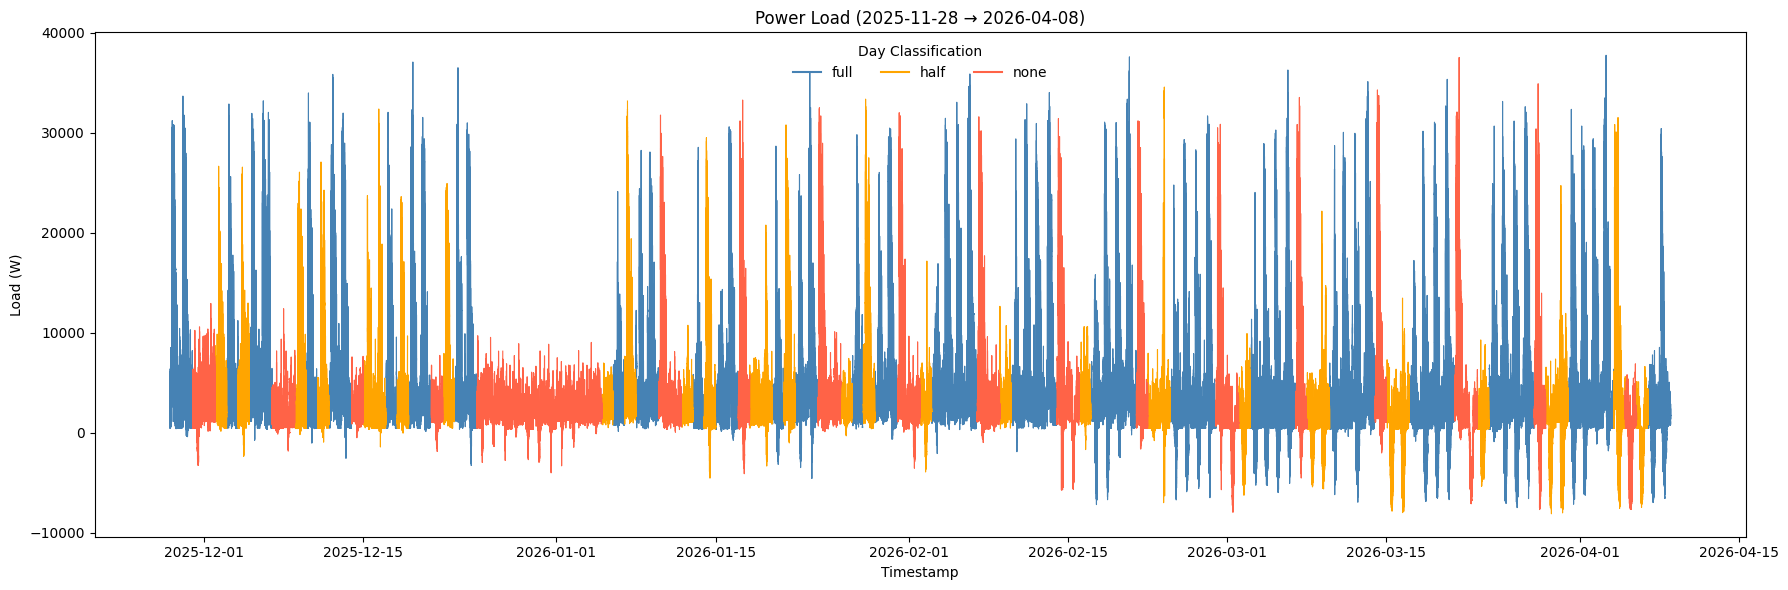

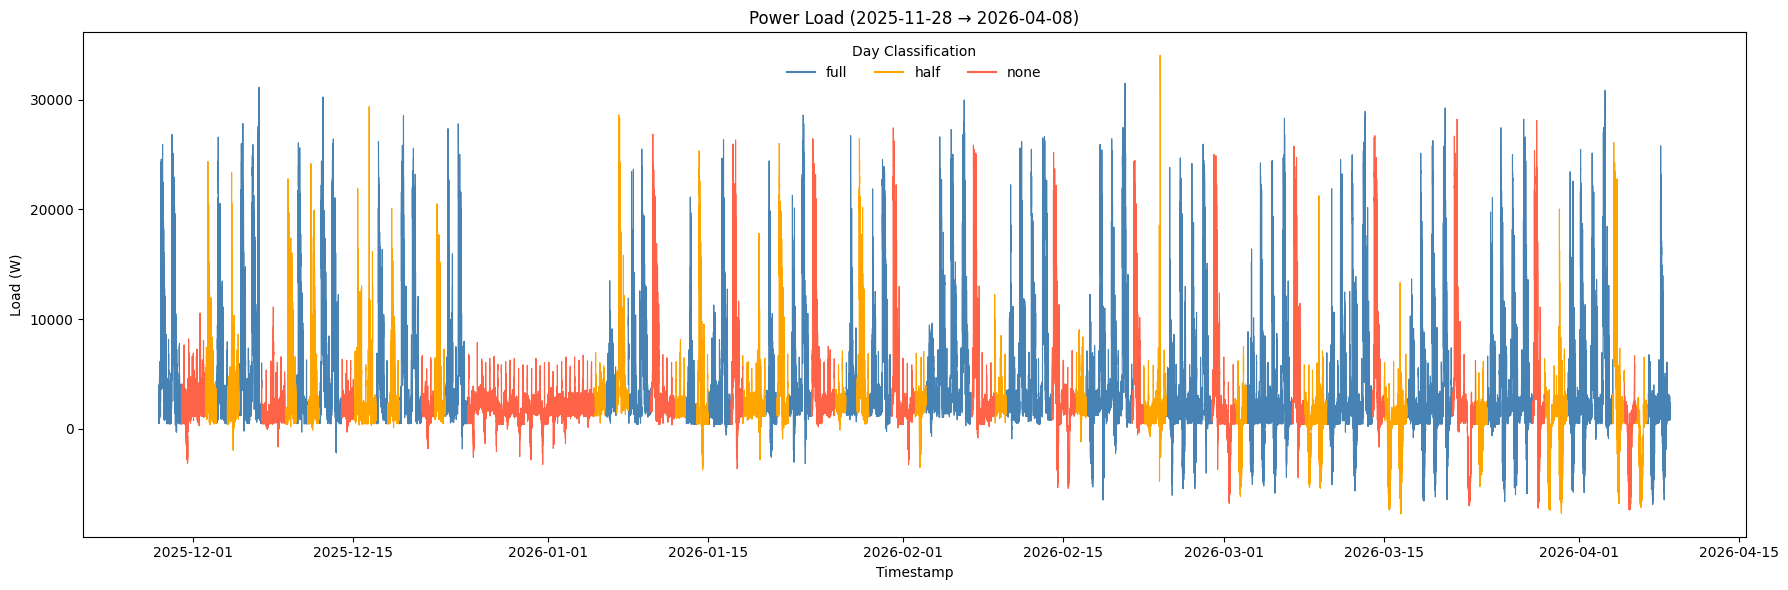

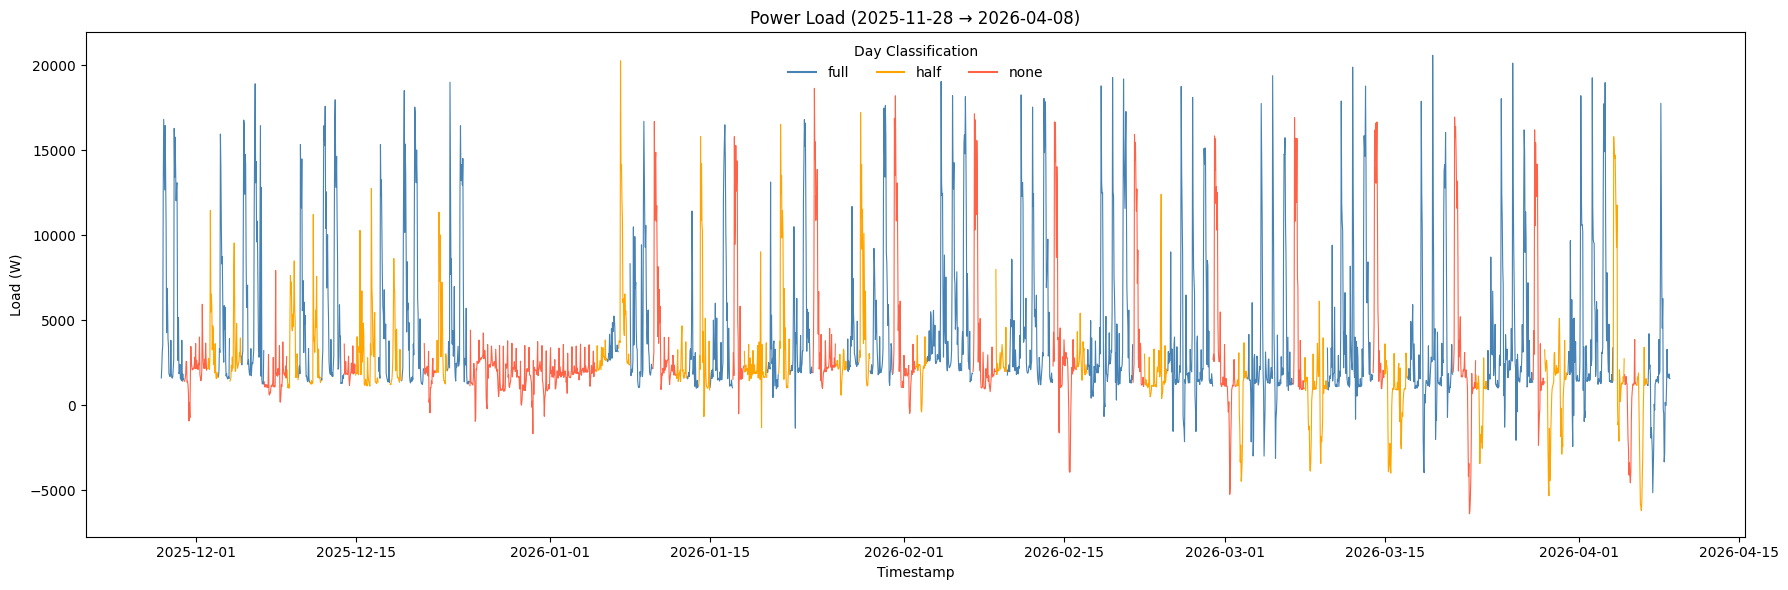

In [29]:
plot_timeseries_load(df_raw)
plot_timeseries_load(df_1min)
plot_timeseries_load(df_1h)

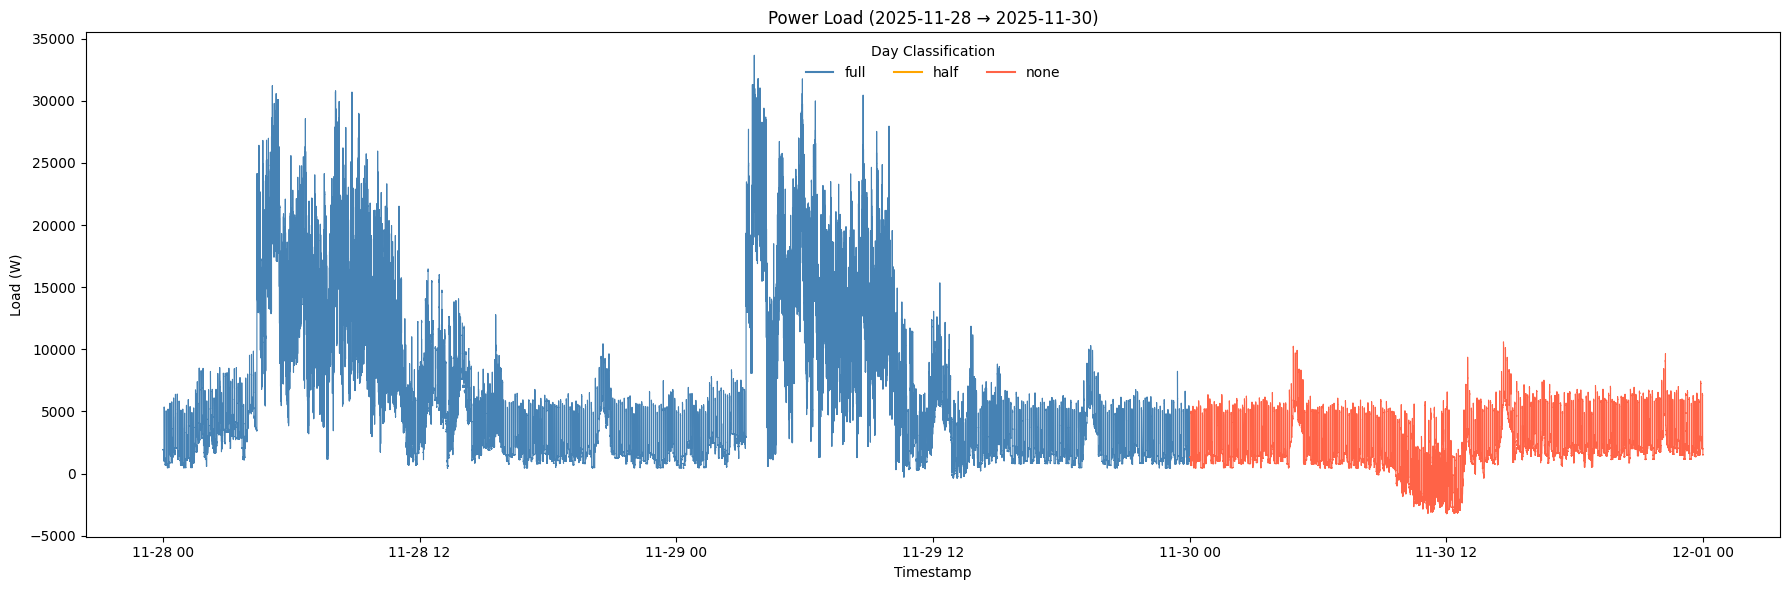

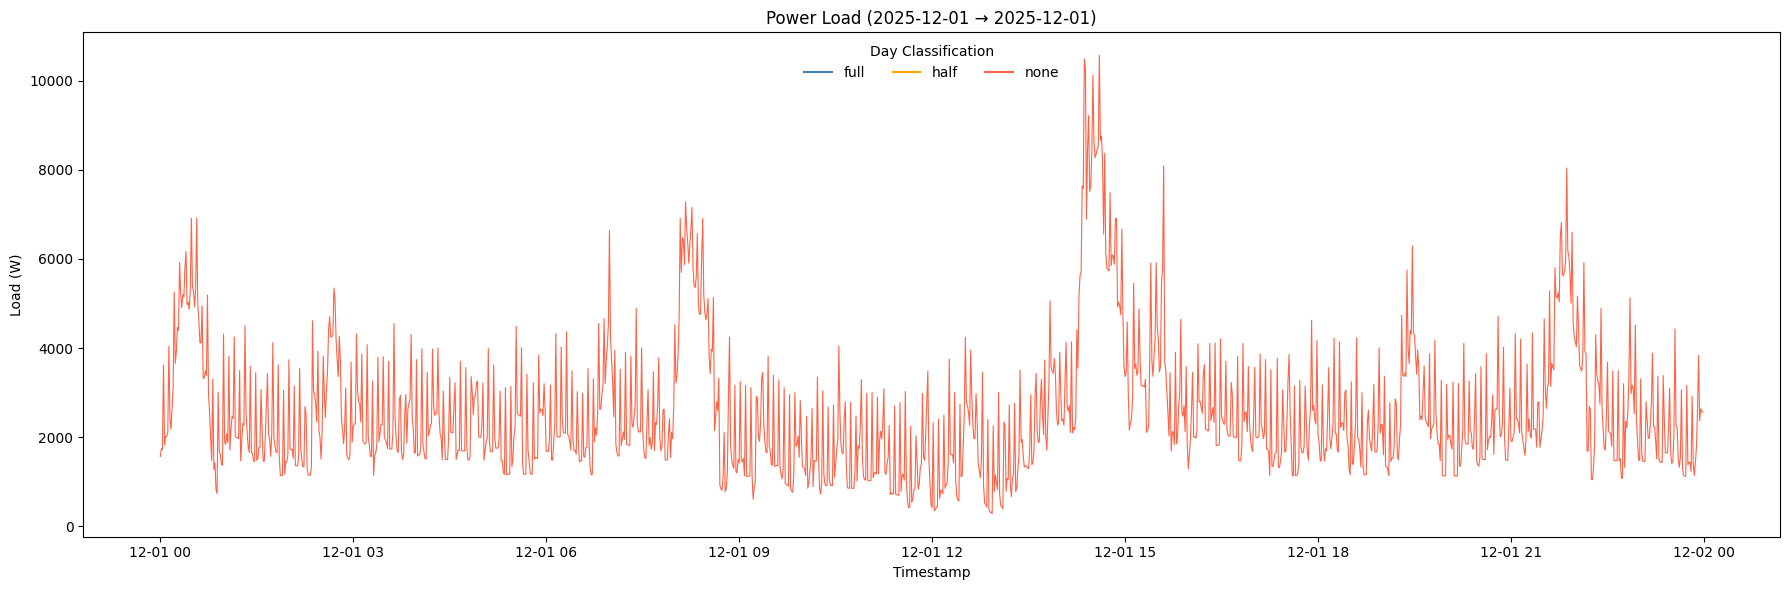

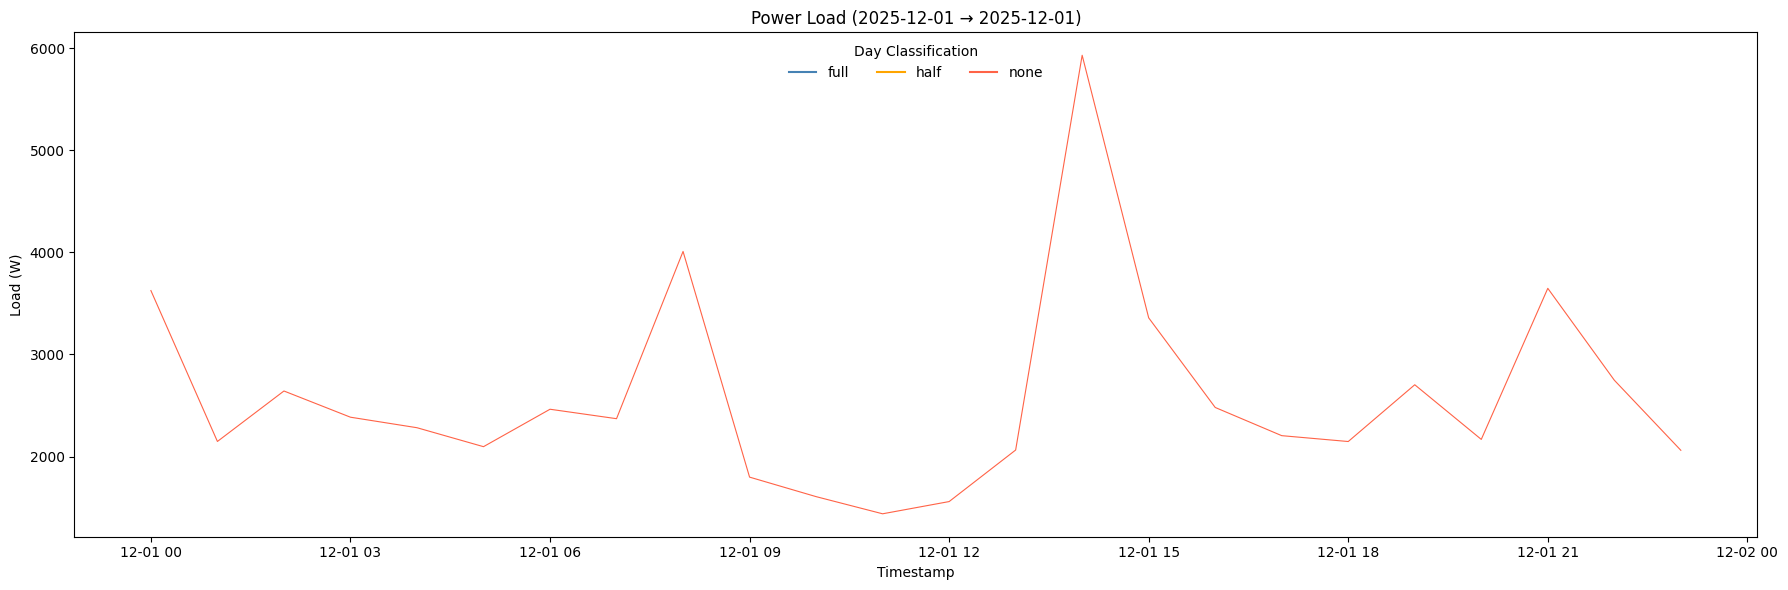

In [30]:
plot_timeseries_load(df_raw, start_date='2025-11-28', end_date='2025-11-30')
plot_timeseries_load(df_1min, start_date='2025-12-01', end_date='2025-12-01')
plot_timeseries_load(df_1h, start_date='2025-12-01', end_date='2025-12-01')

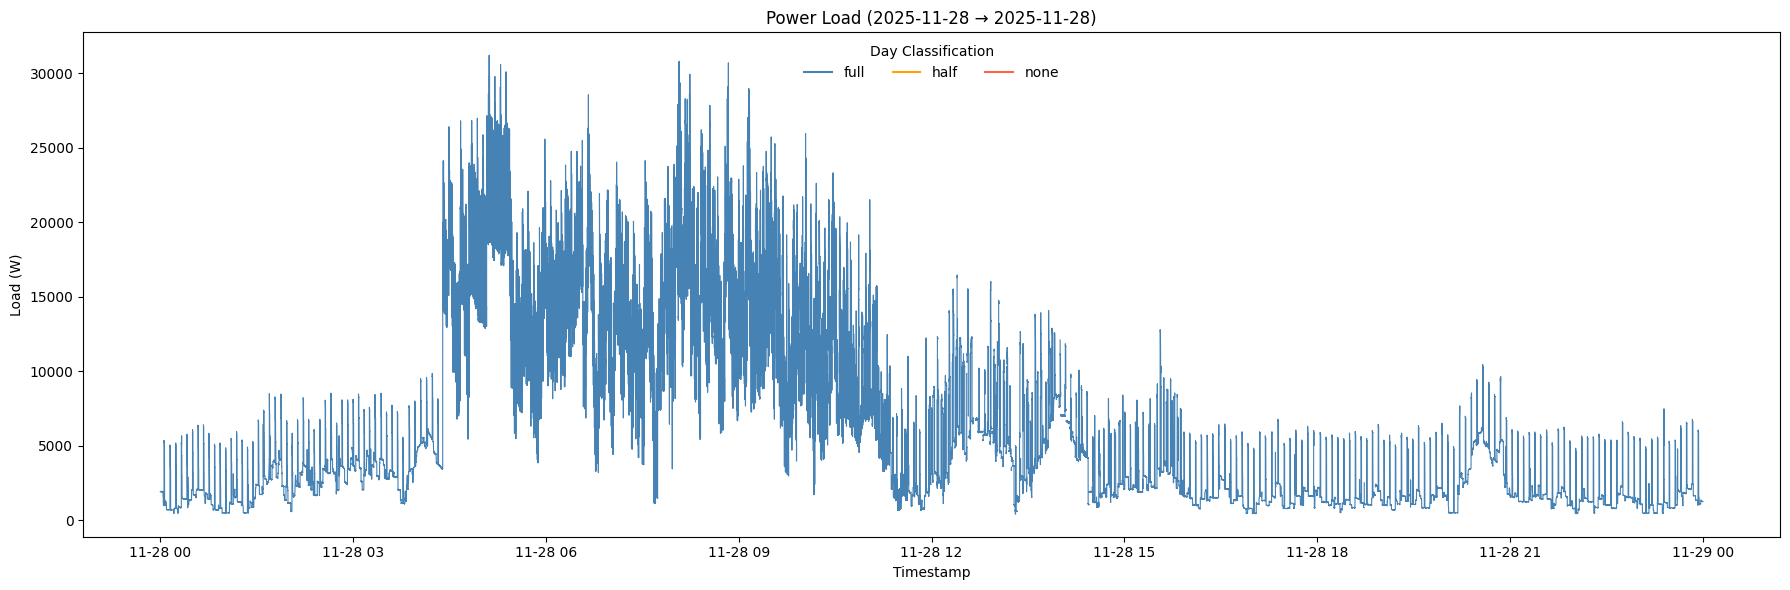

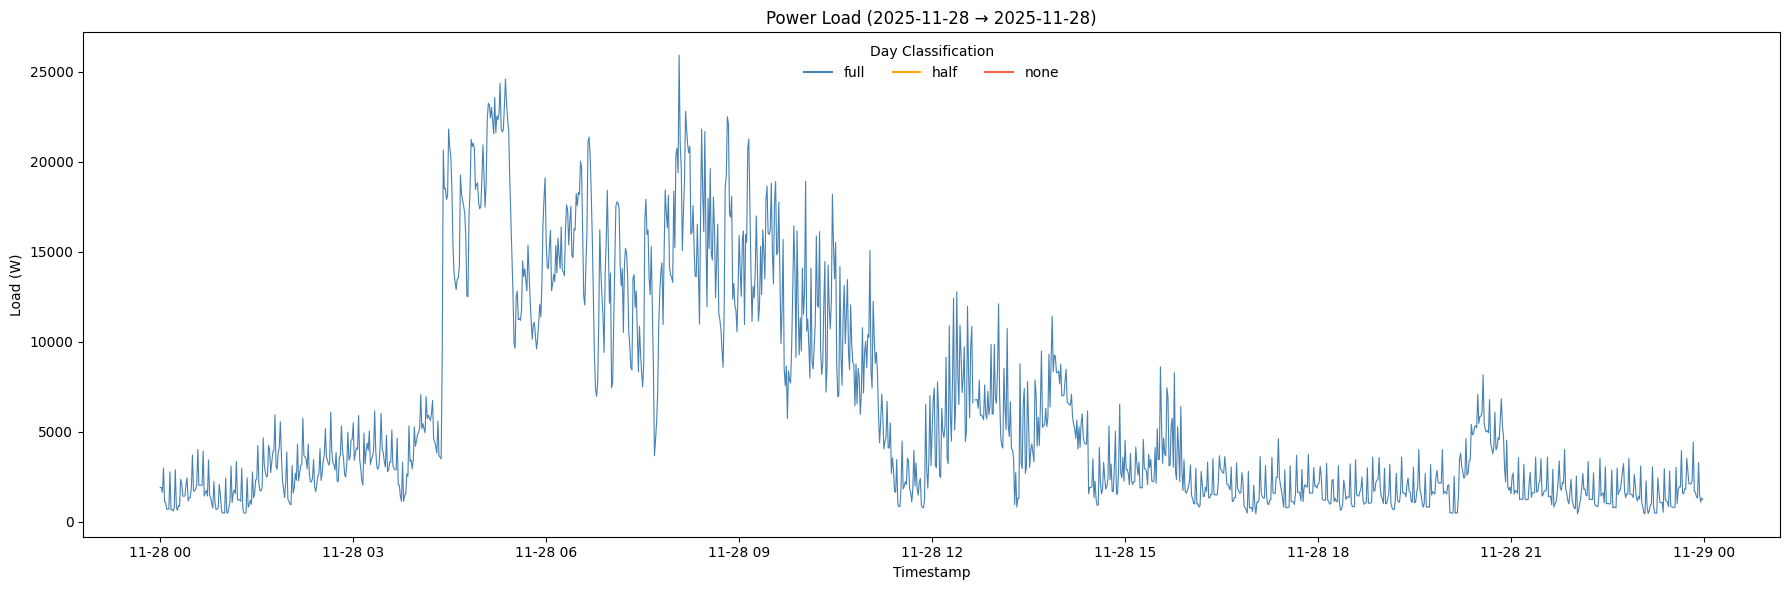

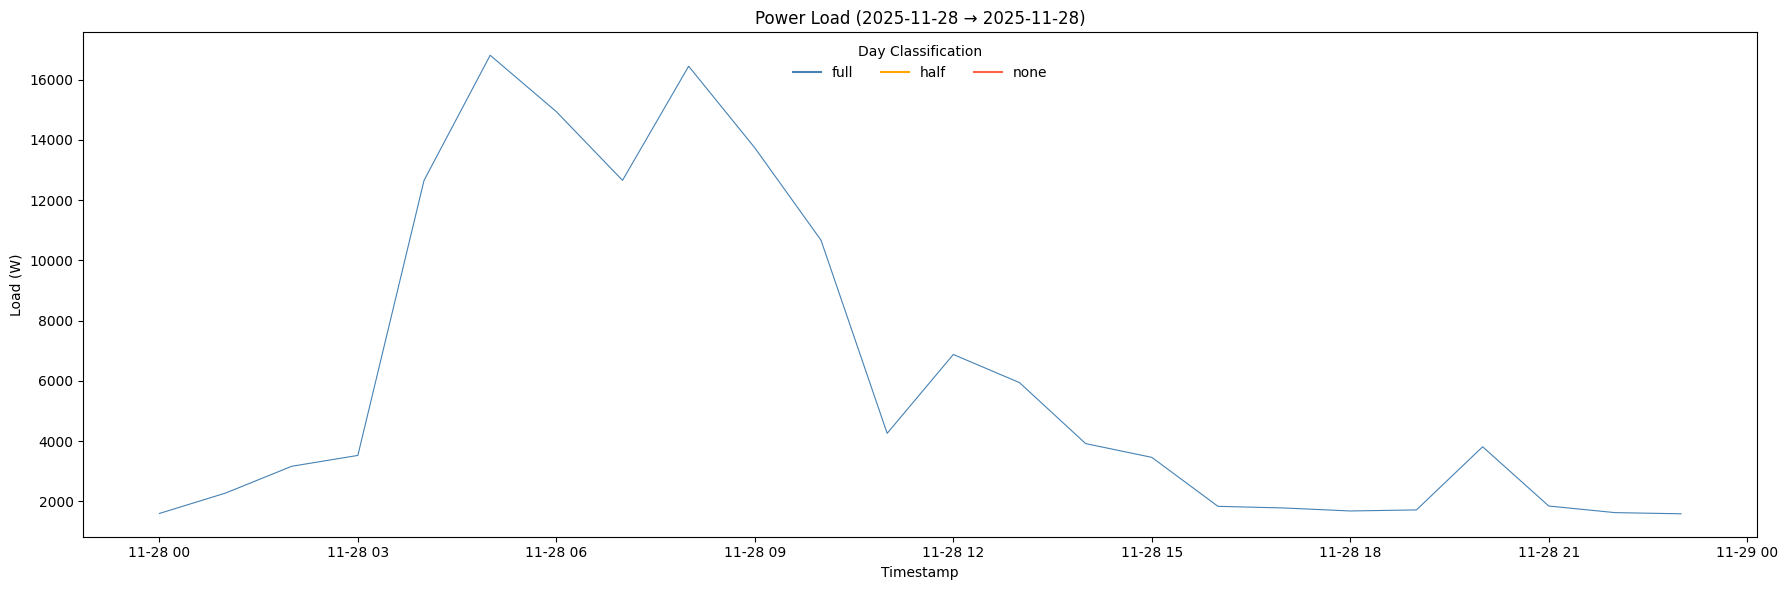

In [31]:
date = '2025-11-28'

plot_timeseries_load(df_raw, start_date=date, end_date=date)
plot_timeseries_load(df_1min, start_date=date, end_date=date)
plot_timeseries_load(df_1h, start_date=date, end_date=date)

#### Data Quality

Missing Values

Missing values (raw 1-second resolution):
--------------------------------------------------
           missing      %
load         46099  0.404
day_class        0  0.000
--------------------------------------------------


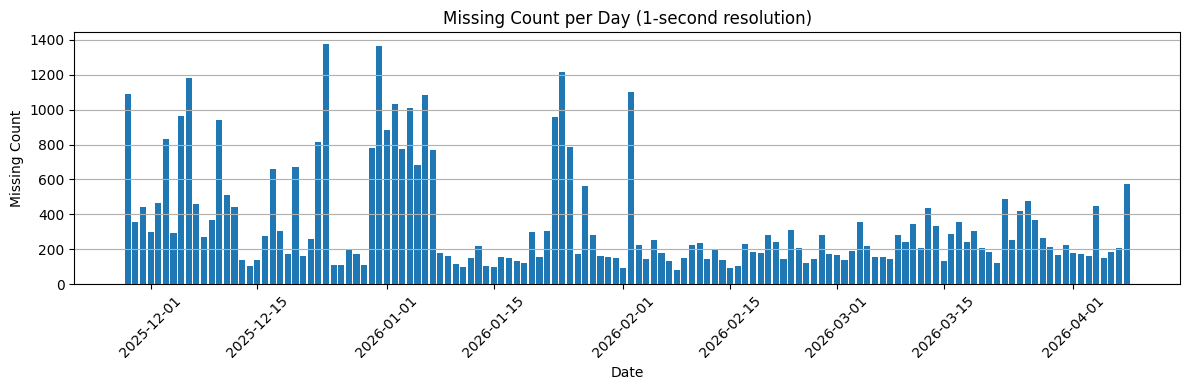

In [32]:
print(f"Missing values (raw 1-second resolution):")
print("--------------------------------------------------")
total = len(df_raw)
missing = df_raw.isnull().sum()
pct = ((missing / total) * 100).round(3)
print(pd.DataFrame({'missing': missing, '%': pct}))
print("--------------------------------------------------")

missing_per_day = df_raw["load"].isna().resample("D").sum()
plt.figure(figsize=(12, 4))
plt.bar(missing_per_day.index, missing_per_day.values)
plt.title("Missing Count per Day (1-second resolution)")
plt.xlabel("Date")
plt.ylabel("Missing Count")
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.tight_layout()
plt.show()

Zero Load

Zero Load Values (raw 1-second resolution):
--------------------------------------------------
   count      %
0    261  0.002
--------------------------------------------------


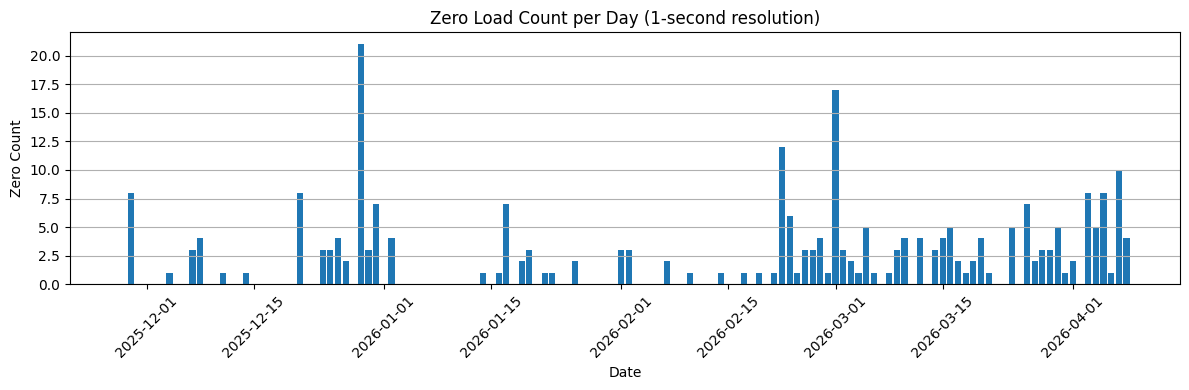

In [33]:
# ── RAW (1-second) ───────────────────────────────────────────────────────────
print("Zero Load Values (raw 1-second resolution):")
print("--------------------------------------------------")

total = len(df_raw)
zero = (df_raw["load"] == 0).sum()
pct = round((zero / total) * 100, 3)

print(pd.DataFrame({'count': [zero], '%': [pct]}))
print("--------------------------------------------------")

# Zero per day (count)
zero_per_day = (df_raw["load"] == 0).resample("D").sum()

plt.figure(figsize=(12, 4))
plt.bar(zero_per_day.index, zero_per_day.values)
plt.title("Zero Load Count per Day (1-second resolution)")
plt.xlabel("Date")
plt.ylabel("Zero Count")
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.tight_layout()
plt.show()

Negative Load

Negative Load Values (raw 1-second resolution):
--------------------------------------------------
    count      %
0  703079  6.165
--------------------------------------------------


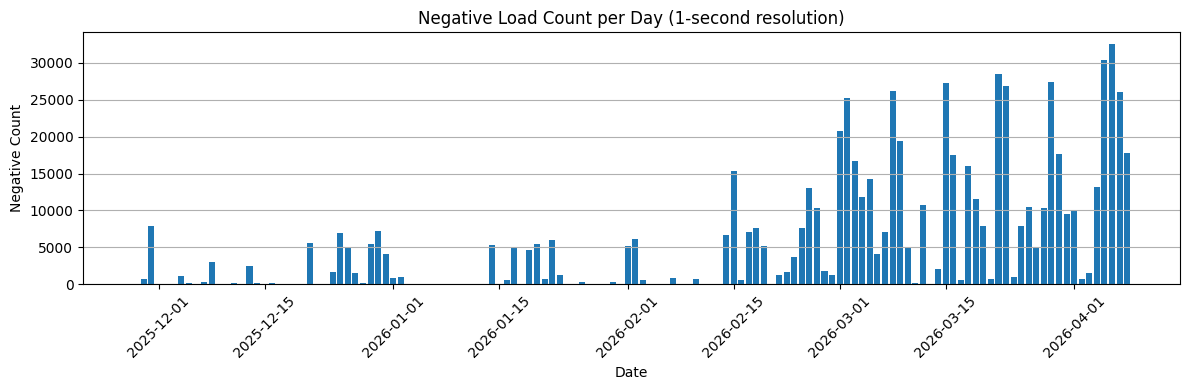

In [34]:
print("Negative Load Values (raw 1-second resolution):")
print("--------------------------------------------------")

total = len(df_raw)
negative = (df_raw["load"] < 0).sum()
pct = round((negative / total) * 100, 3)

print(pd.DataFrame({'count': [negative], '%': [pct]}))
print("--------------------------------------------------")


# ── Negative per day (count) ────────────────────────────────────────────────
neg_per_day = (df_raw["load"] < 0).resample("D").sum()

plt.figure(figsize=(12, 4))
plt.bar(neg_per_day.index, neg_per_day.values)

plt.title("Negative Load Count per Day (1-second resolution)")
plt.xlabel("Date")
plt.ylabel("Negative Count")
plt.xticks(rotation=45)
plt.grid(axis="y")

plt.tight_layout()
plt.show()


Outliers

Outliers (outside 1st–99th percentile):
-----------------------------------------
        threshold   count      %
lower  < -4760.0W  113509  0.995
upper  > 22847.0W  113566  0.996


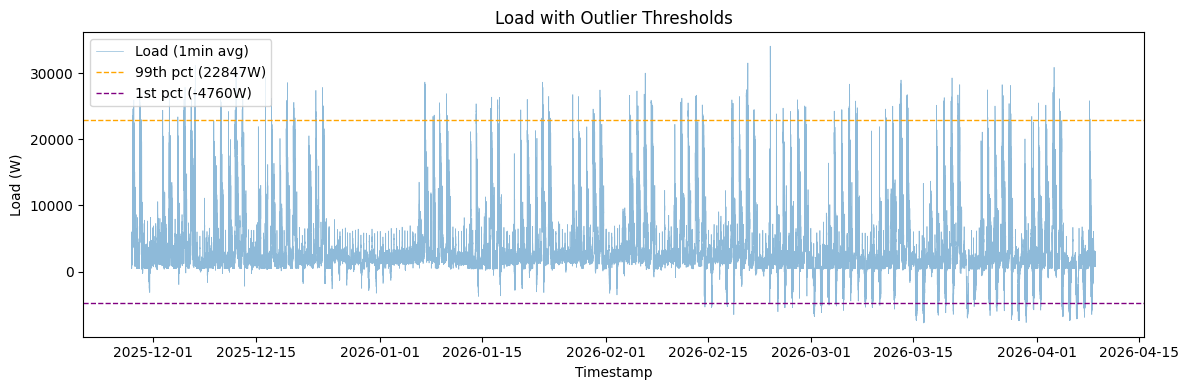

In [35]:
# ── Outlier Detection ────────────────────────────────────────────────────────
q01 = df_raw["load"].quantile(0.01)
q99 = df_raw["load"].quantile(0.99)

lower_outliers = df_raw["load"] < q01
upper_outliers = df_raw["load"] > q99

print(f"Outliers (outside 1st–99th percentile):")
print("-----------------------------------------")
print(pd.DataFrame({
    "threshold": [f"< {q01:.1f}W", f"> {q99:.1f}W"],
    "count":     [lower_outliers.sum(), upper_outliers.sum()],
    "%":         [round(lower_outliers.mean() * 100, 3), round(upper_outliers.mean() * 100, 3)]
}, index=["lower", "upper"]))

# ── Plot (downsampled for speed) ──────────────────────────────────────────────
sample = df_raw["load"].resample("1min").mean()  # downsample to 1-min for plotting

plt.figure(figsize=(12, 4))
plt.plot(sample.index, sample.values, linewidth=0.5, alpha=0.5, label="Load (1min avg)")
plt.axhline(q99, color="orange", linestyle="--", linewidth=1, label=f"99th pct ({q99:.0f}W)")
plt.axhline(q01, color="purple", linestyle="--", linewidth=1, label=f"1st pct ({q01:.0f}W)")
plt.title("Load with Outlier Thresholds")
plt.xlabel("Timestamp")
plt.ylabel("Load (W)")
plt.legend()
plt.tight_layout()
plt.show()

#### Load Distribution

In [36]:
# Use 1 min resolution for
df = df_1min

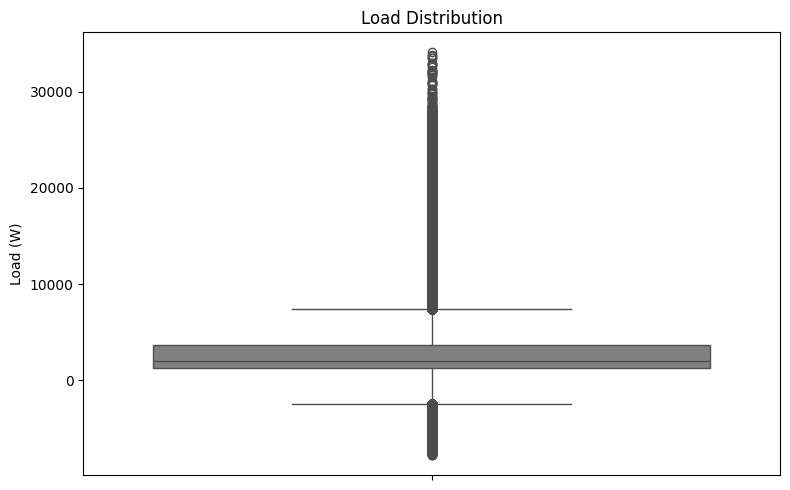

Load Stats:


,count,mean,std,min,25%,50%,75%,max
load,190006.0,3511.08,4722.73,-7742.17,1265.94,2035.79,3726.95,34057.93


In [37]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, y='load', color='grey')
plt.title("Load Distribution")
plt.ylabel("Load (W)")
plt.tight_layout()
plt.show()

print("Load Stats:")
display(df['load'].describe().round(2).to_frame().T)

By day class

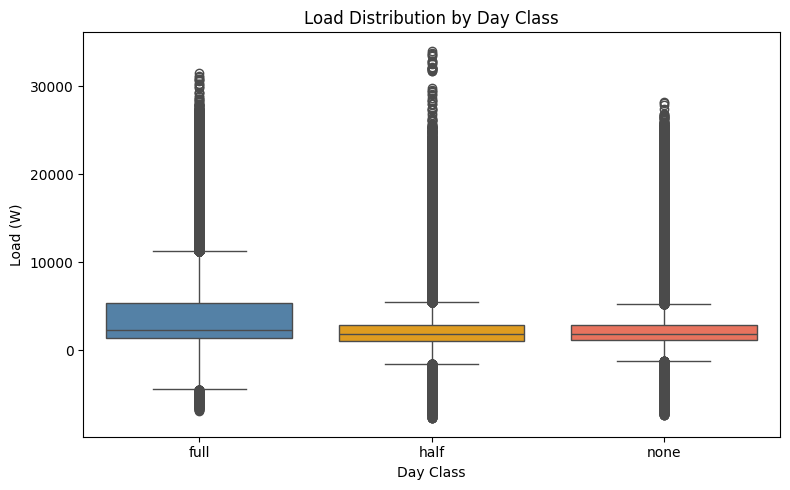


Load Stats By Class:


,count,mean,std,min,25%,50%,75%,max
day_class,,,,,,,,
full,90669.0,4372.72,5263.11,-6894.20,1423.88,2337.45,5350.23,31515.92
half,46058.0,2419.89,3656.85,-7742.17,1066.12,1810.54,2828.93,34057.93
none,53279.0,2988.07,4275.11,-7387.52,1195.92,1866.52,2831.40,28240.05


In [38]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='day_class', y='load', hue='day_class', palette=color_map,
            order=['full', 'half', 'none'], legend=False)
plt.title("Load Distribution by Day Class")
plt.xlabel("Day Class")
plt.ylabel("Load (W)")
plt.tight_layout()
plt.show()

print("\nLoad Stats By Class:")
display(df.groupby('day_class')['load'].describe().round(2))

By month

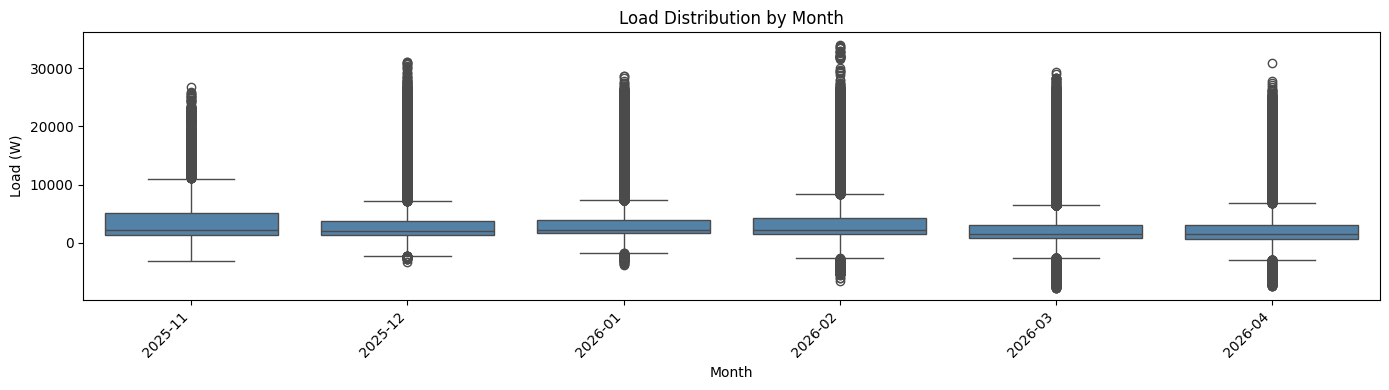

,count,mean,std,min,25%,50%,75%,max
timestamp,,,,,,,,
2025-11,4319.0,4539.46,5408.05,-3156.72,1281.70,2257.82,5187.62,26838.28
2025-12,44601.0,3584.11,4267.97,-3254.73,1345.05,2063.42,3705.00,31137.08
2026-01,44639.0,3815.12,4242.19,-3740.50,1633.62,2286.30,3915.40,28626.30
2026-02,40306.0,4023.51,4944.10,-6496.05,1480.21,2264.73,4256.33,34057.93
2026-03,44627.0,2765.74,4977.96,-7742.17,761.02,1560.60,3031.43,29257.95
2026-04,11514.0,2758.79,5545.13,-7387.52,702.09,1497.47,3139.00,30861.03


In [39]:
plt.figure(figsize=(14, 4))
sns.boxplot(data=df, x=df.index.to_period('M').astype(str), y='load', color='steelblue')
plt.title("Load Distribution by Month")
plt.xlabel("Month")
plt.ylabel("Load (W)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

display(df.groupby(df.index.to_period('M'))['load'].describe().round(2))

By day

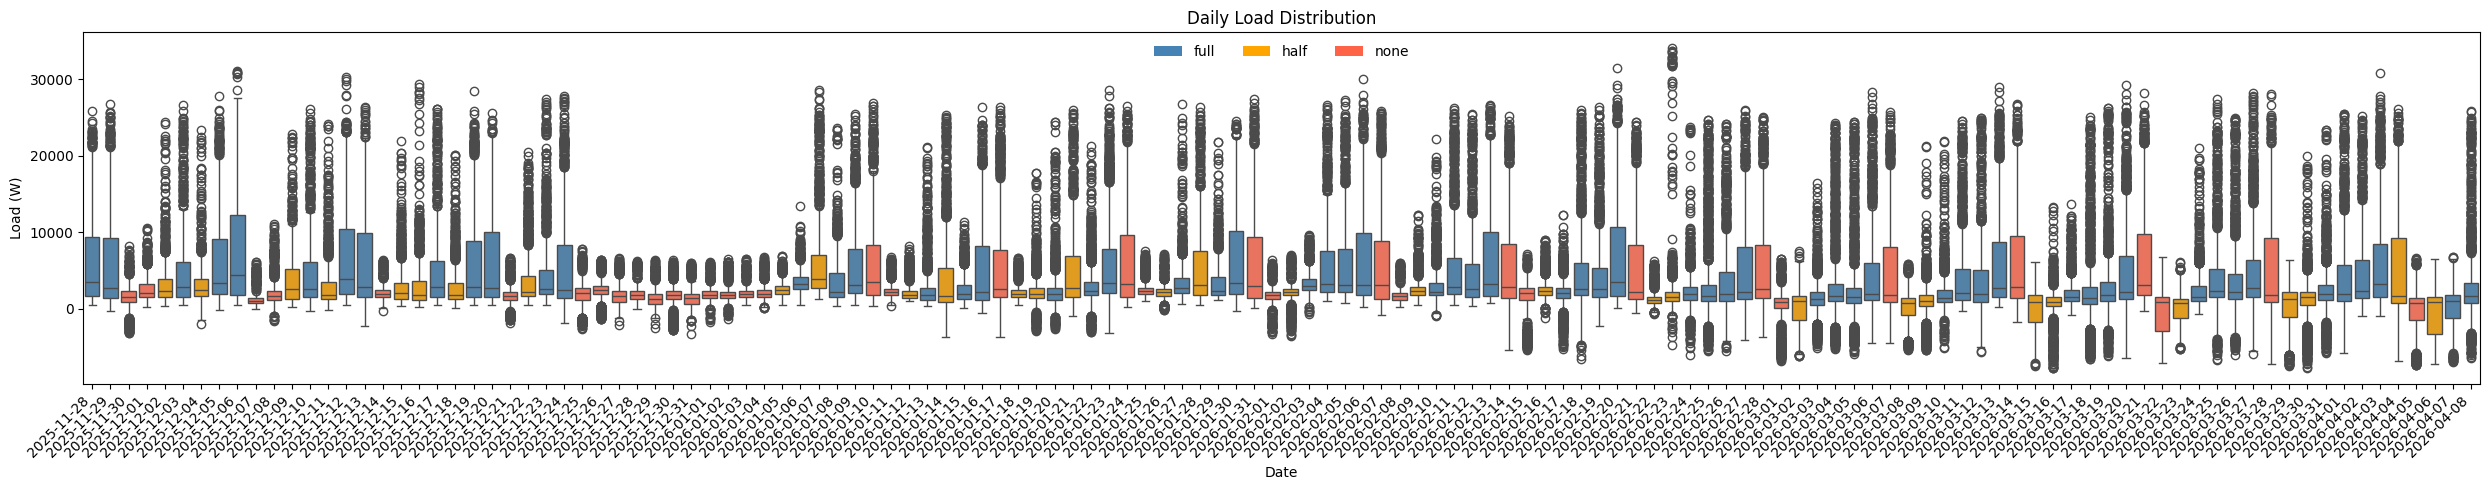

,count,mean,std,min,25%,50%,75%,max
timestamp,,,,,,,,
2025-11-28,1439.0,6200.92,5909.77,447.93,1684.22,3500.98,9455.06,25916.90
2025-11-29,1440.0,5748.48,6167.23,-308.64,1369.02,2774.97,9241.31,26838.28
2025-11-30,1440.0,1670.13,1537.39,-3156.72,947.40,1592.38,2395.70,8205.80
2025-12-01,1440.0,2579.47,1510.34,284.43,1548.58,2126.93,3261.06,10566.67
2025-12-02,1439.0,3313.73,3036.05,357.53,1576.91,2323.83,3886.12,24374.62
...,...,...,...,...,...,...,...,...
2026-04-04,1437.0,4883.72,6890.36,-6821.92,793.98,1646.00,9255.35,26110.82
2026-04-05,1440.0,-186.46,2617.58,-7387.52,-1487.85,813.23,1393.45,6684.62
2026-04-06,1440.0,-698.57,3104.82,-7154.53,-3283.65,893.19,1488.33,6553.20


In [40]:
plt.figure(figsize=(25, 5))
sns.boxplot(data=df, x=df.index.normalize(), y='load',
            hue=df['day_class'], palette=color_map, legend=False)
plt.title("Daily Load Distribution")
plt.xlabel("Date")
plt.ylabel("Load (W)")
plt.xticks(rotation=45, ha='right')

handles = [Patch(facecolor=color_map[cls], label=cls) for cls in color_map]
plt.legend(handles=handles, loc='upper center', bbox_to_anchor=(0.5, 1), ncols=3, frameon=False)
plt.tight_layout()
plt.show()

display(df.groupby(df.index.normalize())['load'].describe().round(2))

By day of week

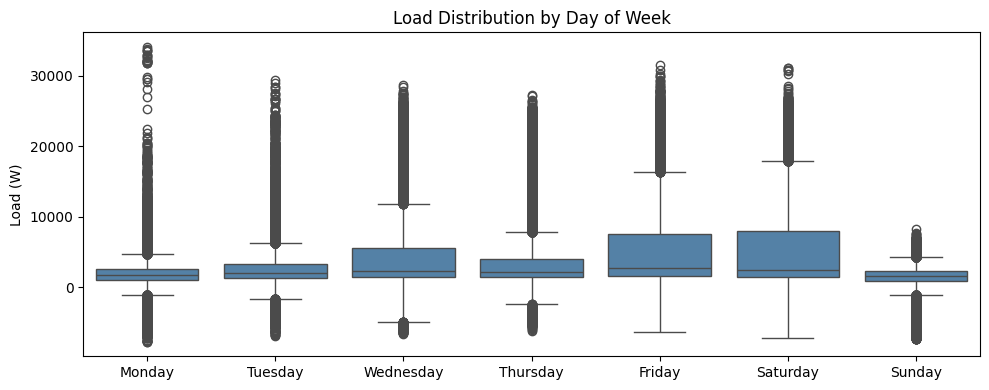

,count,mean,std,min,25%,50%,75%,max
timestamp,,,,,,,,
Monday,27344.0,1823.15,2574.78,-7742.17,1063.51,1768.60,2500.17,34057.93
Tuesday,27350.0,2689.61,2999.30,-6894.20,1288.05,2039.52,3255.11,29371.43
Wednesday,27331.0,4365.84,5403.12,-6644.41,1354.15,2309.05,5545.81,28626.30
Thursday,25918.0,3478.52,4206.85,-6210.00,1371.26,2124.78,3922.15,27290.02
Friday,27351.0,5523.30,5913.75,-6455.12,1621.23,2723.65,7519.20,31515.92
Saturday,27352.0,5412.24,6121.53,-7232.90,1368.23,2458.97,7960.20,31137.08
Sunday,27360.0,1284.03,2014.12,-7417.85,879.04,1575.97,2206.50,8205.80


In [41]:
days_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
plt.figure(figsize=(10, 4))
sns.boxplot(data=df, x=df.index.day_name(), y='load', order=days_order, color='steelblue')
plt.title("Load Distribution by Day of Week")
plt.xlabel("")
plt.ylabel("Load (W)")
plt.tight_layout()
plt.show()

display(df.groupby(df.index.day_name())['load'].describe().round(2).reindex(days_order))

By hour

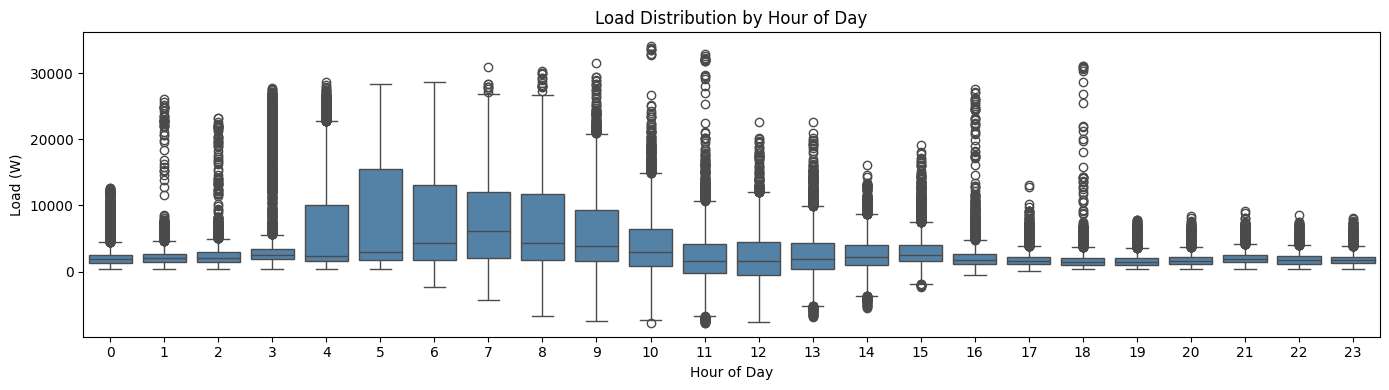

,count,mean,std,min,25%,50%,75%,max
timestamp,,,,,,,,
0,7920.0,2264.95,1687.11,402.60,1305.88,1843.79,2559.04,12588.13
1,7919.0,2368.10,1972.12,401.70,1386.30,1988.37,2707.35,26110.82
2,7919.0,2444.30,1802.01,397.63,1520.72,2130.68,2913.38,23202.29
3,7920.0,4430.74,5741.62,404.93,1877.03,2479.62,3374.63,27808.30
4,7919.0,6464.58,7394.09,404.53,1643.58,2347.87,10083.17,28626.30
5,7916.0,8432.86,7992.82,454.13,1815.48,2981.30,15513.10,28318.14
6,7920.0,7562.32,6666.38,-2334.33,1830.45,4324.76,13075.08,28613.97
7,7896.0,7268.36,6151.34,-4289.30,2076.17,6096.07,11981.96,30861.03
8,7915.0,6608.65,6752.03,-6699.83,1742.97,4299.65,11711.28,30258.63


In [42]:
plt.figure(figsize=(14, 4))
sns.boxplot(data=df, x=df.index.hour, y='load', color='steelblue')
plt.title("Load Distribution by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Load (W)")
plt.tight_layout()
plt.show()

display(df.groupby(df.index.hour)['load'].describe().round(2))

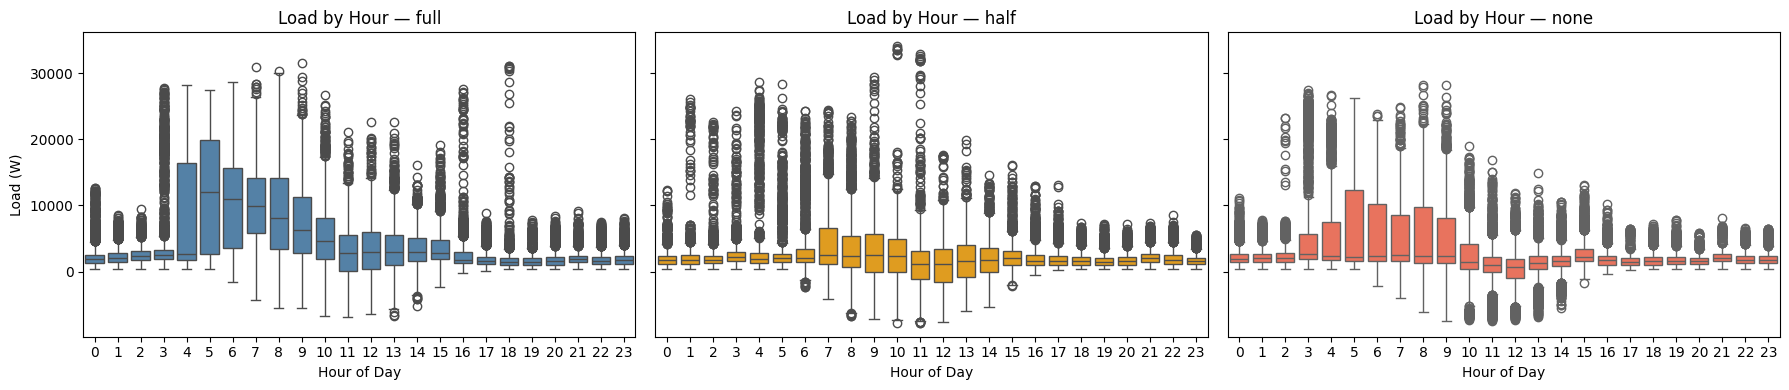


full:


,count,mean,std,min,25%,50%,75%,max
timestamp,,,,,,,,
0,3780.0,2335.95,1827.14,405.67,1316.82,1885.65,2585.50,12588.13
1,3779.0,2389.10,1442.15,401.70,1478.38,2066.27,2829.42,8551.65
2,3780.0,2521.31,1160.64,397.63,1735.70,2352.09,3116.53,9480.60
3,3780.0,3800.70,4504.89,408.25,1955.79,2534.83,3339.40,27808.30
4,3780.0,8125.52,8189.52,425.08,1769.03,2683.82,16400.17,28236.73
5,3780.0,12157.96,8202.85,470.77,2662.99,12085.40,19909.56,27481.68
6,3780.0,10549.90,6557.65,-1615.30,3621.81,10923.42,15613.80,28613.97
7,3756.0,10101.74,5744.25,-4289.30,5816.39,9976.05,14112.96,30861.03
8,3775.0,8968.08,6667.77,-5516.45,3399.58,8117.93,14078.74,30258.63



half:


,count,mean,std,min,25%,50%,75%,max
timestamp,,,,,,,,
0,1920.0,2047.61,1522.18,402.63,1137.82,1708.22,2351.60,12268.62
1,1920.0,2393.77,3127.78,402.63,1190.28,1727.89,2450.42,26110.82
2,1919.0,2316.12,2639.37,404.35,1247.00,1752.91,2409.52,22653.37
3,1920.0,2830.79,2561.47,404.93,1624.53,2215.62,2964.14,24249.29
4,1919.0,4244.17,6309.27,404.53,1342.83,1973.40,2828.26,28626.30
5,1917.0,3497.99,4371.05,454.13,1513.08,1999.63,2670.07,28318.14
6,1920.0,3913.00,4814.20,-2334.33,1434.49,2000.87,3429.37,24287.47
7,1920.0,4243.27,5186.57,-4208.17,1222.14,2444.94,6647.59,24374.62
8,1920.0,3461.23,5613.22,-6699.83,752.23,2389.02,5448.13,23376.40



none:


,count,mean,std,min,25%,50%,75%,max
timestamp,,,,,,,,
0,2220.0,2332.02,1553.93,402.60,1388.22,1892.79,2653.61,11108.47
1,2220.0,2310.14,1368.16,403.10,1434.14,2023.89,2715.50,7873.72
2,2220.0,2423.99,1801.91,414.25,1491.03,2092.38,2816.86,23202.29
3,2220.0,6887.24,8275.50,434.83,1975.39,2588.23,5705.26,27438.20
4,2220.0,5555.87,6055.74,452.85,1699.38,2381.34,7472.68,26730.43
5,2219.0,6350.50,6913.33,461.27,1596.95,2236.20,12370.14,26240.38
6,2220.0,5631.52,5904.36,-2159.05,1622.88,2416.98,10179.81,23865.92
7,2220.0,5090.90,5410.81,-4021.72,1580.27,2476.22,8494.77,24905.65
8,2220.0,5318.64,6326.54,-6138.77,1379.02,2304.29,9784.82,28120.32


In [43]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharey=True)

for ax, cls in zip(axes, ['full', 'half', 'none']):
    mask = df['day_class'] == cls
    sns.boxplot(data=df[mask], x=df[mask].index.hour, y='load',
                color=color_map[cls], ax=ax)
    ax.set_title(f"Load by Hour — {cls}")
    ax.set_xlabel("Hour of Day")
    ax.set_ylabel("Load (W)" if ax == axes[0] else "")

plt.tight_layout()
plt.show()

for cls in ['full', 'half', 'none']:
    mask = df['day_class'] == cls
    print(f"\n{cls}:")
    display(df[mask].groupby(df[mask].index.hour)['load'].describe().round(2))

### 1.3: Data Cleaning

Clean Data

Adding flag columns for data quality issues without altering original load values (used in preprocessing to filter rows before modeling):

- `is_missing`: Load value is `NaN` — sensor did not record a value
- `is_zero`: Load value is exactly `0` — either everything is off or solar perfectly offsets consumption
- `is_negative`: Load value is `< 0` — solar production exceeds consumption, surplus sent to grid
- `is_high_outlier`: Load value exceeds the 99th percentile — unusually high consumption reading
- `is_low_outlier`: Load value is below the 1st percentile — unusually low or negative reading

In [44]:
def clean_data(df: pd.DataFrame) -> pd.DataFrame:
    """
    Flag data quality issues without altering original load values.
    Adds boolean flag columns for missing, zero, and outlier load values.
    """
    df = df.copy()

    # Flags
    df["is_missing"]      = df["load"].isna()
    df["is_zero"]         = df["load"] == 0
    df["is_negative"]     = df["load"] < 0
    df["is_low_outlier"]  = df["load"] < df["load"].quantile(0.01)
    df["is_high_outlier"] = df["load"] > df["load"].quantile(0.99)

    # Summary
    total = len(df)
    for col in ["is_missing", "is_zero", "is_negative", "is_low_outlier", "is_high_outlier"]:
        count = df[col].sum()
        pct   = count / total * 100
        print(f"  {col:15s}: {count:>7,} ({pct:.2f}%)")

    return df

# Run
df_clean = clean_data(df_raw)
df_clean.head()

  is_missing     :  46,099 (0.40%)
  is_zero        :     261 (0.00%)
  is_negative    : 703,079 (6.16%)
  is_low_outlier : 113,509 (1.00%)
  is_high_outlier: 113,566 (1.00%)


,load,day_class,is_missing,is_zero,is_negative,is_low_outlier,is_high_outlier
timestamp,,,,,,,
2025-11-28 00:00:00,1925.0,full,False,False,False,False,False
2025-11-28 00:00:01,1922.0,full,False,False,False,False,False
2025-11-28 00:00:02,1921.0,full,False,False,False,False,False
2025-11-28 00:00:03,1921.0,full,False,False,False,False,False
2025-11-28 00:00:04,1926.0,full,False,False,False,False,False


Save Data

In [45]:
save_clean(df_clean)

✓ Save data to /content/drive/MyDrive/ElectricLoadForecast/data/002_clean/load.parquet


### 1.4: Downsample

Resolution defines how frequently your data is sampled (i.e., the time step between observations).

| Resolution | Intervals/Day | Description |
|------------|--------------|-------------|
| `1sec` | 86,400 | Raw resolution — instantaneous load recorded by the meter |
| `1min` | 1,440 | High granularity, captures minute-level patterns |
| `5min` | 288 | Moderate granularity, reduces noise |
| `10min` | 144 | Balanced granularity |
| `15min` | 96 | Standard energy industry resolution |
| `30min` | 48 | Coarser, captures half-hour load blocks |
| `1hr` | 24 | Low granularity, captures hourly patterns |

The raw 1-second data is **downsampled** to lower resolutions by **averaging load per interval**:

- `1min`: Average of 60 1-second readings → represents avg load for that minute
- `5min`: Average of 300 1-second readings → represents avg load for that 5-minute block
- `15min`: Average of 900 1-second readings → represents avg load for that 15-minute block

This reduces noise, speeds up feature engineering and modeling, and better matches the forecast horizons.

In [46]:
def downsample(df: pd.DataFrame, resolution: str) -> pd.DataFrame:
    """
    Downsample to target resolution by averaging load per interval.
    Reattaches day_class and recomputes quality flags at new resolution.
    """

    # Downsample load
    df_resampled = df["load"].resample(resolution).mean().to_frame()
    print(f"  shape: {df_resampled.shape}")

    # Re-attach day_class
    day_class_map = df.groupby(df.index.date)["day_class"].first()
    df_resampled["day_class"] = pd.Series(df_resampled.index.date, index=df_resampled.index).map(day_class_map)

    # Recompute flags using clean_data
    df_resampled = clean_data(df_resampled)

    return df_resampled


# ── RUN ───────────────────────────────────────────────────────────────────────
RESOLUTIONS = ["1min", "5min", "10min", "15min", "30min", "1h"]

dfs_downsampled = {}
for res in RESOLUTIONS:
    print(f"\n── {res} ──────────────────────")
    dfs_downsampled[res] = downsample(df_clean, res)


── 1min ──────────────────────
  shape: (190080, 1)
  is_missing     :      74 (0.04%)
  is_zero        :       0 (0.00%)
  is_negative    :  11,340 (5.97%)
  is_low_outlier :   1,901 (1.00%)
  is_high_outlier:   1,901 (1.00%)

── 5min ──────────────────────
  shape: (38016, 1)
  is_missing     :       3 (0.01%)
  is_zero        :       0 (0.00%)
  is_negative    :   2,214 (5.82%)
  is_low_outlier :     381 (1.00%)
  is_high_outlier:     381 (1.00%)

── 10min ──────────────────────
  shape: (19008, 1)
  is_missing     :       1 (0.01%)
  is_zero        :       0 (0.00%)
  is_negative    :   1,081 (5.69%)
  is_low_outlier :     191 (1.00%)
  is_high_outlier:     191 (1.00%)

── 15min ──────────────────────
  shape: (12672, 1)
  is_missing     :       0 (0.00%)
  is_zero        :       0 (0.00%)
  is_negative    :     718 (5.67%)
  is_low_outlier :     127 (1.00%)
  is_high_outlier:     127 (1.00%)

── 30min ──────────────────────
  shape: (6336, 1)
  is_missing     :       0 (0.00%)
  

Save Data

In [47]:
for res, df in dfs_downsampled.items():
  save_downsampled(df, res)

✓ Save data to /content/drive/MyDrive/ElectricLoadForecast/data/003_downsample/1min_load.parquet
✓ Save data to /content/drive/MyDrive/ElectricLoadForecast/data/003_downsample/5min_load.parquet
✓ Save data to /content/drive/MyDrive/ElectricLoadForecast/data/003_downsample/10min_load.parquet
✓ Save data to /content/drive/MyDrive/ElectricLoadForecast/data/003_downsample/15min_load.parquet
✓ Save data to /content/drive/MyDrive/ElectricLoadForecast/data/003_downsample/30min_load.parquet
✓ Save data to /content/drive/MyDrive/ElectricLoadForecast/data/003_downsample/1h_load.parquet


### 1.5: Feature Engineering

Features are created at each target resolution after downsampling. Relevant features are selected per model and forecast horizon downstream.

**Time Features**

---



Raw calendar components extracted from the timestamp. Captures the position of each reading in time.

| Feature | Description |
|---------|-------------|
| `minute` | Minute of the hour (0–59) |
| `hour` | Hour of the day (0–23) |
| `day` | Day of the month (1–31) |
| `dayofweek` | Day of the week (0=Monday, 6=Sunday) |
| `dayofyear` | Day of the year (1–365) |
| `month` | Month of the year (1–12) |
| `is_weekend` | 1 if Saturday or Sunday, 0 otherwise |

<br>

**Cyclical Encoding**

---



Sine/cosine transformations of time features so the model understands that 11pm and midnight are close, and January and December are close.

| Feature | Description |
|---------|-------------|
| `hour_sin`, `hour_cos` | Cyclical encoding of hour (cycle = 24hrs) |
| `min_sin`, `min_cos` | Cyclical encoding of minute (cycle = 60min) |
| `dow_sin`, `dow_cos` | Cyclical encoding of day of week (cycle = 7 days) |
| `month_sin`, `month_cos` | Cyclical encoding of month (cycle = 12 months) |
| `doy_sin`, `doy_cos` | Cyclical encoding of day of year (cycle = 365 days) |

<br>

**Solar Proxy Features**

---

Time-based approximations of solar PV activity, relevant because the dataset includes net load (consumption minus solar production).

| Feature | Description |
|---------|-------------|
| `solar_angle` | Cosine of time relative to solar noon — peaks at 12pm, minimum at midnight |
| `is_daylight` | 1 if between 7am–7pm when solar production is possible, 0 otherwise |

<br>

**Lag Features**

---


Load value at a specific point in the past. Captures the direct influence of recent and historical load on current load.

| Feature | Description |
|---------|-------------|
| `lag_X` | Load value exactly X ago |

Computed windows vary by resolution:

| Resolution | Lag Windows |
|------------|-------------|
| `1min` | 1min, 2min, 3min, 5min, 10min, 15min, 30min, 1hr, 2hr, 3hr, 6hr, 12hr, 1day, 1week |
| `5min` | 5min, 10min, 15min, 30min, 1hr, 2hr, 3hr, 6hr, 12hr, 1day, 1week |
| `10min` | 10min, 20min, 30min, 1hr, 2hr, 3hr, 6hr, 12hr, 1day, 1week |
| `15min` | 15min, 30min, 1hr, 2hr, 3hr, 6hr, 12hr, 1day, 1week |
| `30min` | 30min, 1hr, 2hr, 3hr, 6hr, 12hr, 1day, 1week |
| `1h` | 1hr, 2hr, 3hr, 6hr, 12hr, 1day, 1week |

<br>

**Rolling Features**

---

Summary statistics over a sliding window of past load values. Captures recent level, volatility, and range.

| Feature | Description |
|---------|-------------|
| `roll_mean_X` | Average load over the past X window |
| `roll_std_X` | Standard deviation of load over the past X window |
| `roll_max_X` | Maximum load over the past X window |
| `roll_min_X` | Minimum load over the past X window |

Computed windows vary by resolution:

| Resolution | Windows |
|------------|---------|
| `1min` | 5min, 15min, 30min, 1hr, 3hr, 6hr |
| `5min` | 15min, 30min, 1hr, 3hr, 6hr |
| `10min` | 30min, 1hr, 3hr, 6hr |
| `15min` | 30min, 1hr, 3hr, 6hr |
| `30min` | 1hr, 3hr, 6hr |
| `1h` | 3hr, 6hr, 12hr |

<br>

**Trend Features**

---

Captures the direction and magnitude of load change over recent windows.

| Feature | Description |
|---------|-------------|
| `delta_X` | Difference between load 1 interval ago and load X ago |
| `slope_X` | Linear rate of change estimated over a rolling window of X |

Delta computed for same windows as rolling features. Slope computed for:

| Resolution | Slope Windows |
|------------|---------------|
| `1min` | 5min, 15min, 30min, 1hr |
| `5min` | 15min, 30min, 1hr |
| `10min` | 30min, 1hr |
| `15min` | 30min, 1hr |
| `30min` | 1hr, 3hr |
| `1h` | 3hr, 6hr |

In [48]:
# ── Resolution Feature Config ─────────────────────────────────────────────────
# All time values in minutes. Intervals computed inside function based on resolution.

RESOLUTION_MINUTES = {
    "1min": 1, "5min": 5, "10min": 10,
    "15min": 15, "30min": 30, "1h": 60
}

# Lag windows per resolution (in minutes)
LAG_CONFIG = {
    "1min":  [1, 2, 3, 5, 10, 15, 30, 60, 120, 180, 360, 720, 1440, 10080],
    "5min":  [5, 10, 15, 30, 60, 120, 180, 360, 720, 1440, 10080],
    "10min": [10, 20, 30, 60, 120, 180, 360, 720, 1440, 10080],
    "15min": [15, 30, 60, 120, 180, 360, 720, 1440, 10080],
    "30min": [30, 60, 120, 180, 360, 720, 1440, 10080],
    "1h":    [60, 120, 180, 360, 720, 1440, 10080],
}

# Rolling/delta/slope windows per resolution (in minutes)
WINDOW_CONFIG = {
    "1min":  [5, 15, 30, 60, 180, 360],
    "5min":  [15, 30, 60, 180, 360],
    "10min": [30, 60, 180, 360],
    "15min": [30, 60, 180, 360],
    "30min": [60, 180, 360],
    "1h":    [180, 360, 720],
}

SLOPE_CONFIG = {
    "1min":  [5, 15, 30, 60],
    "5min":  [15, 30, 60],
    "10min": [30, 60],
    "15min": [30, 60],
    "30min": [60, 180],
    "1h":    [180, 360],
}

def minutes_to_label(minutes: int) -> str:
    """Convert minutes to a human readable label."""
    if minutes < 60:
        return f"{minutes}min"
    elif minutes < 1440:
        return f"{minutes // 60}hr"
    elif minutes < 10080:
        return f"{minutes // 1440}day"
    else:
        return f"{minutes // 10080}week"


def create_features(df: pd.DataFrame, resolution: str = "1min") -> pd.DataFrame:
    """
    Create features at the given resolution.
    All window configs are defined outside this function in LAG_CONFIG, WINDOW_CONFIG, SLOPE_CONFIG.
    """
    df = df.copy()
    load = df["load"]
    m = RESOLUTION_MINUTES[resolution]  # minutes per interval

    # ── Time Features ─────────────────────────────────────────────────────────
    df["minute"]     = df.index.minute
    df["hour"]       = df.index.hour
    df["day"]        = df.index.day
    df["dayofweek"]  = df.index.dayofweek
    df["dayofyear"]  = df.index.dayofyear
    df["month"]      = df.index.month
    df["is_weekend"] = (df["dayofweek"] >= 5).astype(int)

    # ── Cyclical Encoding ─────────────────────────────────────────────────────
    df["hour_sin"]  = np.sin(2 * np.pi * df["hour"] / 24)
    df["hour_cos"]  = np.cos(2 * np.pi * df["hour"] / 24)
    df["min_sin"]   = np.sin(2 * np.pi * df["minute"] / 60)
    df["min_cos"]   = np.cos(2 * np.pi * df["minute"] / 60)
    df["dow_sin"]   = np.sin(2 * np.pi * df["dayofweek"] / 7)
    df["dow_cos"]   = np.cos(2 * np.pi * df["dayofweek"] / 7)
    df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
    df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)
    df["doy_sin"]   = np.sin(2 * np.pi * df["dayofyear"] / 365)
    df["doy_cos"]   = np.cos(2 * np.pi * df["dayofyear"] / 365)

    # ── Solar Proxy ───────────────────────────────────────────────────────────
    df["solar_angle"] = np.cos(2 * np.pi * (df["hour"] - 12) / 24)
    df["is_daylight"] = ((df["hour"] >= 7) & (df["hour"] <= 19)).astype(int)

    # ── Lag Features ──────────────────────────────────────────────────────────
    for minutes in LAG_CONFIG[resolution]:
        intervals = minutes // m
        label = minutes_to_label(minutes)
        df[f"lag_{label}"] = load.shift(intervals)

    # ── Rolling Features ──────────────────────────────────────────────────────
    for minutes in WINDOW_CONFIG[resolution]:
        window = minutes // m
        label  = minutes_to_label(minutes)
        base   = load.shift(1).rolling(window)
        df[f"roll_mean_{label}"] = base.mean()
        df[f"roll_std_{label}"]  = base.std()
        df[f"roll_max_{label}"]  = base.max()
        df[f"roll_min_{label}"]  = base.min()

    # ── Trend Features ────────────────────────────────────────────────────────
    for minutes in WINDOW_CONFIG[resolution]:
        shift = minutes // m
        label = minutes_to_label(minutes)
        df[f"delta_{label}"] = load.shift(1) - load.shift(shift)

    # ── Slope Features (vectorized) ───────────────────────────────────────────
    for minutes in SLOPE_CONFIG[resolution]:
        window = minutes // m
        label  = minutes_to_label(minutes)
        n      = window
        x      = np.arange(n)
        sum_x  = x.sum()
        sum_x2 = (x ** 2).sum()
        denom  = n * sum_x2 - sum_x ** 2
        rolled = load.shift(1).rolling(window)
        sum_y  = rolled.sum()
        sum_xy = rolled.apply(lambda y: (x * y).sum(), raw=True)
        df[f"slope_{label}"] = (n * sum_xy - sum_x * sum_y) / denom

    return df


# ── Apply to all resolutions ──────────────────────────────────────────────────
dfs_featured = {}
for res, df in dfs_downsampled.items():
    print(f"Creating features for {res}...", end=" ")
    dfs_featured[res] = create_features(df, resolution=res)
    print(f"{dfs_featured[res].shape[1]} columns, {dfs_featured[res].shape[0]:,} rows")

Creating features for 1min... 74 columns, 190,080 rows
Creating features for 5min... 65 columns, 38,016 rows
Creating features for 10min... 58 columns, 19,008 rows
Creating features for 15min... 57 columns, 12,672 rows
Creating features for 30min... 51 columns, 6,336 rows
Creating features for 1h... 50 columns, 3,168 rows


View Features

In [49]:
for res, df in dfs_featured.items():
  print(f"{res} {dfs_featured[res].shape}")
  print("--------------------------------------------------------")
  print(df.columns)
  print("")

1min (190080, 74)
--------------------------------------------------------
Index(['load', 'day_class', 'is_missing', 'is_zero', 'is_negative',
       'is_low_outlier', 'is_high_outlier', 'minute', 'hour', 'day',
       'dayofweek', 'dayofyear', 'month', 'is_weekend', 'hour_sin', 'hour_cos',
       'min_sin', 'min_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos',
       'doy_sin', 'doy_cos', 'solar_angle', 'is_daylight', 'lag_1min',
       'lag_2min', 'lag_3min', 'lag_5min', 'lag_10min', 'lag_15min',
       'lag_30min', 'lag_1hr', 'lag_2hr', 'lag_3hr', 'lag_6hr', 'lag_12hr',
       'lag_1day', 'lag_1week', 'roll_mean_5min', 'roll_std_5min',
       'roll_max_5min', 'roll_min_5min', 'roll_mean_15min', 'roll_std_15min',
       'roll_max_15min', 'roll_min_15min', 'roll_mean_30min', 'roll_std_30min',
       'roll_max_30min', 'roll_min_30min', 'roll_mean_1hr', 'roll_std_1hr',
       'roll_max_1hr', 'roll_min_1hr', 'roll_mean_3hr', 'roll_std_3hr',
       'roll_max_3hr', 'roll_min_3hr', 'ro

Save Data

In [50]:
for res, df in dfs_featured.items():
  save_featured(df, res)

✓ Save data to /content/drive/MyDrive/ElectricLoadForecast/data/004_featured/1min_load.parquet
✓ Save data to /content/drive/MyDrive/ElectricLoadForecast/data/004_featured/5min_load.parquet
✓ Save data to /content/drive/MyDrive/ElectricLoadForecast/data/004_featured/10min_load.parquet
✓ Save data to /content/drive/MyDrive/ElectricLoadForecast/data/004_featured/15min_load.parquet
✓ Save data to /content/drive/MyDrive/ElectricLoadForecast/data/004_featured/30min_load.parquet
✓ Save data to /content/drive/MyDrive/ElectricLoadForecast/data/004_featured/1h_load.parquet


### 1.6: Preprocessing

Generic preprocessing applied to all resolutions before modeling. Model-specific steps (scaling, feature selection) are applied per model in the training step.


| Step | Description |
|------|-------------|
| Drop missing | Remove rows where load was not recorded (`is_missing`) |
| Drop NaNs | Remove warmup rows produced by lag and rolling features |
| Keep flag columns | Retain `is_zero`, `is_negative`, `is_low_outlier`, `is_high_outlier` as features for the model to learn from |
| Encode `day_class` | Ordinal encode: `none=0`, `half=1`, `full=2` |
| Train/Val/Test split | Split chronologically by time — never randomly |

[**Train/Val/Test Split:**](https://en.wikipedia.org/wiki/Training,_validation,_and_test_data_sets)  
- **Train**: all data up to 14 days before end
- **Validation**: 14 days before test period, used for hyperparameter tuning
- **Test**: final 14 days, used only for final evaluation



── 1min ──────────────────────────────
  Train: 2025-12-05 → 2026-03-02 | (121550, 73)
  Val:   2026-03-02 → 2026-03-21 | (25901, 73)
  Test:  2026-03-21 → 2026-04-08 | (25497, 73)


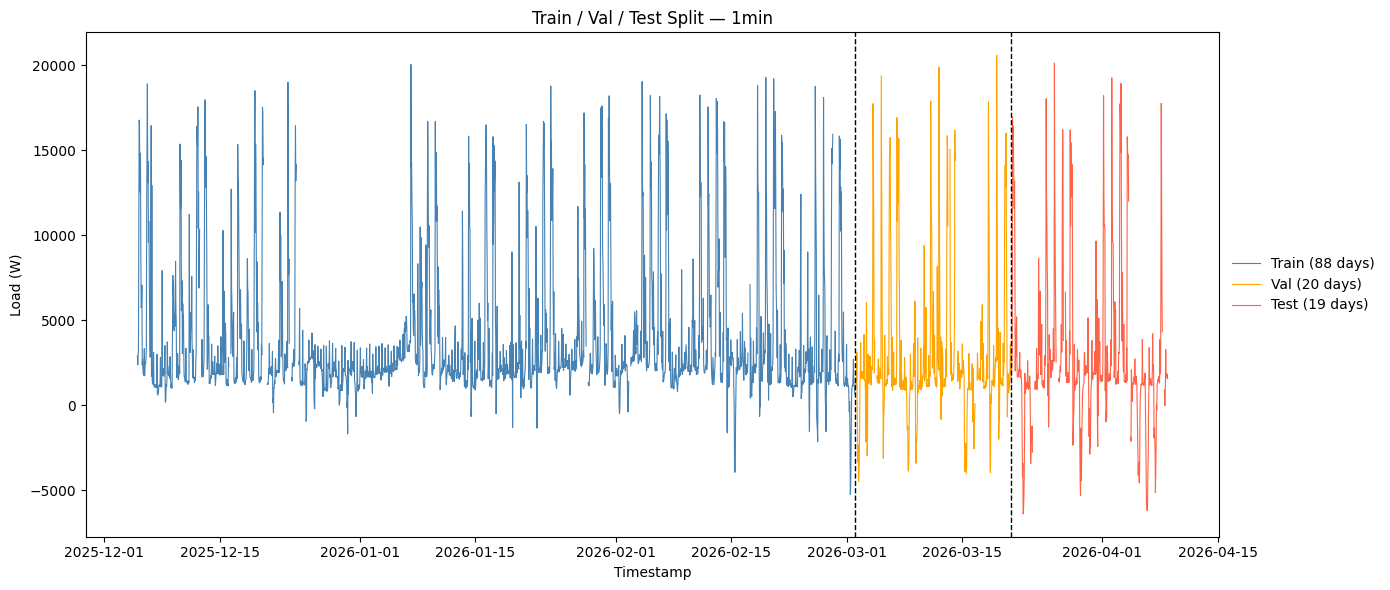


── 5min ──────────────────────────────
  Train: 2025-12-05 → 2026-03-02 | (24901, 64)
  Val:   2026-03-02 → 2026-03-21 | (5473, 64)
  Test:  2026-03-21 → 2026-04-08 | (5472, 64)


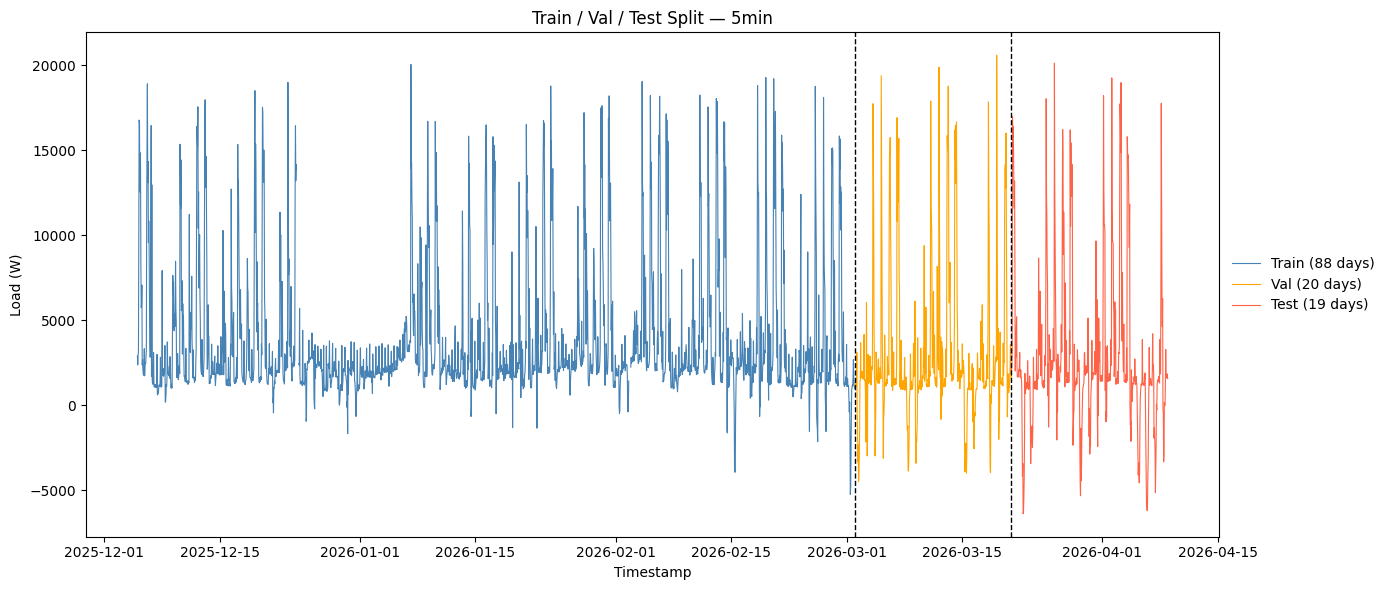


── 10min ──────────────────────────────
  Train: 2025-12-05 → 2026-03-02 | (12489, 57)
  Val:   2026-03-02 → 2026-03-21 | (2737, 57)
  Test:  2026-03-21 → 2026-04-08 | (2736, 57)


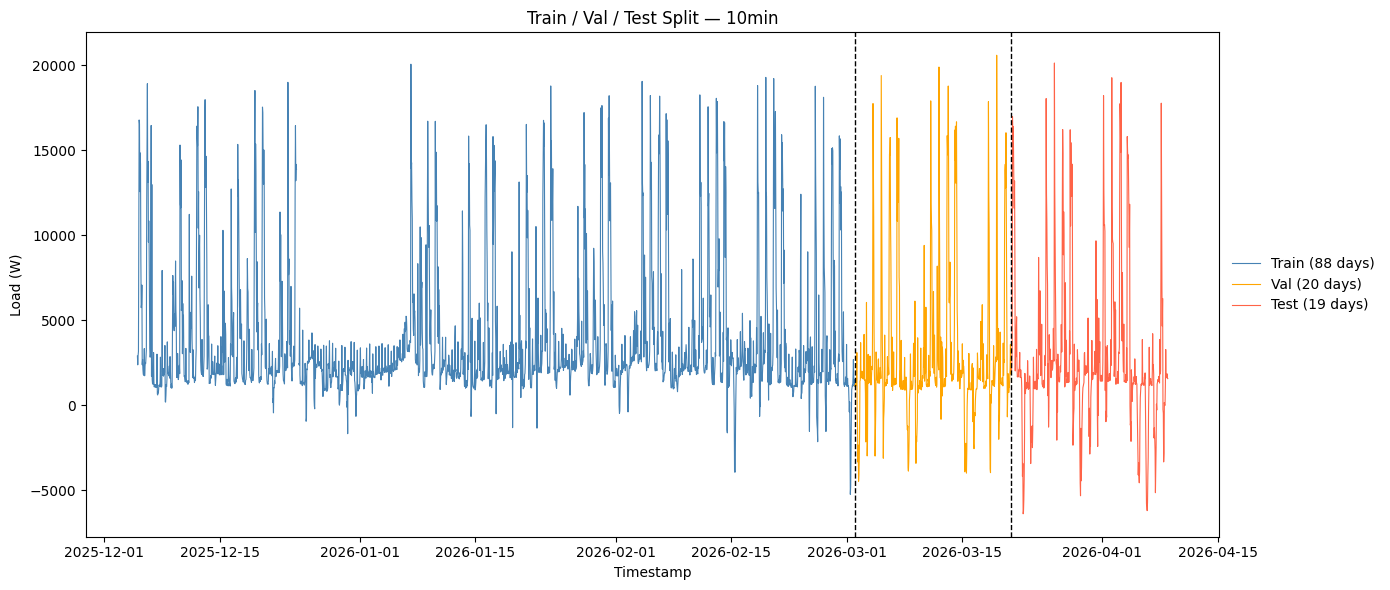


── 15min ──────────────────────────────
  Train: 2025-12-05 → 2026-03-02 | (8353, 56)
  Val:   2026-03-02 → 2026-03-21 | (1825, 56)
  Test:  2026-03-21 → 2026-04-08 | (1824, 56)


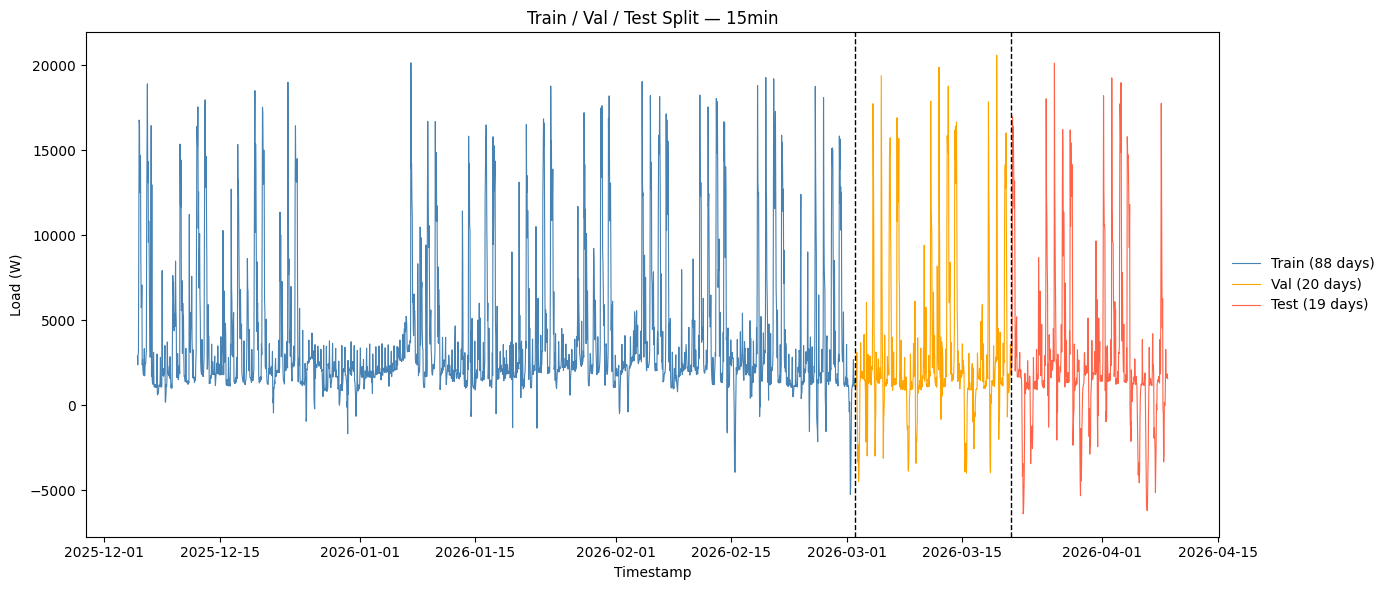


── 30min ──────────────────────────────
  Train: 2025-12-05 → 2026-03-02 | (4177, 50)
  Val:   2026-03-02 → 2026-03-21 | (913, 50)
  Test:  2026-03-21 → 2026-04-08 | (912, 50)


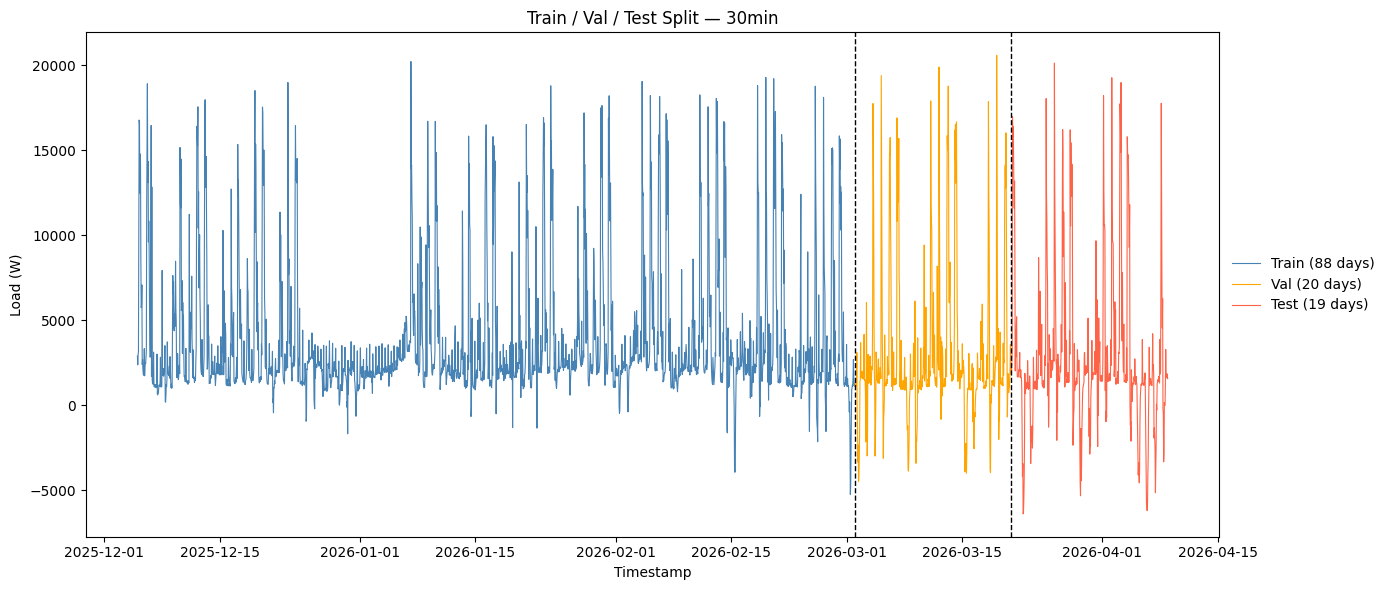


── 1h ──────────────────────────────
  Train: 2025-12-05 → 2026-03-02 | (2089, 49)
  Val:   2026-03-02 → 2026-03-21 | (457, 49)
  Test:  2026-03-21 → 2026-04-08 | (456, 49)


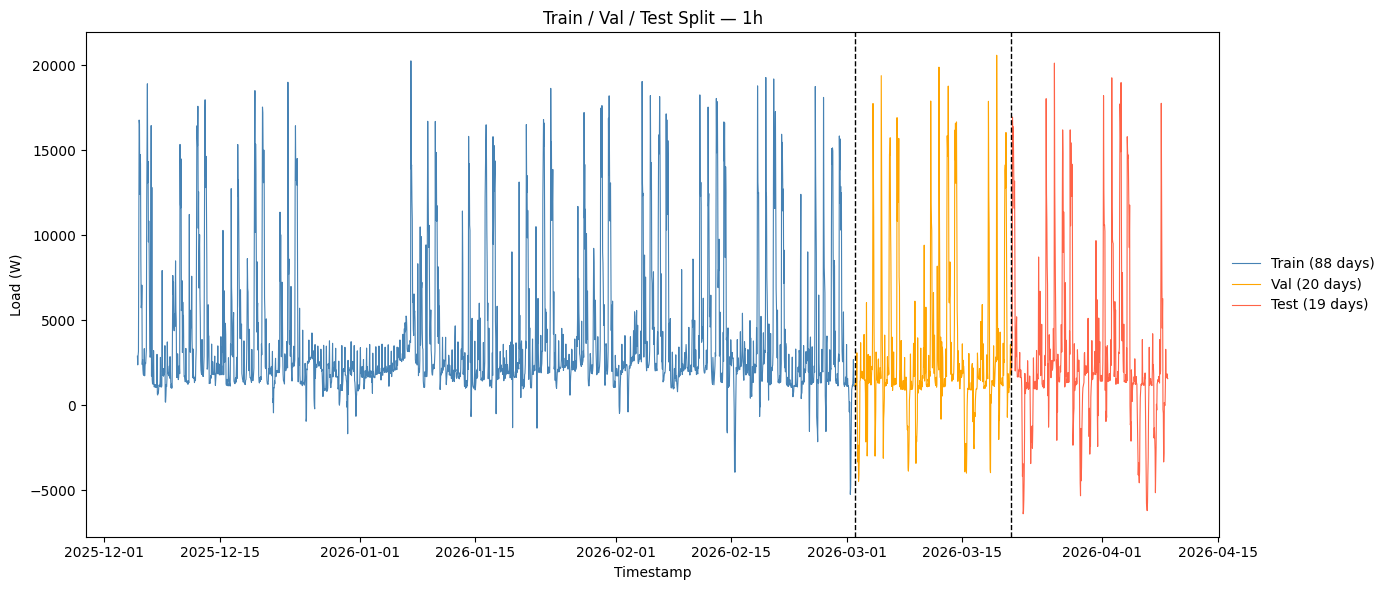

In [51]:
# ── CONFIG ────────────────────────────────────────────────────────────────────
VAL_SIZE  = 0.15
TEST_SIZE = 0.15

CATEGORICAL_COLS = ["day_class"]
FLAG_COLS        = ["is_missing", "is_zero", "is_negative", "is_low_outlier", "is_high_outlier"]
# ─────────────────────────────────────────────────────────────────────────────


def train_val_test_split(df: pd.DataFrame, val_size: float = VAL_SIZE, test_size: float = TEST_SIZE):
    """Train/Val/Test split by percent of days, chronologically."""
    n_days = df.index.normalize().nunique()
    n_test = int(np.ceil(n_days * test_size))
    n_val  = int(np.ceil(n_days * val_size))

    dates     = df.index.normalize().unique().sort_values()
    val_date  = dates[-n_test - n_val]
    test_date = dates[-n_test]

    train = df.loc[:val_date]
    val   = df.loc[val_date:test_date]
    test  = df.loc[test_date:]
    return train, val, test


def plot_split(train: pd.DataFrame, val: pd.DataFrame, test: pd.DataFrame, resolution: str):
    """Visualize train/val/test split."""
    fig, ax = plt.subplots(figsize=(14, 6))

    ax.plot(train["load"].resample("1h").mean(), color="steelblue", linewidth=0.8, label=f"Train ({train.index.normalize().nunique()} days)")
    ax.plot(val["load"].resample("1h").mean(),   color="orange",    linewidth=0.8, label=f"Val ({val.index.normalize().nunique()} days)")
    ax.plot(test["load"].resample("1h").mean(),  color="tomato",    linewidth=0.8, label=f"Test ({test.index.normalize().nunique()} days)")

    ax.axvline(train.index.max(), color="black", linestyle="--", linewidth=1)
    ax.axvline(val.index.max(),   color="black", linestyle="--", linewidth=1)

    ax.set_title(f"Train / Val / Test Split — {resolution}")
    ax.set_xlabel("Timestamp")
    ax.set_ylabel("Load (W)")
    ax.legend(loc="center left", bbox_to_anchor=(1, 0.5), frameon=False)
    plt.tight_layout()
    plt.show()


def preprocess(df: pd.DataFrame, resolution: str) -> tuple:
    """
    Generic preprocessing for all models and resolutions.
    - Drops missing and NaN rows
    - Keeps flag columns as features
    - Encodes categoricals
    - Returns df_train, df_val, df_test (X/y split happens per model)
    """
    df = df.copy()

    # 1. Drop missing load and NaN rows (warmup)
    df = df[~df["is_missing"]].dropna()

    # 2. Drop is_missing column (no longer needed), keep other flags as features
    df = df.drop(columns=["is_missing"])

    # 3. Encode day_class
    enc = OrdinalEncoder(categories=[["none", "half", "full"]])
    df["day_class"] = enc.fit_transform(df[["day_class"]])

    # 4. Split
    df_train, df_val, df_test = train_val_test_split(df)

    print(f"  Train: {df_train.index.min().date()} → {df_train.index.max().date()} | {df_train.shape}")
    print(f"  Val:   {df_val.index.min().date()} → {df_val.index.max().date()} | {df_val.shape}")
    print(f"  Test:  {df_test.index.min().date()} → {df_test.index.max().date()} | {df_test.shape}")

    plot_split(df_train, df_val, df_test, resolution)

    return df_train, df_val, df_test


# ── RUN ───────────────────────────────────────────────────────────────────────
dfs_preprocessed = {}
for res, df in dfs_featured.items():
    print(f"\n── {res} ──────────────────────────────")
    df_train, df_val, df_test = preprocess(df, res)
    dfs_preprocessed[res] = {
        "train": df_train,
        "val":   df_val,
        "test":  df_test
    }

# Access like:
#df_train = dfs_preprocessed["1min"]["train"]
#df_val   = dfs_preprocessed["1min"]["val"]
#df_test  = dfs_preprocessed["1min"]["test"]

Ensure all day classifications are being tested

In [52]:
train_raw, val_raw, test_raw = train_val_test_split(dfs_featured["1min"])

for name, split in [("Train", train_raw), ("Val", val_raw), ("Test", test_raw)]:
    dist = split.groupby(split.index.normalize())["day_class"].first().value_counts()
    pct  = (dist / dist.sum() * 100).round(1)
    print(f"\n{name} ({split.index.normalize().nunique()} days):")
    print(pd.DataFrame({"days": dist, "%": pct}).to_string())


Train (93 days):
           days     %
day_class            
full         41  44.1
none         30  32.3
half         22  23.7

Val (21 days):
           days     %
day_class            
full         12  57.1
half          5  23.8
none          4  19.0

Test (20 days):
           days     %
day_class            
full         11  55.0
half          5  25.0
none          4  20.0


Save Data

In [53]:
for res, splits in dfs_preprocessed.items():
  for split in splits:
    df = dfs_preprocessed[res][split]
    save_preprocessed(df, res, split)

✓ Save data to /content/drive/MyDrive/ElectricLoadForecast/data/005_preprocessed/1min_train_load.parquet
✓ Save data to /content/drive/MyDrive/ElectricLoadForecast/data/005_preprocessed/1min_val_load.parquet
✓ Save data to /content/drive/MyDrive/ElectricLoadForecast/data/005_preprocessed/1min_test_load.parquet
✓ Save data to /content/drive/MyDrive/ElectricLoadForecast/data/005_preprocessed/5min_train_load.parquet
✓ Save data to /content/drive/MyDrive/ElectricLoadForecast/data/005_preprocessed/5min_val_load.parquet
✓ Save data to /content/drive/MyDrive/ElectricLoadForecast/data/005_preprocessed/5min_test_load.parquet
✓ Save data to /content/drive/MyDrive/ElectricLoadForecast/data/005_preprocessed/10min_train_load.parquet
✓ Save data to /content/drive/MyDrive/ElectricLoadForecast/data/005_preprocessed/10min_val_load.parquet
✓ Save data to /content/drive/MyDrive/ElectricLoadForecast/data/005_preprocessed/10min_test_load.parquet
✓ Save data to /content/drive/MyDrive/ElectricLoadForecast/da

## Phase 2: Single-Step Forecasting

A single-step forecast (horizon-based) defines how far into the future the model predicts. For each horizon, the model predicts a single value — the expected average load for that future time interval.

We will focus on the following horizons for our forecasting:

| Horizon | Predicts | Resolution (Downsample) |
|---------|----------|----------|
| `1min` | Expected avg load over the next minute | `1min` |
| `5min` | Expected avg load over the next 5 minutes | `5min` |
| `10min` | Expected avg load over the next 10 minutes | `10min` |
| `15min` | Expected avg load over the next 15 minutes | `15min` |
| `30min` | Expected avg load over the next 30 minutes | `30min` |
| `1hr` | Expected avg load over the next hour | `1hr` |

For each horizon, we will downsample the data to match the horizon resolution.

Our goal is to find the **best model for each horizon**.

### Utils

In [206]:
def save_model(model_name: str, data: dict):
    """Save a single model's data as a joblib file."""
    for res, model_data in data.items():
        folder = BASE_PROJECT_PATH / model_name
        folder.mkdir(parents=True, exist_ok=True)
        filepath = folder / f"{res}.joblib"
        joblib.dump(model_data, filepath)
        print(f"✓ Saved {model_name} [{res}] → {filepath}")


def load_model(model_name: str, res: str) -> dict:
    """Load a single model's data from a joblib file."""
    filepath = BASE_PROJECT_PATH / model_name / f"{res}.joblib"
    model_data = joblib.load(filepath)
    print(f"✓ Loaded {model_name} [{res}] ← {filepath}")
    return model_data


def save_models(models: dict):
    """Save all models."""
    for model_name, data in models.items():
        save_model(model_name, data)


def load_models() -> dict:
    """Load all models back into models dict."""
    models = {}
    for model_folder in sorted(BASE_PROJECT_PATH.iterdir()):
        if not model_folder.is_dir():
            continue
        model_name = model_folder.name
        models[model_name] = {}
        for filepath in sorted(model_folder.glob("*.joblib")):
            res = filepath.stem
            models[model_name][res] = joblib.load(filepath)
            print(f"✓ Loaded {model_name} [{res}] ← {filepath}")
    return models

In [146]:
def evaluate(y_true: pd.Series, y_pred: pd.Series, _print = True) -> dict:
    """Evaluate model performance and return MAE, RMSE, WAPE metrics."""
    y_true = y_true.reset_index(drop=True)
    y_pred = y_pred.reset_index(drop=True)

    # Drop NaN rows
    mask   = ~(y_true.isna() | y_pred.isna())
    y_true = y_true[mask]
    y_pred = y_pred[mask]

    mae  = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    wape = (abs(y_true - y_pred).sum() / abs(y_true).sum()) * 100

    if _print:
      print(f"MAE: {mae:.1f}W | RMSE: {rmse:.1f}W | WAPE: {wape:.1f}%")
    return {"mae": mae, "rmse": rmse, "wape": wape}

def plot_true_vs_pred(y_true: pd.Series, y_pred: pd.Series, model_name: str, res: str):
    """Plot true vs predicted load values and display MAE, RMSE, WAPE metrics"""
    metrics = evaluate(y_true, y_pred, _print = False)
    y_true = y_true.reset_index(drop=True)
    y_pred = y_pred.reset_index(drop=True)

    # Drop NaN rows
    mask   = ~(y_true.isna() | y_pred.isna())
    y_true = y_true[mask]
    y_pred = y_pred[mask]

    # Compute metrics
    mae  = metrics["mae"]
    rmse = metrics["rmse"]
    wape = metrics["wape"]

    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(y_true.values, color="steelblue", linewidth=0.8, label="Actual")
    ax.plot(y_pred.values, color="tomato",    linewidth=0.8, label="Predicted", alpha=0.8)

    ax.set_title(f"{model_name} - {res} (MAE {mae:.1f}W | RMSE: {rmse:.1f}W | WAPE: {wape:.1f}%)")
    ax.set_xlabel("Step")
    ax.set_ylabel("Load (W)")
    ax.legend(loc="center left", bbox_to_anchor=(1, 0.5), frameon=False)
    plt.tight_layout()
    plt.show()

def plot_true_vs_pred_by_resolution(models: dict, model_name: str):
    """Plot true vs predicted load values by resolution."""
    for res, data in models[model_name].items():
      plot_true_vs_pred(
          data["test"]["true"],
          data["test"]["pred"],
          res = res,
          model_name=model_name
      )

def plot_metrics_by_resolution(models: dict, model_name: str):
    """Bar chart of MAE, RMSE, WAPE per resolution."""
    model_data = models[model_name]
    resolutions = list(model_data.keys())
    mae_vals  = [model_data[res]["test"]["metrics"]["mae"]  for res in resolutions]
    rmse_vals = [model_data[res]["test"]["metrics"]["rmse"] for res in resolutions]
    wape_vals = [model_data[res]["test"]["metrics"]["wape"] for res in resolutions]

    x     = np.arange(len(resolutions))
    width = 0.25

    fig, axes = plt.subplots(1, 3, figsize=(14, 4))

    for ax, vals, label, color in zip(
        axes,
        [mae_vals, rmse_vals, wape_vals],
        ["MAE (W)", "RMSE (W)", "WAPE (%)"],
        ["steelblue", "orange", "tomato"]
    ):
        ax.bar(x, vals, width=0.6, color=color, alpha=0.8)
        ax.set_xticks(x)
        ax.set_xticklabels(resolutions)
        ax.set_xlabel("Resolution")
        ax.set_ylabel(label)
        ax.set_title(label)
        for i, v in enumerate(vals):
            ax.text(i, v, f"{v:.1f}", ha="center", va="bottom", fontsize=8)

    fig.suptitle(f"{model_name} — Test Metrics by Resolution", fontsize=12)
    plt.tight_layout()
    plt.show()

def plot_xgboost_feature_importance(model_data: dict, top_n: int = 10):
    """Plot top N feature importances for each resolution."""
    for res, data in model_data.items():
        model = data["model"]

        importance = pd.Series(
            model.feature_importances_,
            index=model.feature_names_in_
        ).sort_values(ascending=True).tail(top_n)

        print(f"\n── XGBoost Feature Importance ({res}) ──────────────────────────────")
        print(importance.sort_values(ascending=False))
        fig, ax = plt.subplots(figsize=(8, top_n * 0.35))
        importance.plot(kind="barh", ax=ax, color="steelblue", alpha=0.8)
        ax.set_title(f"XGBoost Feature Importance — {res} (Top {top_n})")
        ax.set_xlabel("Importance Score")
        plt.tight_layout()
        plt.show()

In [267]:
# ── Model color map ───────────────────────────────────────────────────────────
MODEL_COLORS = {model: plt.cm.tab10.colors[i] for i, model in enumerate(models.keys())}

def plot_model_comparison(models: dict):
    """Compare MAE, RMSE, WAPE across models and resolutions."""
    resolutions = list(next(iter(models.values())).keys())
    metrics     = ["mae", "rmse", "wape"]
    labels      = ["MAE (W)", "RMSE (W)", "WAPE (%)"]

    fig, axes = plt.subplots(3, 1, figsize=(14, 12))

    for ax, metric, label in zip(axes, metrics, labels):
        x     = np.arange(len(resolutions))
        width = 0.8 / len(models)

        for i, (model_name, model_data) in enumerate(models.items()):
            vals   = [model_data[res]["test"]["metrics"][metric] for res in resolutions]
            offset = (i - len(models) / 2 + 0.5) * width
            bars   = ax.bar(x + offset, vals, width=width, label=model_name,
                            color=MODEL_COLORS[model_name], alpha=0.8)
            for bar, val in zip(bars, vals):
                ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                        f"{val:.1f}", ha="center", va="bottom", fontsize=7)

        ax.set_xticks(x)
        ax.set_xticklabels(resolutions)
        ax.set_xlabel("Resolution")
        ax.set_ylabel(label)
        ax.set_title(label)
        ax.legend(loc="center left", bbox_to_anchor=(1.01, 0.5), frameon=False)

    fig.suptitle("Model Comparison — Test Metrics by Resolution", fontsize=13)
    plt.tight_layout()
    plt.show()


def plot_models_per_resolutions(models: dict, metric: str = "wape"):
    """Plot all models per resolution ranked in ascending order."""
    resolutions = list(next(iter(models.values())).keys())
    label_map   = {"mae": "MAE (W)", "rmse": "RMSE (W)", "wape": "WAPE (%)"}

    for res in resolutions:
        rankings = []
        for model_name, model_data in models.items():
            val = model_data[res]["test"]["metrics"][metric]
            rankings.append({"model": model_name, metric: val})

        rankings_df = pd.DataFrame(rankings).sort_values(metric).reset_index(drop=True)

        fig, ax = plt.subplots(figsize=(10, 4))
        bars = ax.bar(
            rankings_df["model"], rankings_df[metric],
            color=[MODEL_COLORS[m] for m in rankings_df["model"]],
            alpha=0.8
        )
        for bar, val in zip(bars, rankings_df[metric]):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                    f"{val:.1f}", ha="center", va="bottom", fontsize=9)

        ax.set_title(f"Model Comparison — {res} ({label_map[metric]})")
        ax.set_ylabel(label_map[metric])
        ax.set_xlabel("Model")
        plt.xticks(rotation=15, ha="right")
        plt.tight_layout()
        plt.show()


def plot_best_model_per_resolution(models: dict, metric: str = "wape"):
    """Plot the best model per resolution on a single chart."""
    label_map   = {"mae": "MAE (W)", "rmse": "RMSE (W)", "wape": "WAPE (%)"}
    resolutions = list(next(iter(models.values())).keys())

    best_models = []
    for res in resolutions:
        rankings = []
        for model_name, model_data in models.items():
            val = model_data[res]["test"]["metrics"][metric]
            rankings.append({"model": model_name, "resolution": res, metric: val})
        best = min(rankings, key=lambda x: x[metric])
        best_models.append(best)

    best_df = pd.DataFrame(best_models)

    fig, ax = plt.subplots(figsize=(12, 5))

    for _, row in best_df.iterrows():
        ax.bar(row["resolution"], row[metric], color=MODEL_COLORS[row["model"]], alpha=0.8)
        ax.text(row["resolution"], row[metric] + 0.3,
                f"{row[metric]:.1f}", ha="center", va="bottom", fontsize=9)
        ax.text(row["resolution"], row[metric] / 2,
                row["model"], ha="center", va="center", fontsize=8,
                color="white", fontweight="bold")

    handles = [plt.Rectangle((0, 0), 1, 1, color=MODEL_COLORS[m], alpha=0.8) for m in MODEL_COLORS]
    ax.legend(handles, MODEL_COLORS.keys(), loc="center left",
              bbox_to_anchor=(1, 0.5), frameon=False)

    ax.set_title(f"Best Model per Resolution ({label_map[metric]})")
    ax.set_xlabel("Resolution")
    ax.set_ylabel(label_map[metric])
    plt.tight_layout()
    plt.show()

def model_summary_table(models: dict, metric: str = "wape") -> pd.DataFrame:
    """Return summary table of all models ranked by metric"""
    rows = []
    for model_name, model_data in models.items():
        for res, data in model_data.items():
            rows.append({
                "model":      model_name,
                "resolution": res,
                "mae":        round(data["test"]["metrics"]["mae"],  1),
                "rmse":       round(data["test"]["metrics"]["rmse"], 1),
                "wape":       round(data["test"]["metrics"]["wape"], 1),
            })

    df = pd.DataFrame(rows)

    # Rank within each resolution (1 = best per resolution)
    df["rank_in_res"] = df.groupby("resolution")[metric].rank(method="min", ascending=True).astype(int)

    # Model rank — avg WAPE per model across all resolutions
    avg_wape = df.groupby("model")[metric].mean().sort_values()
    rank_map = {model: rank + 1 for rank, model in enumerate(avg_wape.index)}
    df["model_rank"] = df["model"].map(rank_map)

    # Overall rank — avg WAPE across all models and resolutions
    df["overall_rank"] = df[metric].rank(method="min", ascending=True).astype(int)

    # Sort by overall_rank desc
    df = df.sort_values(["overall_rank"]).reset_index(drop=True)

    return df

def plot_true_vs_pred_best_model_per_resolution(models: dict, metric: str = "wape") -> dict:
    """Return the best model name per resolution based on metric."""
    resolutions = list(next(iter(models.values())).keys())
    best = {}
    for res in resolutions:
        best_model_name = min(
            models.keys(),
            key=lambda m: models[m][res]["test"]["metrics"][metric]
        )
        best[res] = best_model_name

    for res, model_name in best_per_res.items():
      data = models[model_name][res]
      plot_true_vs_pred(
          data["test"]["true"],
          data["test"]["pred"],
          model_name=model_name,
          res = res
      )


Set Models

In [127]:
models = {}

### 2.1: Baseline Modeling

For single-step horizon forecasting, we use a **persistence baseline** — the simplest possible forecast that predicts the next value will equal the last known value.

```
prediction(t+1) = actual(t)
```

**Example at `5min` resolution:**
```
Known:      avg load from 08:00 → 08:05 = 1,820W
Prediction: avg load from 08:05 → 08:10 = 1,820W
```

This is the most natural baseline for single-step forecasting because load data is autocorrelated — the most recent value is the single strongest predictor of the next value. Any model that cannot beat persistence is not useful.

In [128]:
class PersistenceBaseline:
    """
    Persistence baseline model — predicts the next value equals the last known value.
    prediction(t+1) = actual(t)
    """

    def __init__(self):
        self.last_train_value_ = None
        self.is_fitted_        = False

    def fit(self, df: pd.DataFrame) -> "PersistenceBaseline":
        """Store the last known value from training data."""
        self.last_train_value_ = df["load"].iloc[-1]
        self.is_fitted_        = True
        print(f"PersistenceBaseline fitted | Last train value: {self.last_train_value_:.1f}W")
        return self

    def predict(self, df: pd.DataFrame) -> pd.Series:
        """Predict next value = last known value (shift by 1, seed with last train value)."""
        if not self.is_fitted_:
            raise ValueError("Model is not fitted. Call fit() first.")

        # Prepend last training value so first prediction is not NaN
        load = pd.concat([pd.Series([self.last_train_value_]), df["load"].reset_index(drop=True)])
        y_pred = load.shift(1).iloc[1:].reset_index(drop=True)
        y_pred.index = df.index

        print(f"PersistenceBaseline Predicted {len(y_pred):,} values")
        return y_pred

In [209]:
# ── RUN ───────────────────────────────────────────────────────────────────────
baseline_models = {}

for res, splits in dfs_preprocessed.items():
    df_train = splits["train"]
    df_val   = splits["val"]
    df_test  = splits["test"]

    print(f"\n── Persistent Baseline {res} ──────────────────────────────")
    model = PersistenceBaseline()
    model.fit(df_train)

    test_pred = model.predict(df_test)
    test_true = df_test["load"]
    test_metrics = evaluate(test_true, test_pred)

    baseline_models[res] = {
        "model": model,
        "test": {
            "pred": test_pred,
            "true": test_true,
            "metrics": test_metrics
        }
    }


── Persistent Baseline 1min ──────────────────────────────
PersistenceBaseline fitted | Last train value: 655.2W
PersistenceBaseline Predicted 25,497 values
MAE: 699.1W | RMSE: 1356.9W | WAPE: 18.7%

── Persistent Baseline 5min ──────────────────────────────
PersistenceBaseline fitted | Last train value: 969.2W
PersistenceBaseline Predicted 5,472 values
MAE: 1104.3W | RMSE: 1935.3W | WAPE: 29.6%

── Persistent Baseline 10min ──────────────────────────────
PersistenceBaseline fitted | Last train value: 1491.2W
PersistenceBaseline Predicted 2,736 values
MAE: 1269.0W | RMSE: 2204.8W | WAPE: 34.3%

── Persistent Baseline 15min ──────────────────────────────
PersistenceBaseline fitted | Last train value: 1540.5W
PersistenceBaseline Predicted 1,824 values
MAE: 1354.2W | RMSE: 2377.6W | WAPE: 36.7%

── Persistent Baseline 30min ──────────────────────────────
PersistenceBaseline fitted | Last train value: 1230.5W
PersistenceBaseline Predicted 912 values
MAE: 1510.2W | RMSE: 2691.9W | WAPE: 41

In [211]:
models["Persistence Baseline"] = baseline_models
save_model("Persistence Baseline", baseline_models)

✓ Saved Persistence Baseline in] → /content/drive/MyDrive/ElectricLoadForecast/Persistence Baseline/1min.joblib
✓ Saved Persistence Baseline in] → /content/drive/MyDrive/ElectricLoadForecast/Persistence Baseline/5min.joblib
✓ Saved Persistence Baseline in] → /content/drive/MyDrive/ElectricLoadForecast/Persistence Baseline/10min.joblib
✓ Saved Persistence Baseline in] → /content/drive/MyDrive/ElectricLoadForecast/Persistence Baseline/15min.joblib
✓ Saved Persistence Baseline in] → /content/drive/MyDrive/ElectricLoadForecast/Persistence Baseline/30min.joblib
✓ Saved Persistence Baseline [1h] → /content/drive/MyDrive/ElectricLoadForecast/Persistence Baseline/1h.joblib


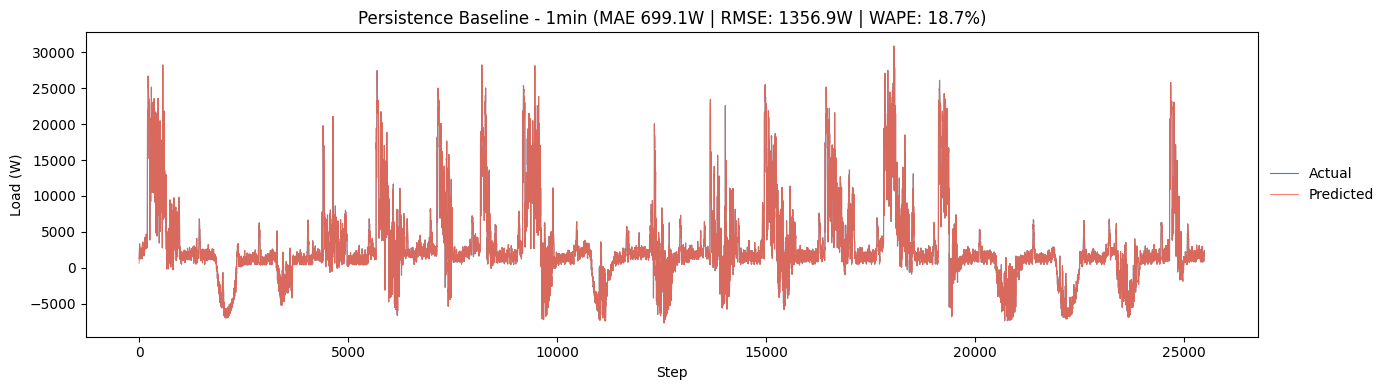

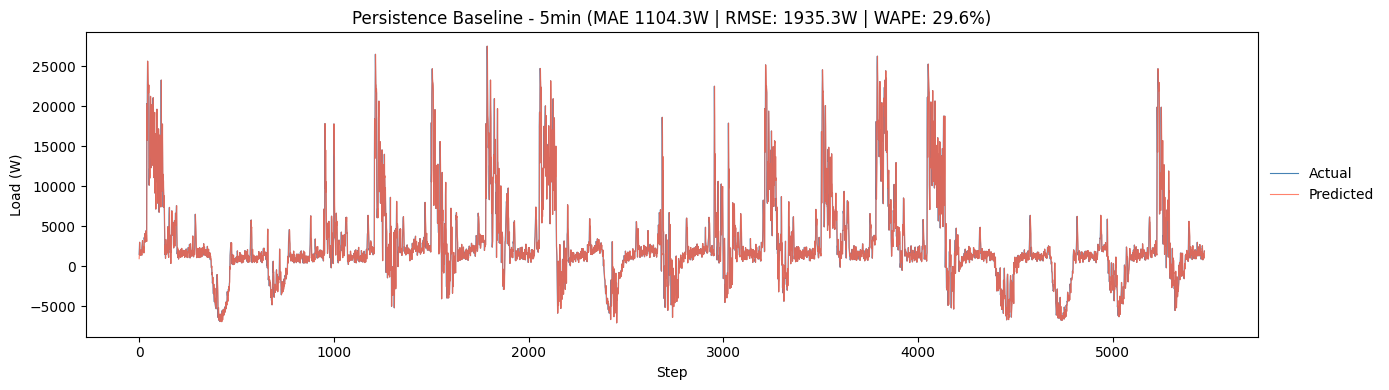

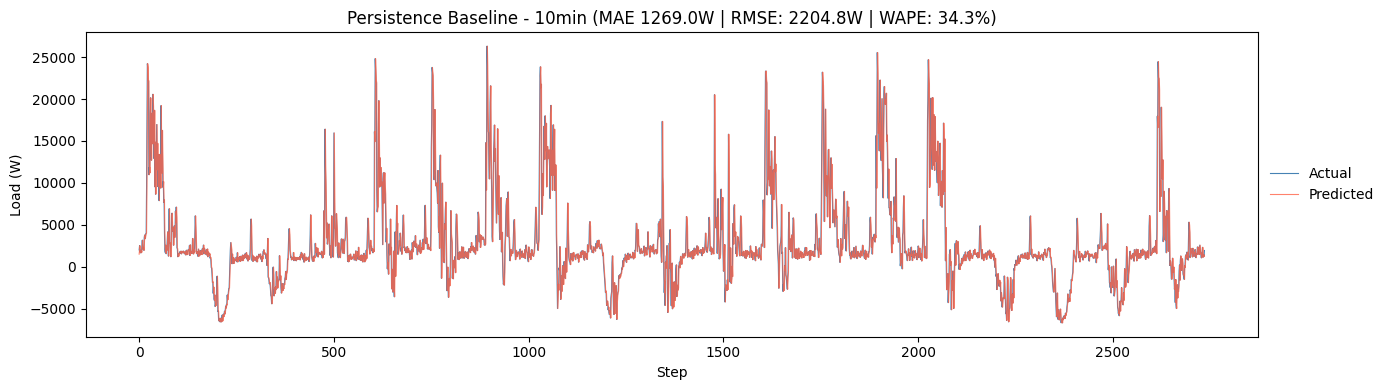

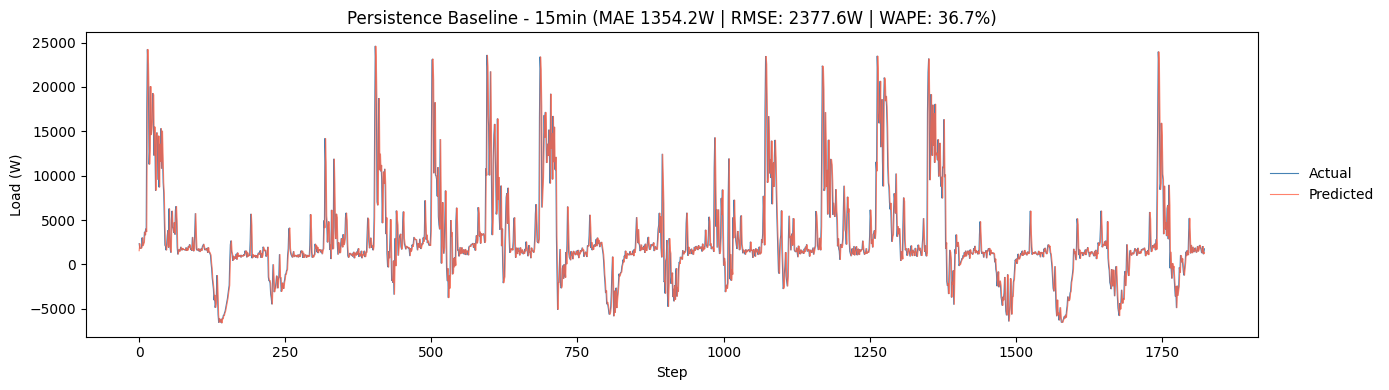

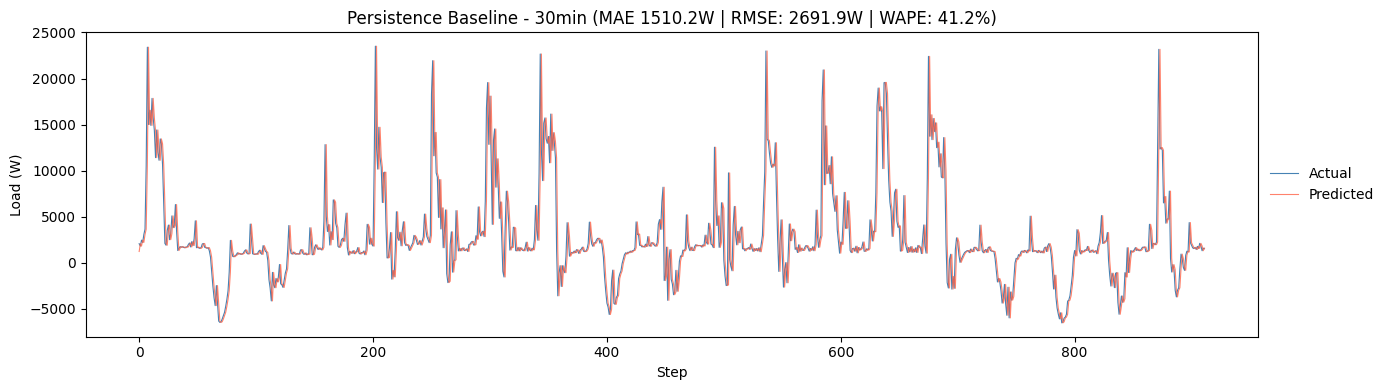

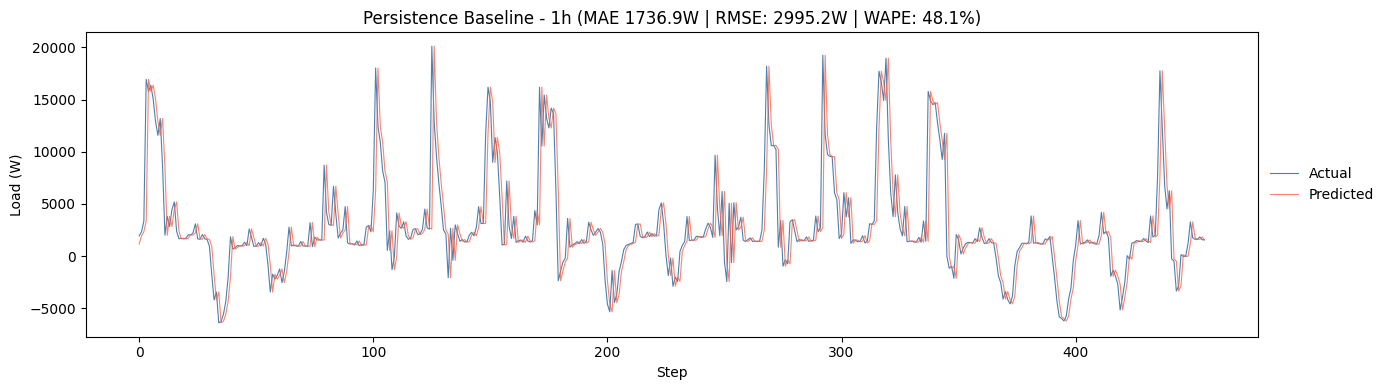

In [213]:
plot_true_vs_pred_by_resolution(models, "Persistence Baseline")

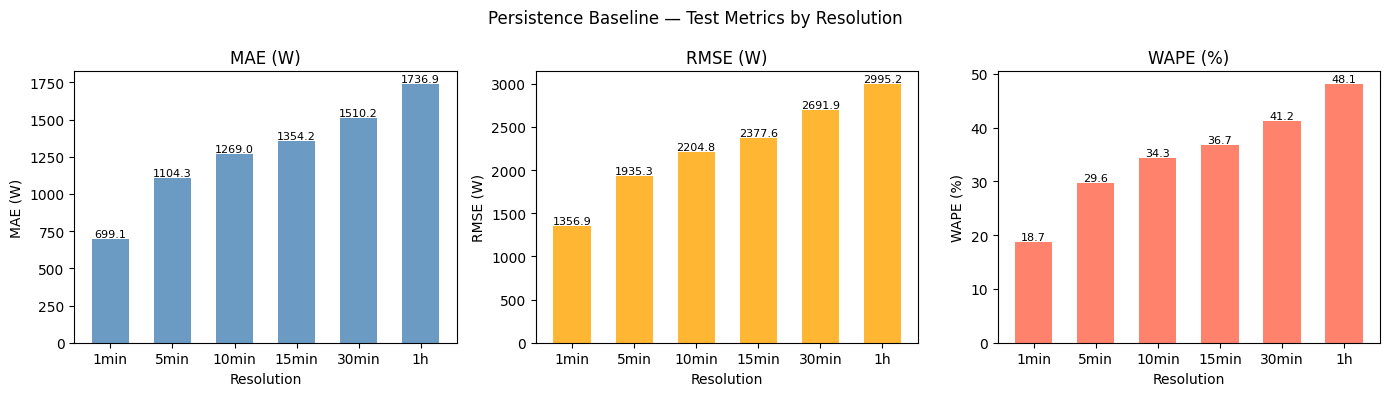

In [214]:
plot_metrics_by_resolution(models, "Persistence Baseline")

### 2.2: Model Training

#### 2.2.1 XG Boost

**XGB Feature Selection**

Find the best subset of features for XG Boost Models using **Recursive Feature Elimination**:

1. Train XGBoost on all features
2. Get feature importances
3. Sort features by importance
4. Try dropping bottom X% of features iteratively
5. Pick the threshold where val MAE stops improving

In [167]:
XGB_PARAMS = {
    "n_estimators":          500,
    "max_depth":             6,
    "learning_rate":         0.05,
    "subsample":             0.8,
    "colsample_bytree":      0.8,
    "random_state":          42,
    "n_jobs":                -1,
    "early_stopping_rounds": 20,
}

# ── FEATURE SETS ──────────────────────────────────────────────────────────────
def recursive_feature_elimination(df_train, df_val, params, res, step=0.1):
    """
    Iteratively remove least important features and track val MAE.
    step = fraction of remaining features to drop each iteration.
    """
    X_train, y_train = df_train.drop(columns=["load"]), df_train["load"]
    X_val,   y_val   = df_val.drop(columns=["load"]),   df_val["load"]

    current_features = list(X_train.columns)
    results = []

    print(f"  Starting with {len(current_features)} features")

    while len(current_features) >= 5:
        # Train on current features
        model = XGBRegressor(**params)
        model.fit(
            X_train[current_features], y_train,
            eval_set=[(X_val[current_features], y_val)],
            verbose=False
        )

        # Evaluate
        val_pred = pd.Series(model.predict(X_val[current_features]), index=X_val.index)
        mae  = mean_absolute_error(y_val.reset_index(drop=True), val_pred.reset_index(drop=True))
        rmse = mean_squared_error(y_val.reset_index(drop=True),  val_pred.reset_index(drop=True)) ** 0.5
        wape = (abs(y_val.reset_index(drop=True) - val_pred.reset_index(drop=True)).sum() / abs(y_val.reset_index(drop=True)).sum()) * 100

        results.append({
            "n_features": len(current_features),
            "features":   current_features.copy(),
            "model":      model,
            "mae":        mae,
            "rmse":       rmse,
            "wape":       wape,
        })
        print(f"  Features: {len(current_features):3d} | MAE: {mae:.1f}W | RMSE: {rmse:.1f}W | WAPE: {wape:.1f}%")

        # Drop bottom X% least important features
        importance     = pd.Series(model.feature_importances_, index=current_features)
        n_drop         = max(1, int(len(current_features) * step))
        current_features = importance.nlargest(len(current_features) - n_drop).index.tolist()

    # Find best
    results_df   = pd.DataFrame([{k: v for k, v in r.items() if k != "model" and k != "features"} for r in results])
    best_idx     = results_df["mae"].idxmin()
    best_result  = results[best_idx]

    print(f"\n  ✓ Best: {best_result['n_features']} features | MAE: {best_result['mae']:.1f}W")

    return best_result["model"], best_result["features"], results_df


# ── RUN ───────────────────────────────────────────────────────────────────────
rfe_results = {}

for res, splits in dfs_preprocessed.items():
    print(f"\n── RFE {res} ──────────────────────────────")
    best_model, best_features, results_df = recursive_feature_elimination(
        splits["train"], splits["val"], XGB_PARAMS, res, step=0.1
    )
    rfe_results[res] = {
        "best_model":    best_model,
        "best_features": best_features,
        "results":       results_df
    }



── RFE 1min ──────────────────────────────
  Starting with 72 features
  Features:  72 | MAE: 611.7W | RMSE: 1092.4W | WAPE: 18.2%
  Features:  65 | MAE: 610.4W | RMSE: 1090.2W | WAPE: 18.1%
  Features:  59 | MAE: 613.9W | RMSE: 1094.7W | WAPE: 18.2%
  Features:  54 | MAE: 612.9W | RMSE: 1094.4W | WAPE: 18.2%
  Features:  49 | MAE: 611.6W | RMSE: 1091.7W | WAPE: 18.2%
  Features:  45 | MAE: 613.8W | RMSE: 1096.1W | WAPE: 18.2%
  Features:  41 | MAE: 615.1W | RMSE: 1095.0W | WAPE: 18.3%
  Features:  37 | MAE: 612.9W | RMSE: 1094.4W | WAPE: 18.2%
  Features:  34 | MAE: 617.8W | RMSE: 1098.4W | WAPE: 18.3%
  Features:  31 | MAE: 616.4W | RMSE: 1097.0W | WAPE: 18.3%
  Features:  28 | MAE: 616.5W | RMSE: 1099.0W | WAPE: 18.3%
  Features:  26 | MAE: 614.5W | RMSE: 1098.9W | WAPE: 18.2%
  Features:  24 | MAE: 615.4W | RMSE: 1099.9W | WAPE: 18.3%
  Features:  22 | MAE: 618.5W | RMSE: 1102.6W | WAPE: 18.4%
  Features:  20 | MAE: 617.7W | RMSE: 1103.0W | WAPE: 18.3%
  Features:  18 | MAE: 615.0

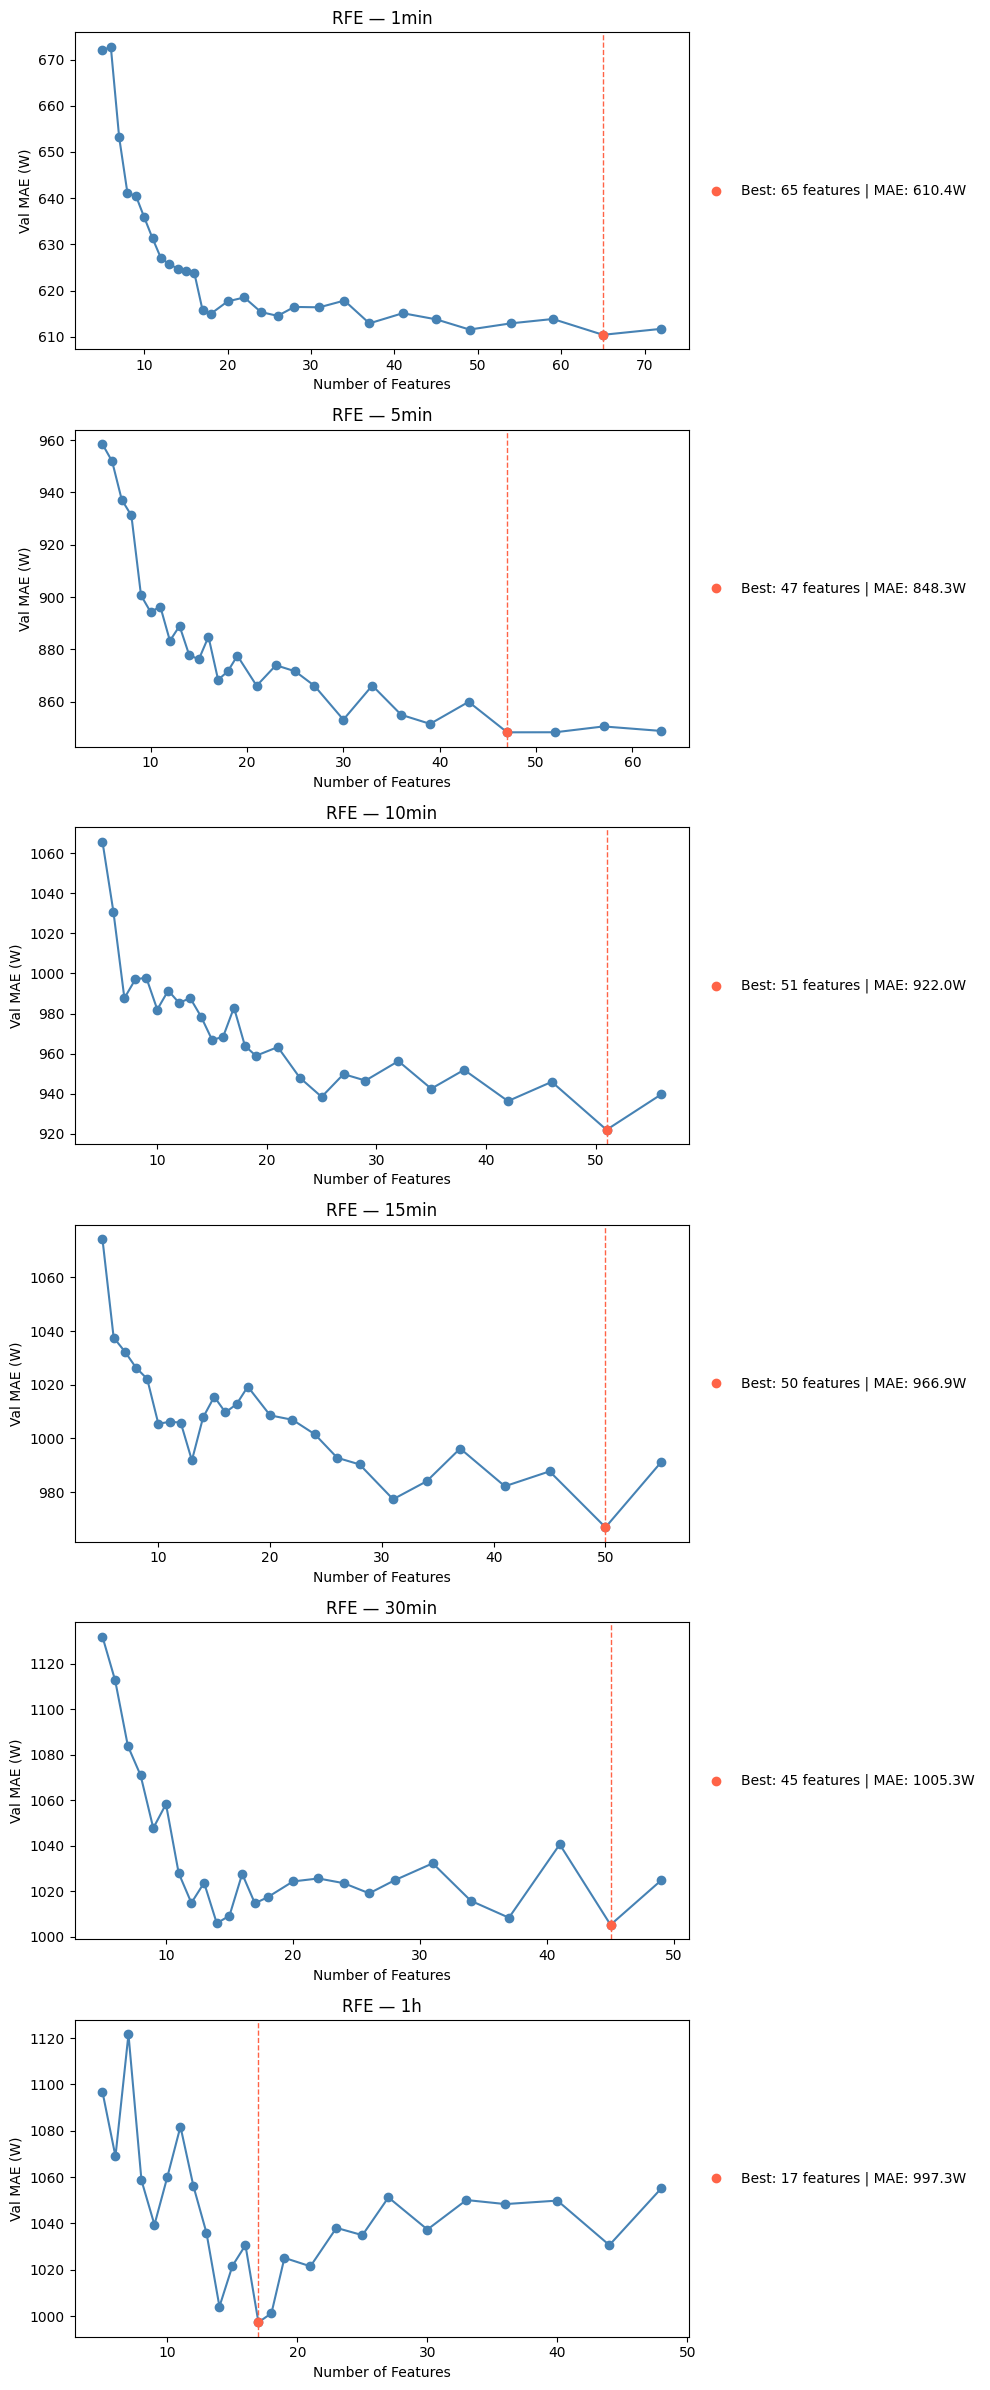

In [168]:
def plot_rfe_results(rfe_results: dict):
    """Plot MAE vs number of features for each resolution."""
    n_res = len(rfe_results)
    fig, axes = plt.subplots(n_res, 1, figsize=(10, 4 * n_res), sharex=False)
    if n_res == 1:
        axes = [axes]

    for ax, (res, data) in zip(axes, rfe_results.items()):
        df = data["results"]
        ax.plot(df["n_features"], df["mae"], marker="o", color="steelblue", linewidth=1.5)
        best = df.loc[df["mae"].idxmin()]
        ax.axvline(best["n_features"], color="tomato", linestyle="--", linewidth=1)
        ax.scatter(best["n_features"], best["mae"], color="tomato", zorder=5,
                   label=f"Best: {int(best['n_features'])} features | MAE: {best['mae']:.1f}W")
        ax.set_title(f"RFE — {res}")
        ax.set_xlabel("Number of Features")
        ax.set_ylabel("Val MAE (W)")
        ax.legend(loc="center left", bbox_to_anchor=(1, 0.5), frameon=False)

    plt.tight_layout()
    plt.show()


plot_rfe_results(rfe_results)

**XGB Hyperparameter Tuning**

After selecting the best feature set via RFE, we tune XGBoost hyperparameters using **grid search** on the validation set.

1. Define a search space of key hyperparameters
2. Train a model for each combination
3. Evaluate each on the validation set using MAE
4. Select the combination with the lowest validation MAE
5. Evaluate the best model on the test set

**Search Space:**

| Parameter | Values | Description |
|-----------|--------|-------------|
| `max_depth` | 3, 6 | Controls tree depth — higher = more complex |
| `learning_rate` | 0.05, 0.1 | Step size for each boosting round |
| `subsample` | 0.8, 1.0 | Fraction of training rows used per tree |

**Fixed Parameters:**

| Parameter | Value | Description |
|-----------|-------|-------------|
| `n_estimators` | 300 | Max number of trees |
| `colsample_bytree` | 0.8 | Fraction of features used per tree |
| `early_stopping_rounds` | 20 | Stop if val loss doesn't improve for 20 rounds |

Total combinations: **2 × 2 × 2 = 8 per resolution**

In [169]:
from itertools import product

# ── SEARCH SPACE ──────────────────────────────────────────────────────────────
XGB_SEARCH = {
    "max_depth":     [3, 6],
    "learning_rate": [0.05, 0.1],
    "subsample":     [0.8, 1.0],
}

XGB_FIXED = {
    "n_estimators":          300,
    "colsample_bytree":      0.8,
    "random_state":          42,
    "n_jobs":                -1,
    "early_stopping_rounds": 20,
}
# ─────────────────────────────────────────────────────────────────────────────
# 2 x 2 x 2 = 8 combinations per resolution — fast and meaningful


def xgb_grid_search(df_train, df_val, search_space, fixed_params, res):
    """Grid search over XGBoost params using val MAE as selection criterion."""
    X_train, y_train = df_train.drop(columns=["load"]), df_train["load"]
    X_val,   y_val   = df_val.drop(columns=["load"]),   df_val["load"]

    keys      = list(search_space.keys())
    values    = list(search_space.values())
    combos    = list(product(*values))
    best_mae  = float("inf")
    best_params = None
    best_model  = None
    results     = []

    print(f"  Running {len(combos)} combinations...")

    for i, combo in enumerate(combos, 1):
        params = dict(zip(keys, combo)) | fixed_params
        model  = XGBRegressor(**params)
        model.fit(
            X_train, y_train,
            eval_set=[(X_val, y_val)],
            verbose=False
        )

        val_pred = pd.Series(model.predict(X_val), index=X_val.index)
        mae      = mean_absolute_error(y_val.reset_index(drop=True), val_pred.reset_index(drop=True))
        results.append({"mae": mae, **dict(zip(keys, combo))})
        print(f"  [{i}/{len(combos)}] depth={params['max_depth']} lr={params['learning_rate']} subsample={params['subsample']} → MAE: {mae:.1f}W")

        if mae < best_mae:
            best_mae    = mae
            best_params = params
            best_model  = model

    results_df = pd.DataFrame(results).sort_values("mae").reset_index(drop=True)
    print(f"\n  ✓ Best VAL MAE: {best_mae:.1f}W")
    print(f"  ✓ Best params: max_depth={best_params['max_depth']} | lr={best_params['learning_rate']} | subsample={best_params['subsample']}")
    return best_model, best_params, results_df


# ── RUN ───────────────────────────────────────────────────────────────────────
xgb_models = {}

for res, splits in dfs_preprocessed.items():
    df_train = splits["train"]
    df_val   = splits["val"]
    df_test  = splits["test"]

    print(f"\n── XGBoost {res} ──────────────────────────────")

    # Use best features from RFE
    best_features = rfe_results[res]["best_features"]
    print(f"  Using {len(best_features)} features from RFE")

    # Filter to best features
    df_train_rfe = df_train[best_features + ["load"]]
    df_val_rfe   = df_val[best_features + ["load"]]
    df_test_rfe  = df_test[best_features + ["load"]]

    # Grid search on best features
    best_model, best_params, search_results = xgb_grid_search(
        df_train_rfe, df_val_rfe, XGB_SEARCH, XGB_FIXED, res
    )

    # Evaluate on test
    X_test, y_test = df_test_rfe.drop(columns=["load"]), df_test_rfe["load"]
    test_pred      = pd.Series(best_model.predict(X_test), index=X_test.index)
    print(f"\n  Test:")
    test_metrics   = evaluate(y_test, test_pred)

    xgb_models[res] = {
        "model":        best_model,
        "best_params":  best_params,
        "best_features": best_features,
        "search":       search_results,
        "test": {
            "pred":    test_pred,
            "true":    y_test,
            "metrics": test_metrics
        }
    }

print("\n✓ XGBoost tuning complete")


── XGBoost 1min ──────────────────────────────
  Using 65 features from RFE
  Running 8 combinations...
  [1/8] depth=3 lr=0.05 subsample=0.8 → MAE: 649.6W
  [2/8] depth=3 lr=0.05 subsample=1.0 → MAE: 649.9W
  [3/8] depth=3 lr=0.1 subsample=0.8 → MAE: 639.8W
  [4/8] depth=3 lr=0.1 subsample=1.0 → MAE: 636.0W
  [5/8] depth=6 lr=0.05 subsample=0.8 → MAE: 611.4W
  [6/8] depth=6 lr=0.05 subsample=1.0 → MAE: 613.0W
  [7/8] depth=6 lr=0.1 subsample=0.8 → MAE: 618.9W
  [8/8] depth=6 lr=0.1 subsample=1.0 → MAE: 616.5W

  ✓ Best VAL MAE: 611.4W
  ✓ Best params: max_depth=6 | lr=0.05 | subsample=0.8

  Test:
MAE: 614.3W | RMSE: 1117.0W | WAPE: 16.5%

── XGBoost 5min ──────────────────────────────
  Using 47 features from RFE
  Running 8 combinations...
  [1/8] depth=3 lr=0.05 subsample=0.8 → MAE: 872.8W
  [2/8] depth=3 lr=0.05 subsample=1.0 → MAE: 871.4W
  [3/8] depth=3 lr=0.1 subsample=0.8 → MAE: 865.8W
  [4/8] depth=3 lr=0.1 subsample=1.0 → MAE: 856.9W
  [5/8] depth=6 lr=0.05 subsample=0.8 → 

**XGB Best Model**

In [217]:
models["XGBoost"] = xgb_models

for res, data in models["XGBoost"].items():

    print(f"\n── XGBoost {res} ──────────────────────────────")
    print(f"  Best params: {data['best_params']}")
    print(f"  Best features ({len(data['best_features'])} features): {data['best_features']}")
    print(f"  Test MAE: {data['test']['metrics']['mae']:.1f}W")

print(" ")
save_model("XGBoost", xgb_models)


── XGBoost 1min ──────────────────────────────
  Best params: {'max_depth': 6, 'learning_rate': 0.05, 'subsample': 0.8, 'n_estimators': 300, 'colsample_bytree': 0.8, 'random_state': 42, 'n_jobs': -1, 'early_stopping_rounds': 20}
  Best features (65 features): ['roll_max_5min', 'lag_1min', 'roll_mean_5min', 'delta_6hr', 'is_negative', 'is_high_outlier', 'roll_min_5min', 'lag_2min', 'is_low_outlier', 'hour', 'roll_max_15min', 'lag_3min', 'hour_sin', 'roll_mean_15min', 'roll_min_15min', 'slope_5min', 'solar_angle', 'dayofweek', 'roll_mean_30min', 'roll_std_1hr', 'hour_cos', 'delta_5min', 'lag_6hr', 'roll_mean_1hr', 'roll_max_30min', 'month_cos', 'roll_std_6hr', 'roll_max_3hr', 'roll_mean_3hr', 'is_daylight', 'roll_max_6hr', 'roll_max_1hr', 'lag_1week', 'roll_mean_6hr', 'lag_5min', 'dow_sin', 'roll_std_3hr', 'roll_std_30min', 'dow_cos', 'delta_1hr', 'roll_min_30min', 'roll_min_1hr', 'delta_3hr', 'roll_std_5min', 'roll_min_6hr', 'delta_30min', 'roll_std_15min', 'is_weekend', 'roll_min_3hr'

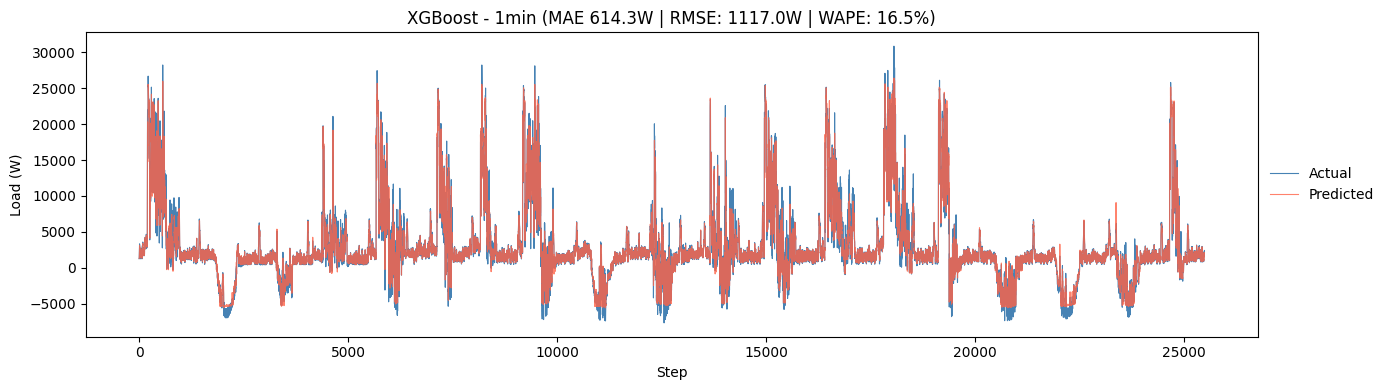

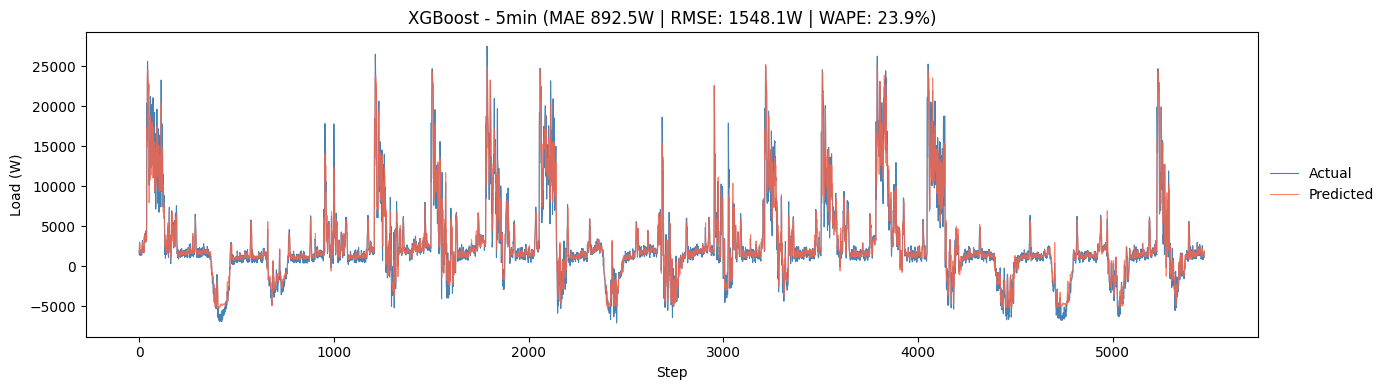

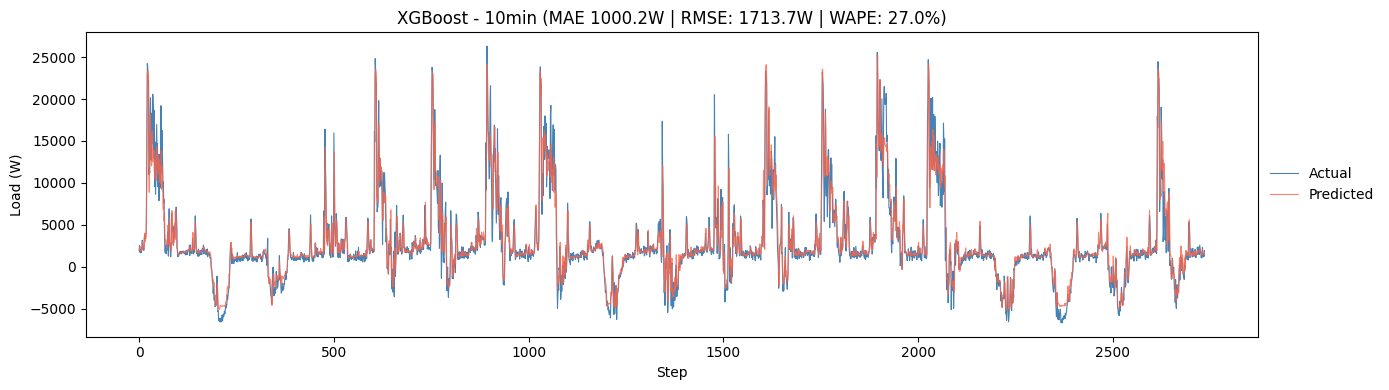

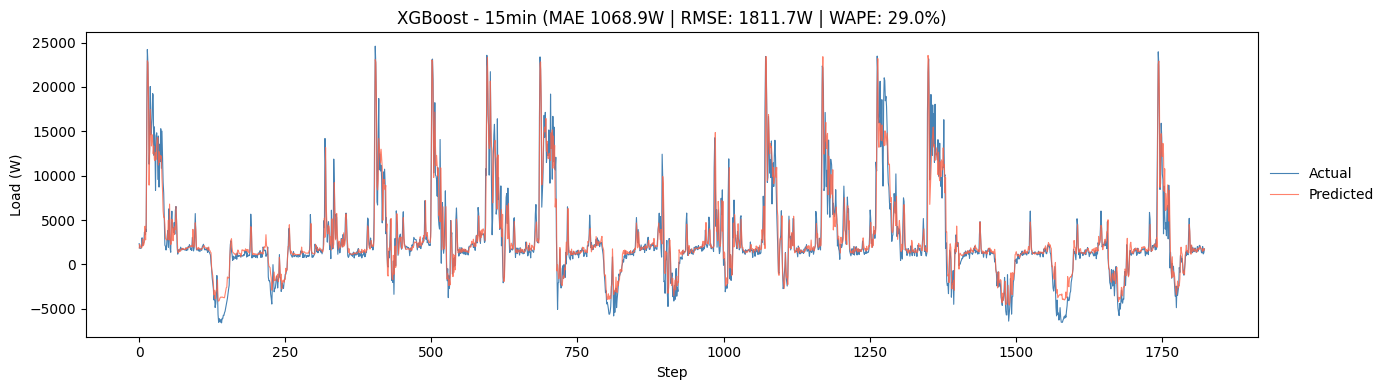

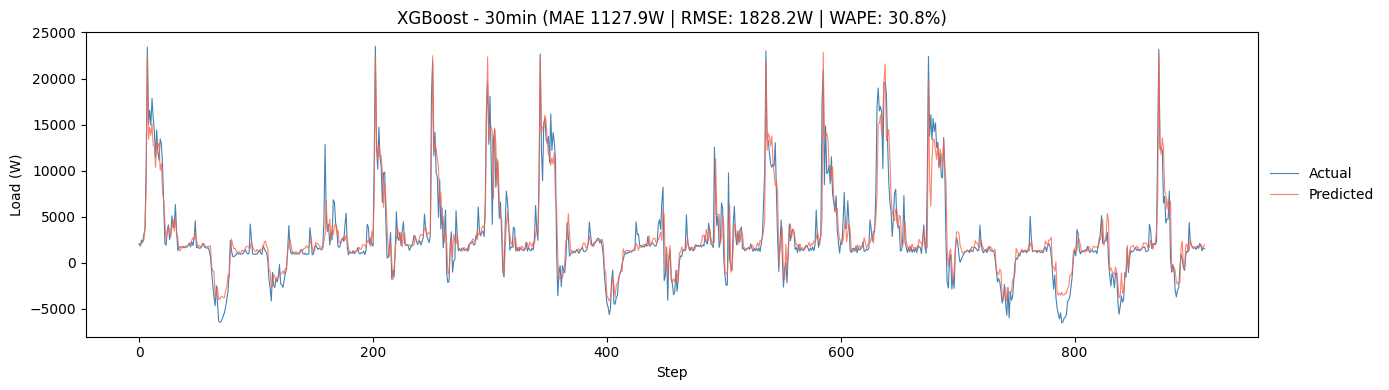

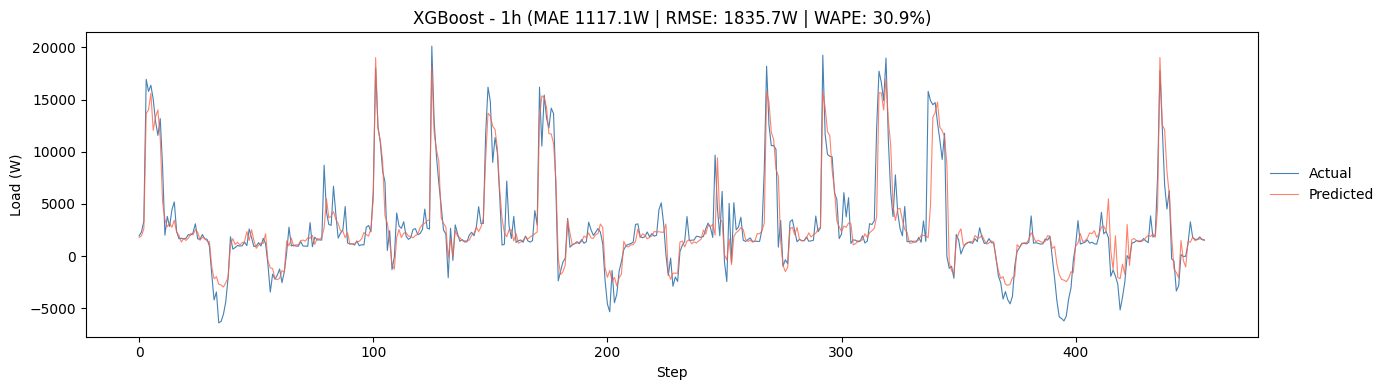

In [218]:
plot_true_vs_pred_by_resolution(models, "XGBoost")

In [ ]:
plot_metrics_by_resolution(models, "XGBoost")


── XGBoost Feature Importance (1min) ──────────────────────────────
lag_1min           0.570047
roll_max_5min      0.131933
is_high_outlier    0.061136
is_negative        0.059077
roll_mean_5min     0.044454
delta_3hr          0.012294
delta_6hr          0.010585
roll_min_5min      0.010358
lag_2min           0.005832
hour               0.005011
dtype: float32


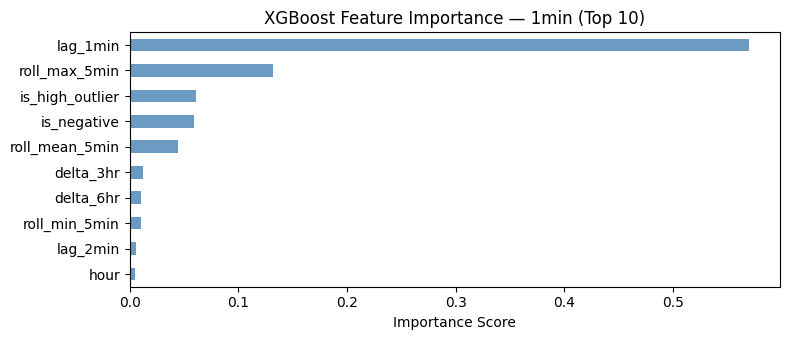


── XGBoost Feature Importance (5min) ──────────────────────────────
lag_5min           0.406105
roll_max_15min     0.232369
is_negative        0.075740
is_high_outlier    0.070773
delta_6hr          0.016357
hour_sin           0.013446
is_low_outlier     0.010560
roll_max_30min     0.008879
hour_cos           0.007810
solar_angle        0.007283
dtype: float32


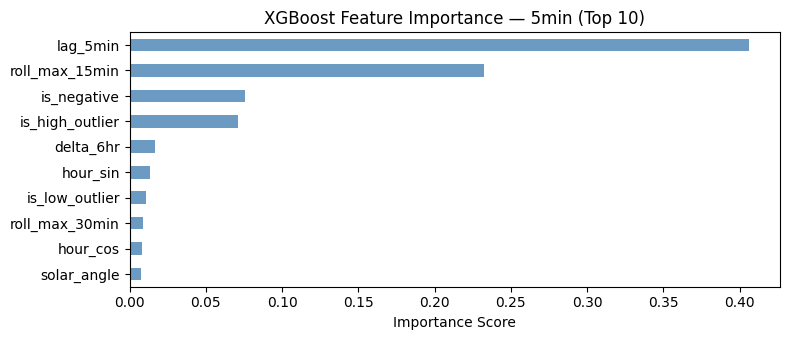


── XGBoost Feature Importance (10min) ──────────────────────────────
roll_max_30min     0.246264
lag_10min          0.161675
roll_mean_30min    0.118015
is_high_outlier    0.104675
is_negative        0.073171
delta_6hr          0.026638
slope_30min        0.020228
hour               0.014817
hour_cos           0.012829
day_class          0.012096
dtype: float32


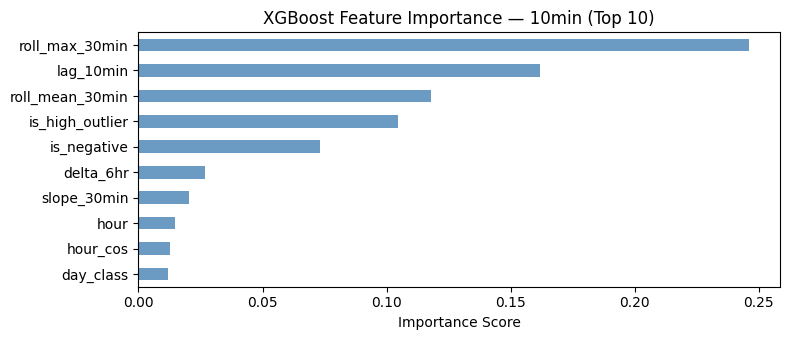


── XGBoost Feature Importance (15min) ──────────────────────────────
lag_15min          0.221614
delta_6hr          0.158111
is_high_outlier    0.122462
is_negative        0.068684
roll_min_30min     0.040409
roll_max_30min     0.038269
hour_sin           0.030131
hour               0.018445
lag_1week          0.016040
dow_sin            0.015975
dtype: float32


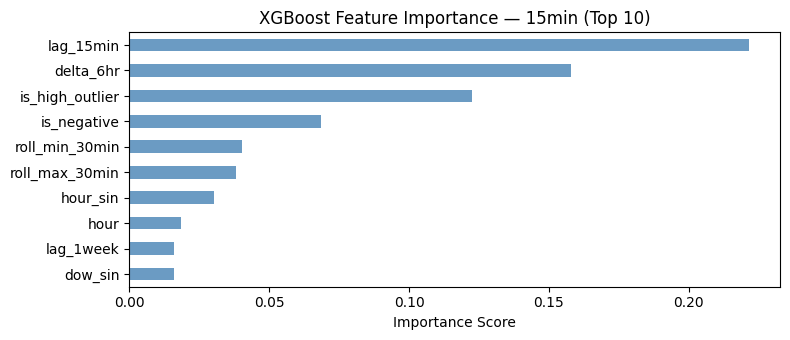


── XGBoost Feature Importance (30min) ──────────────────────────────
lag_30min          0.285119
is_high_outlier    0.143145
is_negative        0.053147
is_daylight        0.041333
hour_sin           0.039053
hour               0.036019
lag_1week          0.030100
roll_max_1hr       0.020003
dow_sin            0.019319
solar_angle        0.015424
dtype: float32


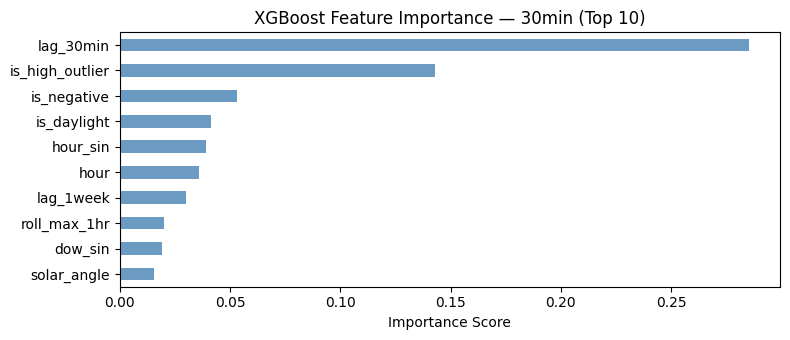


── XGBoost Feature Importance (1h) ──────────────────────────────
lag_1hr            0.329155
lag_1week          0.142024
is_high_outlier    0.104744
is_negative        0.057876
hour_sin           0.057350
dayofyear          0.048740
delta_12hr         0.048084
doy_cos            0.038530
hour               0.029192
roll_min_3hr       0.029115
dtype: float32


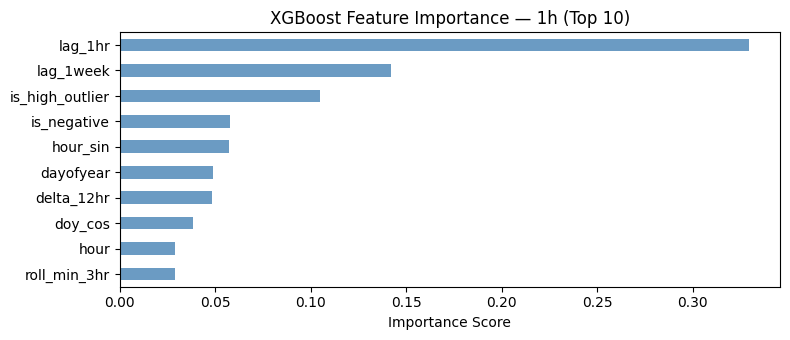

In [219]:
plot_xgboost_feature_importance(models["XGBoost"], top_n=10)

#### 2.2.2 AutoML (FLAML)

**AutoML** (Automated Machine Learning) automates the process of selecting, training, and tuning machine learning models. Rather than manually choosing a model and tuning hyperparameters, AutoML searches across multiple model types and configurations to find the best performing solution automatically.

**What AutoML automates:**
- Model selection (XGBoost, LightGBM, Random Forest, Neural Nets, etc.)
- Hyperparameter tuning
- Feature preprocessing
- Ensemble creation

---

For this project we use **FLAML (Fast and Lightweight AutoML)**, developed by Microsoft Research. FLAML is designed to find good models quickly with minimal computational cost, making it well suited for time series regression tasks.

**References:**
- FLAML Documentation: https://microsoft.github.io/FLAML/
- GitHub: https://github.com/microsoft/FLAML

---


FLAML is given a fixed **time budget per resolution** to search for the best model and configuration. It uses the combined train and validation set with internal cross-validation to evaluate candidates.

| Setting | Value | Description |
|---------|-------|-------------|
| `time_budget` | 120s | Search time per resolution |
| `metric` | `mae` | Optimization target |
| `task` | `regression` | Problem type |


In [181]:
# ── CONFIG ────────────────────────────────────────────────────────────────────
FLAML_SETTINGS = {
    "time_budget":   120,
    "metric":        "mae",
    "task":          "regression",
    "log_file_name": "",
    "verbose":       1,
}

logging.getLogger("flaml").setLevel(logging.WARNING)
# ─────────────────────────────────────────────────────────────────────────────

flaml_models = {}

for res, splits in dfs_preprocessed.items():
    df_train = splits["train"]
    df_val   = splits["val"]
    df_test  = splits["test"]

    print(f"\n── AutoML (FLAML) {res} ──────────────────────────────")

    # X / y split
    X_train, y_train = df_train.drop(columns=["load"]), df_train["load"]
    X_val,   y_val   = df_val.drop(columns=["load"]),   df_val["load"]
    X_test,  y_test  = df_test.drop(columns=["load"]),  df_test["load"]

    # Combine train + val
    X_trainval = pd.concat([X_train, X_val])
    y_trainval = pd.concat([y_train, y_val])
    print(f"  Train+Val: {X_trainval.shape} | Test: {X_test.shape}")
    print(f"  Features:  {X_trainval.shape[1]}")
    print(f"  Budget:    {FLAML_SETTINGS['time_budget']}s")

    # Train
    print(f"  Training...")
    start = time.time()
    automl = AutoML()
    automl.fit(X_trainval, y_trainval, **FLAML_SETTINGS)
    elapsed = time.time() - start

    print(f"  ✓ Completed in {elapsed:.1f}s")
    print(f"  ✓ Best model:  {automl.best_estimator}")
    print(f"  ✓ Best config: {automl.best_config}")

    # Evaluate on test
    test_pred    = pd.Series(automl.predict(X_test), index=X_test.index)
    print(f"\n  Test:")
    test_metrics = evaluate(y_test, test_pred)

    flaml_models[res] = {
        "model":          automl,
        "best_estimator": automl.best_estimator,
        "best_config":    automl.best_config,
        "elapsed":        elapsed,
        "test": {
            "pred":    test_pred,
            "true":    y_test,
            "metrics": test_metrics
        }
    }


print("\n✓ AutoML training complete")

print("\nSummary:")
for res, data in flaml_models.items():
    m = data["test"]["metrics"]
    print(f"  {res:6s} | {data['best_estimator']:15s} | MAE: {m['mae']:.1f}W | RMSE: {m['rmse']:.1f}W | WAPE: {m['wape']:.1f}% | Time: {data['elapsed']:.1f}s")



── AutoML (FLAML) 1min ──────────────────────────────
  Train+Val: (147451, 72) | Test: (25497, 72)
  Features:  72
  Budget:    120s
  Training...


INFO:flaml.tune.searcher.blendsearch:No low-cost partial config given to the search algorithm. For cost-frugal search, consider providing low-cost values for cost-related hps via 'low_cost_partial_config'. More info can be found at https://microsoft.github.io/FLAML/docs/FAQ#about-low_cost_partial_config-in-tune


  ✓ Completed in 141.1s
  ✓ Best model:  extra_tree
  ✓ Best config: {'n_estimators': 15, 'max_features': np.float64(0.6701678765297618), 'max_leaves': 495}

  Test:
MAE: 623.6W | RMSE: 1114.6W | WAPE: 16.7%

── AutoML (FLAML) 5min ──────────────────────────────
  Train+Val: (30374, 63) | Test: (5472, 63)
  Features:  63
  Budget:    120s
  Training...


INFO:flaml.tune.searcher.blendsearch:No low-cost partial config given to the search algorithm. For cost-frugal search, consider providing low-cost values for cost-related hps via 'low_cost_partial_config'. More info can be found at https://microsoft.github.io/FLAML/docs/FAQ#about-low_cost_partial_config-in-tune


  ✓ Completed in 125.8s
  ✓ Best model:  extra_tree
  ✓ Best config: {'n_estimators': 37, 'max_features': np.float64(0.5054362643933804), 'max_leaves': 570}

  Test:
MAE: 884.1W | RMSE: 1518.1W | WAPE: 23.7%

── AutoML (FLAML) 10min ──────────────────────────────
  Train+Val: (15226, 56) | Test: (2736, 56)
  Features:  56
  Budget:    120s
  Training...


...

  ✓ Completed in 126.6s
  ✓ Best model:  extra_tree
  ✓ Best config: {'n_estimators': 85, 'max_features': np.float64(0.4977274222126191), 'max_leaves': 624}

  Test:
MAE: 979.0W | RMSE: 1690.6W | WAPE: 26.5%

── AutoML (FLAML) 30min ──────────────────────────────
  Train+Val: (5090, 49) | Test: (912, 49)
  Features:  49
  Budget:    120s
  Training...


INFO:flaml.tune.searcher.blendsearch:No low-cost partial config given to the search algorithm. For cost-frugal search, consider providing low-cost values for cost-related hps via 'low_cost_partial_config'. More info can be found at https://microsoft.github.io/FLAML/docs/FAQ#about-low_cost_partial_config-in-tune


  ✓ Completed in 120.8s
  ✓ Best model:  extra_tree
  ✓ Best config: {'n_estimators': 34, 'max_features': np.float64(0.5609306919811571), 'max_leaves': 703}

  Test:
MAE: 1032.8W | RMSE: 1699.5W | WAPE: 28.2%

── AutoML (FLAML) 1h ──────────────────────────────
  Train+Val: (2546, 48) | Test: (456, 48)
  Features:  48
  Budget:    120s
  Training...


INFO:flaml.tune.searcher.blendsearch:No low-cost partial config given to the search algorithm. For cost-frugal search, consider providing low-cost values for cost-related hps via 'low_cost_partial_config'. More info can be found at https://microsoft.github.io/FLAML/docs/FAQ#about-low_cost_partial_config-in-tune


  ✓ Completed in 121.7s
  ✓ Best model:  extra_tree
  ✓ Best config: {'n_estimators': 119, 'max_features': np.float64(0.5207865142222511), 'max_leaves': 1272}

  Test:
MAE: 986.3W | RMSE: 1641.4W | WAPE: 27.3%

✓ AutoML training complete

Summary:
  1min   | extra_tree      | MAE: 623.6W | RMSE: 1114.6W | WAPE: 16.7% | Time: 141.1s
  5min   | extra_tree      | MAE: 884.1W | RMSE: 1518.1W | WAPE: 23.7% | Time: 125.8s
  10min  | extra_tree      | MAE: 962.3W | RMSE: 1650.9W | WAPE: 26.0% | Time: 124.1s
  15min  | extra_tree      | MAE: 979.0W | RMSE: 1690.6W | WAPE: 26.5% | Time: 126.6s
  30min  | extra_tree      | MAE: 1032.8W | RMSE: 1699.5W | WAPE: 28.2% | Time: 120.8s
  1h     | extra_tree      | MAE: 986.3W | RMSE: 1641.4W | WAPE: 27.3% | Time: 121.7s


In [222]:
# ── Save to models dict ───────────────────────────────────────────────────────
models["AutoML (FLAML)"] = flaml_models
save_model("AutoML (FLAML)", flaml_models)

✓ Saved AutoML (FLAML) in] → /content/drive/MyDrive/ElectricLoadForecast/AutoML (FLAML)/1min.joblib
✓ Saved AutoML (FLAML) in] → /content/drive/MyDrive/ElectricLoadForecast/AutoML (FLAML)/5min.joblib
✓ Saved AutoML (FLAML) in] → /content/drive/MyDrive/ElectricLoadForecast/AutoML (FLAML)/10min.joblib
✓ Saved AutoML (FLAML) in] → /content/drive/MyDrive/ElectricLoadForecast/AutoML (FLAML)/15min.joblib
✓ Saved AutoML (FLAML) in] → /content/drive/MyDrive/ElectricLoadForecast/AutoML (FLAML)/30min.joblib
✓ Saved AutoML (FLAML) [1h] → /content/drive/MyDrive/ElectricLoadForecast/AutoML (FLAML)/1h.joblib


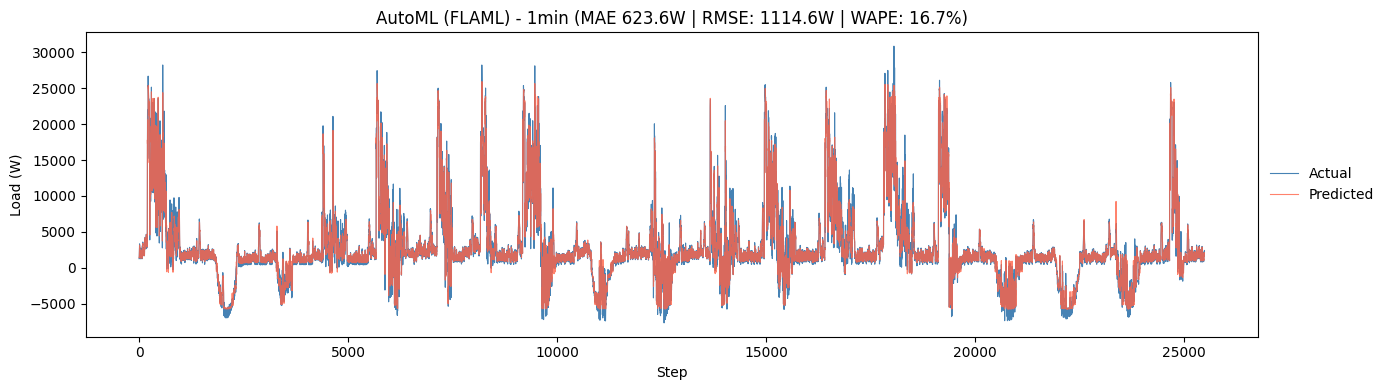

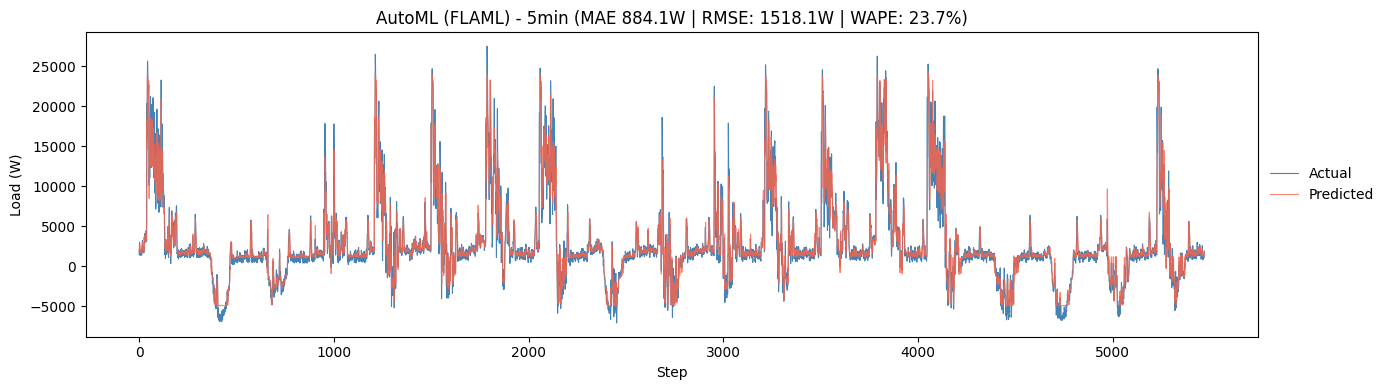

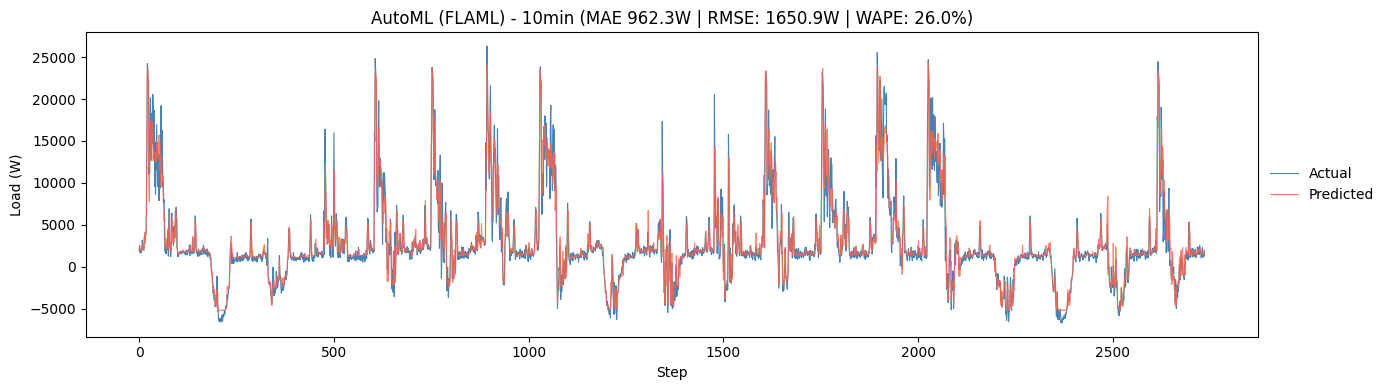

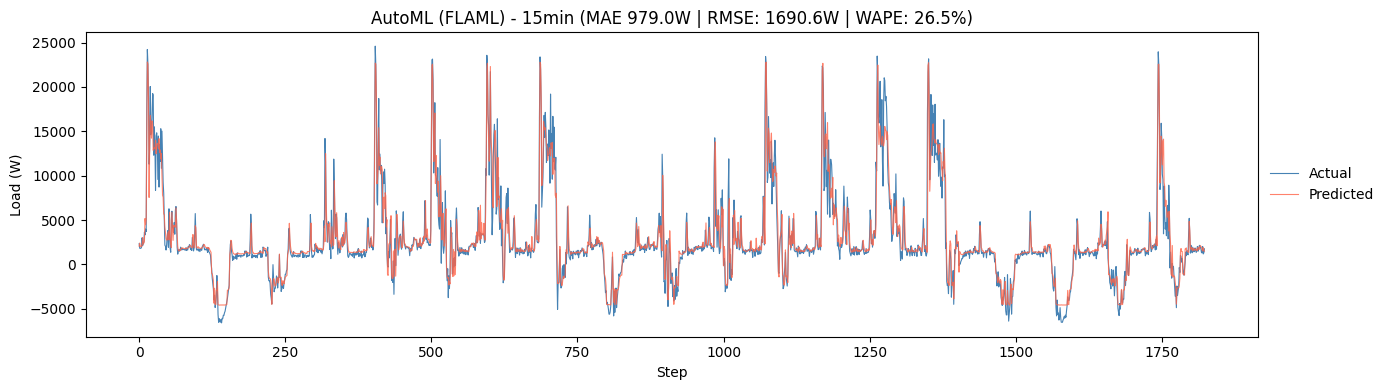

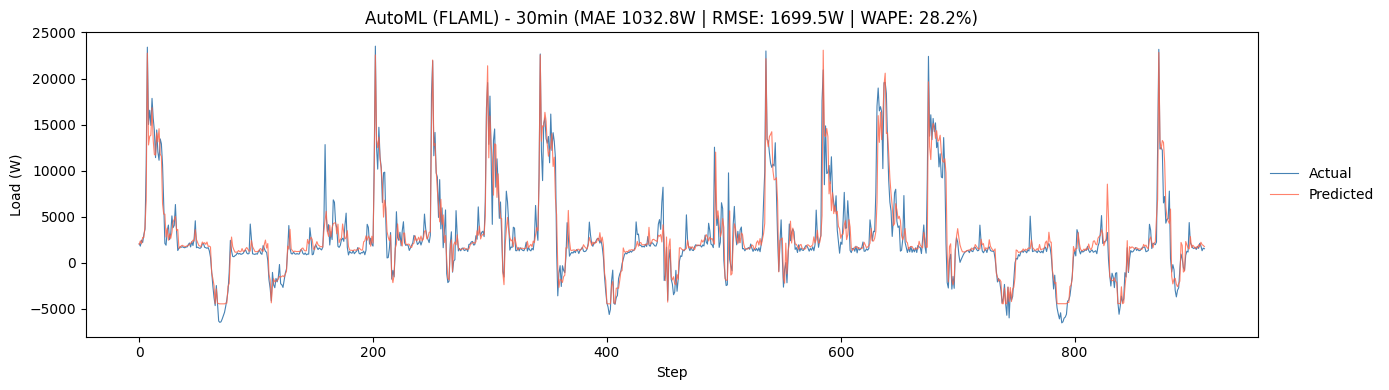

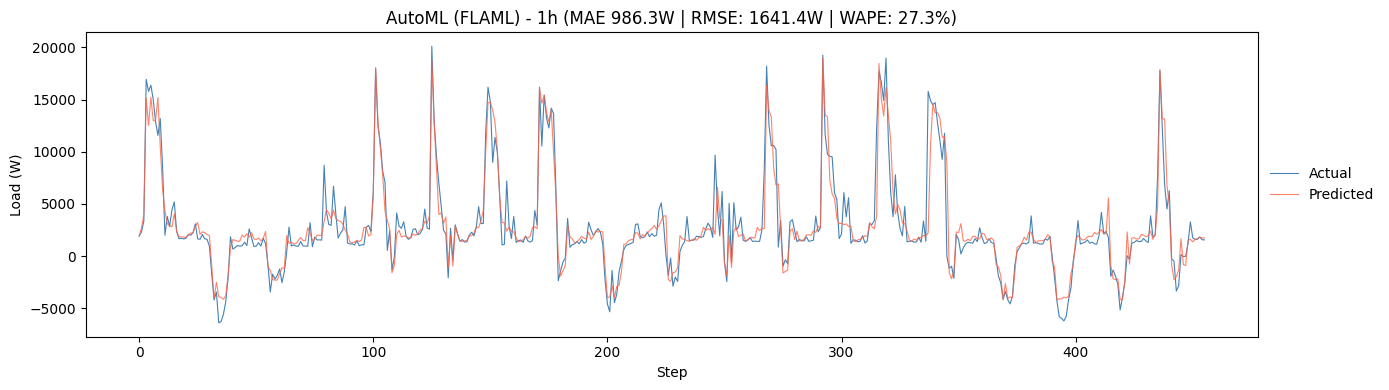

In [223]:
plot_true_vs_pred_by_resolution(models, "AutoML (FLAML)")

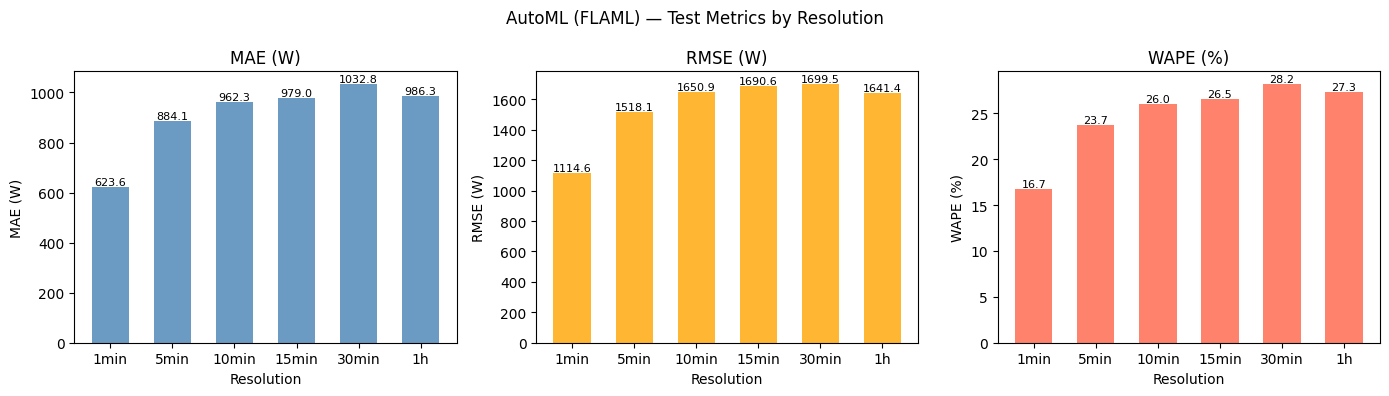

In [224]:
plot_metrics_by_resolution(models, "AutoML (FLAML)")

#### 2.2.3 Ridge Regression

Ridge Regression is a linear model that predicts load as a weighted sum of input features. It extends ordinary linear regression by adding an L2 regularization penalty to prevent overfitting — particularly useful when features are correlated (which is expected with lag and rolling features).

```
prediction = w1*lag_1 + w2*lag_5 + w3*hour_sin + ... + bias
```

**Why Ridge for load forecasting:**
- Fast to train and interpretable
- Handles correlated features (lag_1, lag_2, lag_3 are highly correlated) without breaking down
- Serves as a strong linear baseline to compare against nonlinear models

**Note:** Ridge requires feature scaling since it is sensitive to feature magnitudes. A `StandardScaler` is fit on the training set and applied to val and test.

---

**Hyperparameter Tuning**

The only hyperparameter is `alpha` — the regularization strength.

| `alpha` | Effect |
|---------|--------|
| Low (0.01) | Less regularization — closer to plain linear regression |
| High (100) | More regularization — coefficients shrunk toward zero |

The best `alpha` is selected by minimizing **validation MAE** across 5 candidate values: `0.01, 0.1, 1.0, 10.0, 100.0`.

In [199]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler

# ── CONFIG ────────────────────────────────────────────────────────────────────
RIDGE_SEARCH = {
    "alpha": [0.01, 0.1, 1.0, 10.0, 100.0]
}
# ─────────────────────────────────────────────────────────────────────────────

ridge_models = {}

for res, splits in dfs_preprocessed.items():
    df_train = splits["train"]
    df_val   = splits["val"]
    df_test  = splits["test"]

    print(f"\n── Ridge {res} ──────────────────────────────")

    # X / y split
    X_train, y_train = df_train.drop(columns=["load"]), df_train["load"]
    X_val,   y_val   = df_val.drop(columns=["load"]),   df_val["load"]
    X_test,  y_test  = df_test.drop(columns=["load"]),  df_test["load"]

    # Scale — Ridge requires scaling
    scaler  = StandardScaler()
    X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
    X_val_scaled   = pd.DataFrame(scaler.transform(X_val),       columns=X_val.columns)
    X_test_scaled  = pd.DataFrame(scaler.transform(X_test),      columns=X_test.columns)

    # Grid search over alpha
    print(f"  Running {len(RIDGE_SEARCH['alpha'])} alpha values...")
    best_mae   = float("inf")
    best_alpha = None
    best_model = None
    results    = []

    for alpha in RIDGE_SEARCH["alpha"]:
        model = Ridge(alpha=alpha)
        model.fit(X_train_scaled, y_train)

        val_pred = pd.Series(model.predict(X_val_scaled), index=X_val.index)
        mae      = mean_absolute_error(y_val.reset_index(drop=True), val_pred.reset_index(drop=True))
        rmse     = mean_squared_error(y_val.reset_index(drop=True),  val_pred.reset_index(drop=True)) ** 0.5
        wape     = (abs(y_val.reset_index(drop=True) - val_pred.reset_index(drop=True)).sum() / abs(y_val.reset_index(drop=True)).sum()) * 100

        results.append({"alpha": alpha, "mae": mae, "rmse": rmse, "wape": wape})
        print(f"  alpha={alpha:8.2f} → MAE: {mae:.1f}W | RMSE: {rmse:.1f}W | WAPE: {wape:.1f}%")

        if mae < best_mae:
            best_mae   = mae
            best_alpha = alpha
            best_model = model

    results_df = pd.DataFrame(results).sort_values("mae").reset_index(drop=True)
    print(f"\n  ✓ Best alpha: {best_alpha} | VAL MAE: {best_mae:.1f}W")

    # Evaluate on test
    test_pred    = pd.Series(best_model.predict(X_test_scaled), index=X_test.index)
    print(f"\n  Test:")
    test_metrics = evaluate(y_test, test_pred)

    ridge_models[res] = {
        "model":      best_model,
        "scaler":     scaler,
        "best_alpha": best_alpha,
        "search":     results_df,
        "test": {
            "pred":    test_pred,
            "true":    y_test,
            "metrics": test_metrics
        }
    }

print("\n✓ Ridge training complete")


── Ridge 1min ──────────────────────────────
  Running 5 alpha values...
  alpha=    0.01 → MAE: 727.4W | RMSE: 1243.9W | WAPE: 21.6%
  alpha=    0.10 → MAE: 727.4W | RMSE: 1243.9W | WAPE: 21.6%
  alpha=    1.00 → MAE: 727.3W | RMSE: 1243.9W | WAPE: 21.6%
  alpha=   10.00 → MAE: 726.3W | RMSE: 1243.7W | WAPE: 21.6%
  alpha=  100.00 → MAE: 723.3W | RMSE: 1243.3W | WAPE: 21.5%

  ✓ Best alpha: 100.0 | VAL MAE: 723.3W

  Test:
MAE: 709.8W | RMSE: 1261.1W | WAPE: 19.0%

── Ridge 5min ──────────────────────────────
  Running 5 alpha values...
  alpha=    0.01 → MAE: 976.2W | RMSE: 1636.1W | WAPE: 27.9%
  alpha=    0.10 → MAE: 976.3W | RMSE: 1636.1W | WAPE: 27.9%
  alpha=    1.00 → MAE: 976.6W | RMSE: 1636.0W | WAPE: 28.0%
  alpha=   10.00 → MAE: 978.1W | RMSE: 1636.2W | WAPE: 28.0%
  alpha=  100.00 → MAE: 975.7W | RMSE: 1636.6W | WAPE: 27.9%

  ✓ Best alpha: 100.0 | VAL MAE: 975.7W

  Test:
MAE: 1032.2W | RMSE: 1730.4W | WAPE: 27.7%

── Ridge 10min ──────────────────────────────
  Running 

In [226]:
# ── Save best models ───────────────────────────────────────────────────────
models["Ridge"] = ridge_models
save_model("Ridge", ridge_models)

✓ Saved Ridge in] → /content/drive/MyDrive/ElectricLoadForecast/Ridge/1min.joblib
✓ Saved Ridge in] → /content/drive/MyDrive/ElectricLoadForecast/Ridge/5min.joblib
✓ Saved Ridge in] → /content/drive/MyDrive/ElectricLoadForecast/Ridge/10min.joblib
✓ Saved Ridge in] → /content/drive/MyDrive/ElectricLoadForecast/Ridge/15min.joblib
✓ Saved Ridge in] → /content/drive/MyDrive/ElectricLoadForecast/Ridge/30min.joblib
✓ Saved Ridge [1h] → /content/drive/MyDrive/ElectricLoadForecast/Ridge/1h.joblib


#### 2.2.4 HGB

Histogram Gradient Boosting (HGB) is a tree-based ensemble model that builds trees sequentially, where each tree corrects the errors of the previous one. It uses histogram binning to speed up training, making it significantly faster than standard Gradient Boosting on large datasets.

**Why HGB for load forecasting:**
- Captures nonlinear load patterns (morning ramp-ups, day-type differences)
- Handles missing values natively — no imputation needed
- Fast training via histogram binning
- No feature scaling required

**Hyperparameter Tuning:**

| Parameter | Values | Description |
|-----------|--------|-------------|
| `max_depth` | 3, 6, 9 | Controls tree depth — higher = more complex |
| `learning_rate` | 0.05, 0.1 | Step size for each boosting round |
| `max_iter` | 300 | Max number of trees |

Best configuration selected by minimizing **validation MAE**.

In [201]:
from sklearn.ensemble import HistGradientBoostingRegressor

# ── CONFIG ────────────────────────────────────────────────────────────────────
HGB_SEARCH = {
    "max_depth":     [3, 6, 9],
    "learning_rate": [0.05, 0.1],
}

HGB_FIXED = {
    "max_iter":    300,
    "random_state": 42,
}
# 3 x 2 = 6 combinations per resolution
# ─────────────────────────────────────────────────────────────────────────────

hgb_models = {}

for res, splits in dfs_preprocessed.items():
    df_train = splits["train"]
    df_val   = splits["val"]
    df_test  = splits["test"]

    print(f"\n── HGB {res} ──────────────────────────────")

    X_train, y_train = df_train.drop(columns=["load"]), df_train["load"]
    X_val,   y_val   = df_val.drop(columns=["load"]),   df_val["load"]
    X_test,  y_test  = df_test.drop(columns=["load"]),  df_test["load"]

    # Grid search
    keys    = list(HGB_SEARCH.keys())
    values  = list(HGB_SEARCH.values())
    combos  = list(product(*values))
    best_mae   = float("inf")
    best_params = None
    best_model  = None
    results     = []

    print(f"  Running {len(combos)} combinations...")

    for i, combo in enumerate(combos, 1):
        params = dict(zip(keys, combo)) | HGB_FIXED
        model  = HistGradientBoostingRegressor(**params)
        model.fit(X_train, y_train)

        val_pred = pd.Series(model.predict(X_val), index=X_val.index)
        mae  = mean_absolute_error(y_val.reset_index(drop=True), val_pred.reset_index(drop=True))
        rmse = mean_squared_error(y_val.reset_index(drop=True),  val_pred.reset_index(drop=True)) ** 0.5
        wape = (abs(y_val.reset_index(drop=True) - val_pred.reset_index(drop=True)).sum() / abs(y_val.reset_index(drop=True)).sum()) * 100

        results.append({"mae": mae, "rmse": rmse, "wape": wape, **dict(zip(keys, combo))})
        print(f"  [{i}/{len(combos)}] depth={params['max_depth']} lr={params['learning_rate']} → MAE: {mae:.1f}W | RMSE: {rmse:.1f}W | WAPE: {wape:.1f}%")

        if mae < best_mae:
            best_mae    = mae
            best_params = params
            best_model  = model

    results_df = pd.DataFrame(results).sort_values("mae").reset_index(drop=True)
    print(f"\n  ✓ Best VAL MAE: {best_mae:.1f}W")
    print(f"  ✓ Best params: depth={best_params['max_depth']} | lr={best_params['learning_rate']}")

    # Evaluate on test
    test_pred    = pd.Series(best_model.predict(X_test), index=X_test.index)
    print(f"\n  Test:")
    test_metrics = evaluate(y_test, test_pred)

    hgb_models[res] = {
        "model":       best_model,
        "best_params": best_params,
        "search":      results_df,
        "test": {
            "pred":    test_pred,
            "true":    y_test,
            "metrics": test_metrics
        }
    }

print("\n✓ HGB training complete")


── HGB 1min ──────────────────────────────
  Running 6 combinations...
  [1/6] depth=3 lr=0.05 → MAE: 648.4W | RMSE: 1140.3W | WAPE: 19.2%
  [2/6] depth=3 lr=0.1 → MAE: 634.0W | RMSE: 1122.5W | WAPE: 18.8%
  [3/6] depth=6 lr=0.05 → MAE: 614.8W | RMSE: 1102.9W | WAPE: 18.2%
  [4/6] depth=6 lr=0.1 → MAE: 615.3W | RMSE: 1103.0W | WAPE: 18.3%
  [5/6] depth=9 lr=0.05 → MAE: 613.8W | RMSE: 1097.2W | WAPE: 18.2%
  [6/6] depth=9 lr=0.1 → MAE: 617.6W | RMSE: 1102.2W | WAPE: 18.3%

  ✓ Best VAL MAE: 613.8W
  ✓ Best params: depth=9 | lr=0.05

  Test:
MAE: 615.1W | RMSE: 1120.6W | WAPE: 16.5%

── HGB 5min ──────────────────────────────
  Running 6 combinations...
  [1/6] depth=3 lr=0.05 → MAE: 882.9W | RMSE: 1498.8W | WAPE: 25.3%
  [2/6] depth=3 lr=0.1 → MAE: 876.1W | RMSE: 1487.5W | WAPE: 25.1%
  [3/6] depth=6 lr=0.05 → MAE: 868.4W | RMSE: 1479.4W | WAPE: 24.9%
  [4/6] depth=6 lr=0.1 → MAE: 867.6W | RMSE: 1478.0W | WAPE: 24.8%
  [5/6] depth=9 lr=0.05 → MAE: 872.3W | RMSE: 1479.9W | WAPE: 25.0%
 

In [227]:
# ── Save ──────────────────────────────────────────────────────────────────────
models["HGB"] = hgb_models
save_model("HGB", hgb_models)

✓ Saved HGB in] → /content/drive/MyDrive/ElectricLoadForecast/HGB/1min.joblib
✓ Saved HGB in] → /content/drive/MyDrive/ElectricLoadForecast/HGB/5min.joblib
✓ Saved HGB in] → /content/drive/MyDrive/ElectricLoadForecast/HGB/10min.joblib
✓ Saved HGB in] → /content/drive/MyDrive/ElectricLoadForecast/HGB/15min.joblib
✓ Saved HGB in] → /content/drive/MyDrive/ElectricLoadForecast/HGB/30min.joblib
✓ Saved HGB [1h] → /content/drive/MyDrive/ElectricLoadForecast/HGB/1h.joblib


### 2.3 Model Comparison

In [229]:
# Save all models
save_models(models)

# Load back with:
#models = load_models()

✓ Saved Persistence Baseline in] → /content/drive/MyDrive/ElectricLoadForecast/Persistence Baseline/1min.joblib
✓ Saved Persistence Baseline in] → /content/drive/MyDrive/ElectricLoadForecast/Persistence Baseline/5min.joblib
✓ Saved Persistence Baseline in] → /content/drive/MyDrive/ElectricLoadForecast/Persistence Baseline/10min.joblib
✓ Saved Persistence Baseline in] → /content/drive/MyDrive/ElectricLoadForecast/Persistence Baseline/15min.joblib
✓ Saved Persistence Baseline in] → /content/drive/MyDrive/ElectricLoadForecast/Persistence Baseline/30min.joblib
✓ Saved Persistence Baseline [1h] → /content/drive/MyDrive/ElectricLoadForecast/Persistence Baseline/1h.joblib
✓ Saved XGBoost in] → /content/drive/MyDrive/ElectricLoadForecast/XGBoost/1min.joblib
✓ Saved XGBoost in] → /content/drive/MyDrive/ElectricLoadForecast/XGBoost/5min.joblib
✓ Saved XGBoost in] → /content/drive/MyDrive/ElectricLoadForecast/XGBoost/10min.joblib
✓ Saved XGBoost in] → /content/drive/MyDrive/ElectricLoadForecast/X

In [231]:
for model_name, model_data in models.items():
  print(model_name)

Persistence Baseline
XGBoost
AutoML (FLAML)
Ridge
HGB


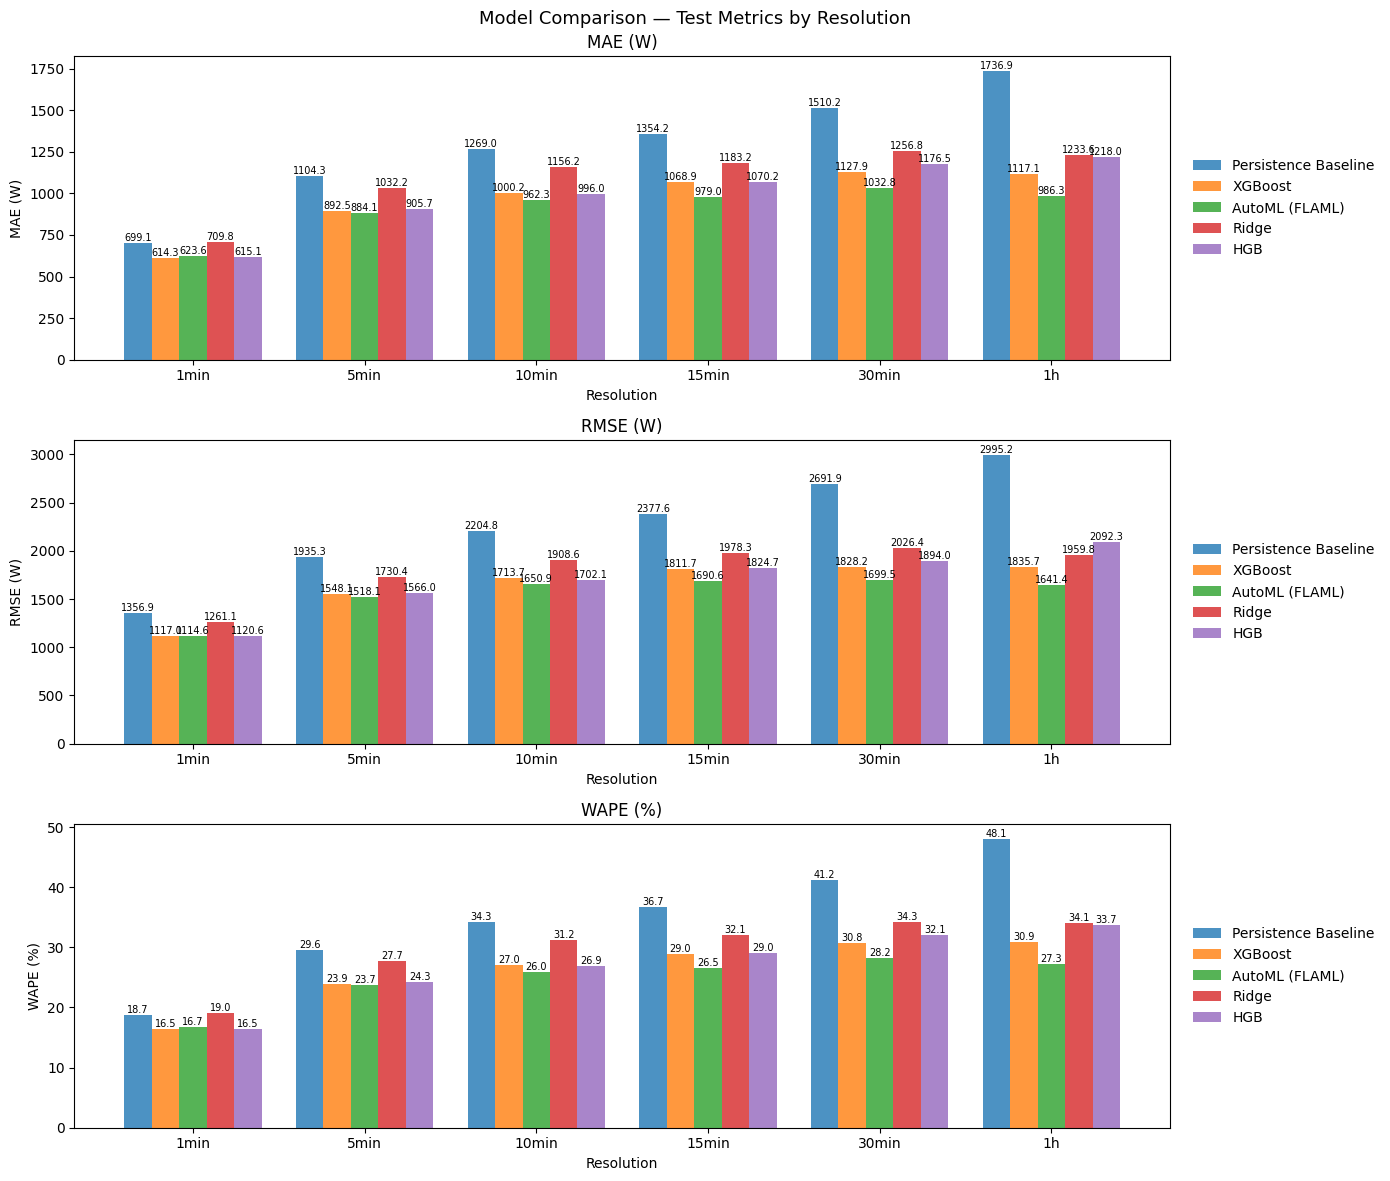

In [255]:
plot_model_comparison(models)

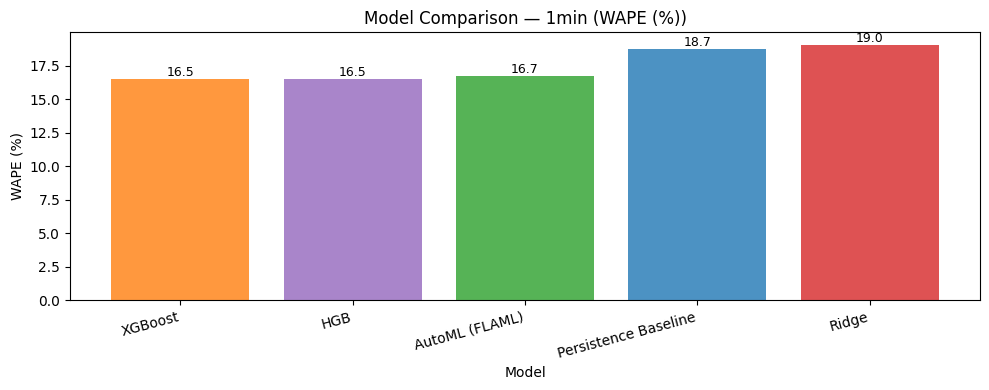

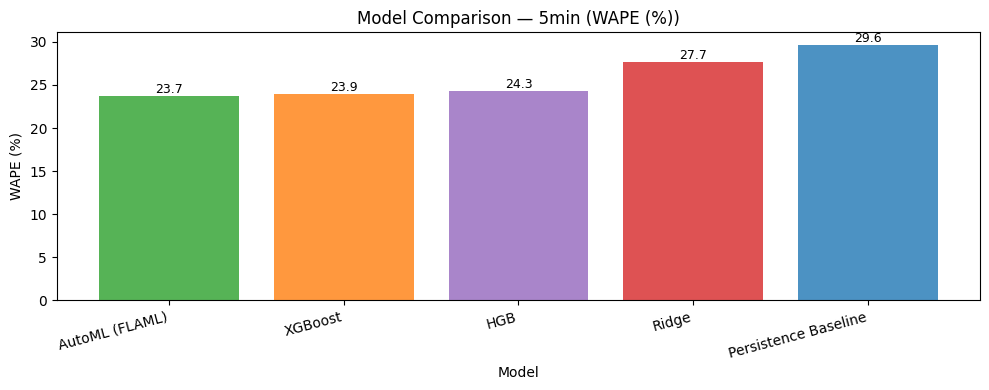

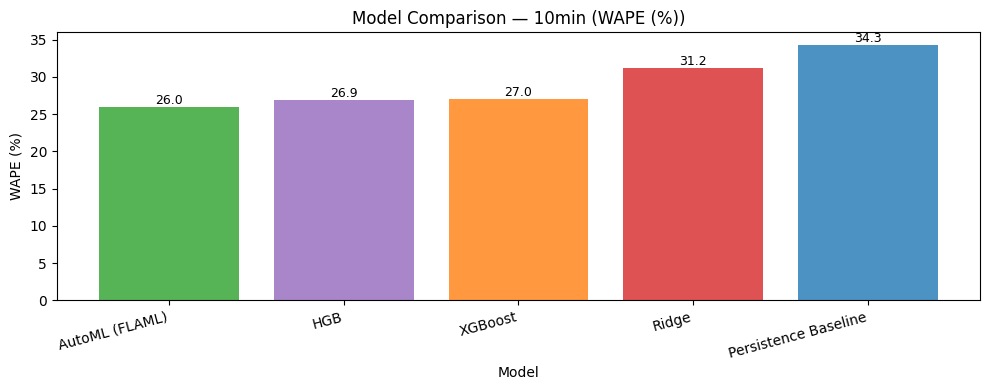

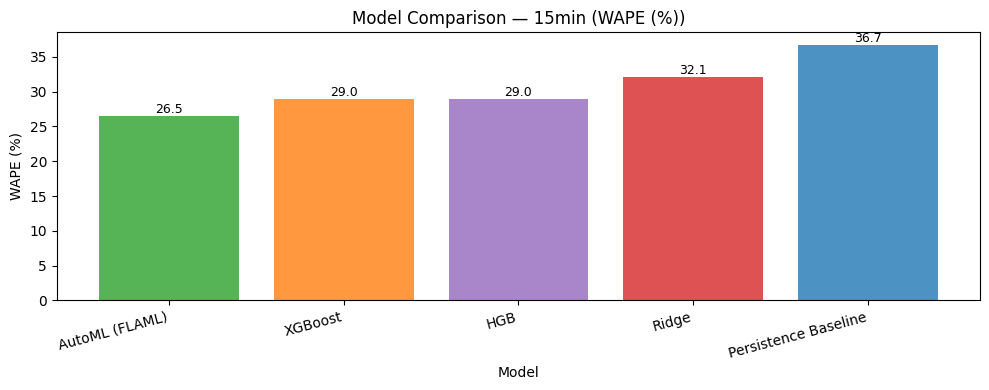

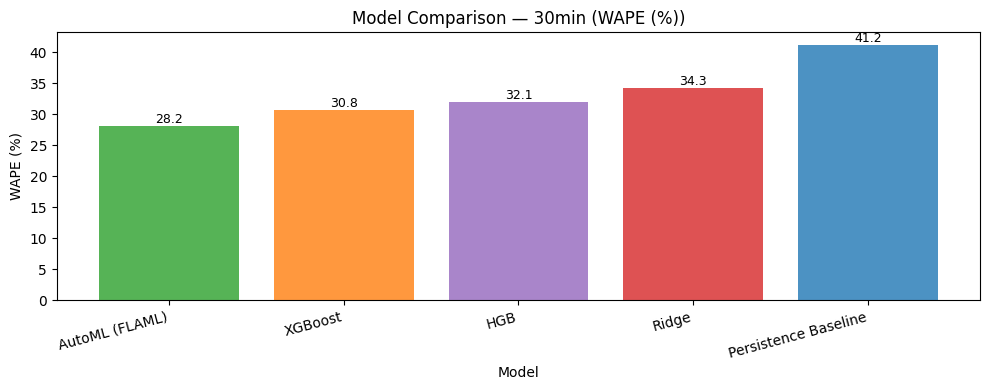

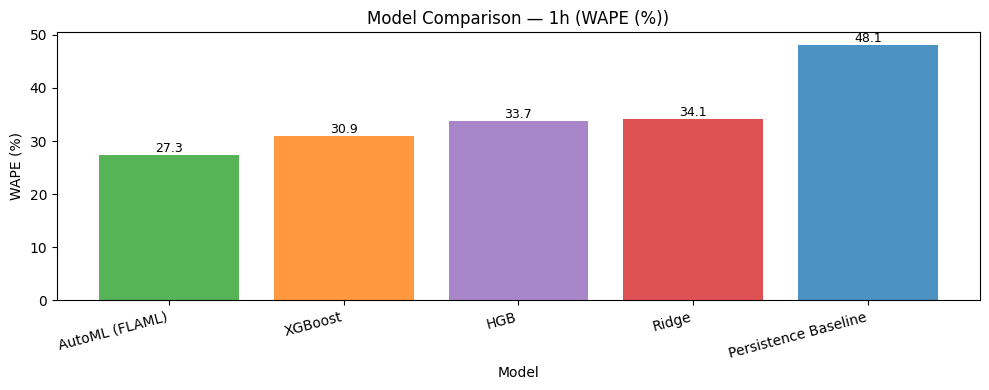

In [256]:
plot_models_per_resolutions(models, metric="wape")

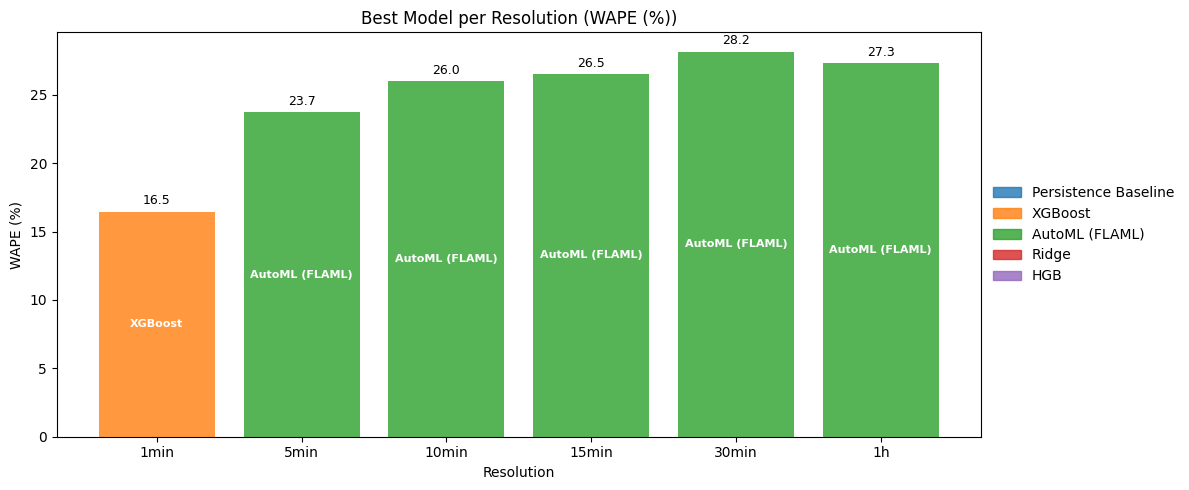

In [257]:
plot_best_model_per_resolution(models, metric="wape")

In [261]:
models_df = model_summary_table(models, metric="wape")
models_df

,model,resolution,mae,rmse,wape,rank_in_res,model_rank,overall_rank
0,XGBoost,1min,614.3,1117.0,16.5,1,2,1
1,HGB,1min,615.1,1120.6,16.5,1,3,1
2,AutoML (FLAML),1min,623.6,1114.6,16.7,3,1,3
3,Persistence Baseline,1min,699.1,1356.9,18.7,4,5,4
4,Ridge,1min,709.8,1261.1,19.0,5,4,5
5,AutoML (FLAML),5min,884.1,1518.1,23.7,1,1,6
6,XGBoost,5min,892.5,1548.1,23.9,2,2,7
7,HGB,5min,905.7,1566.0,24.3,3,3,8
8,AutoML (FLAML),10min,962.3,1650.9,26.0,1,1,9
9,AutoML (FLAML),15min,979.0,1690.6,26.5,1,1,10


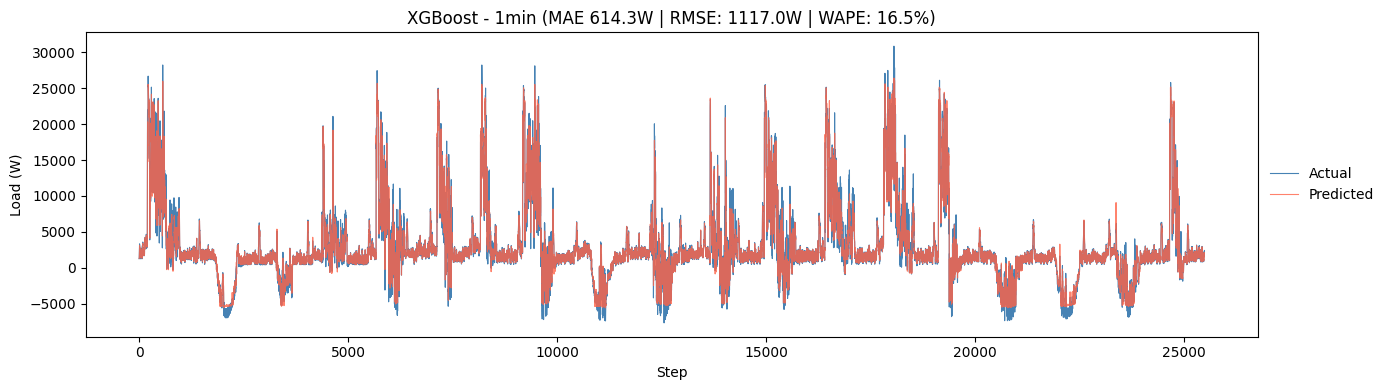

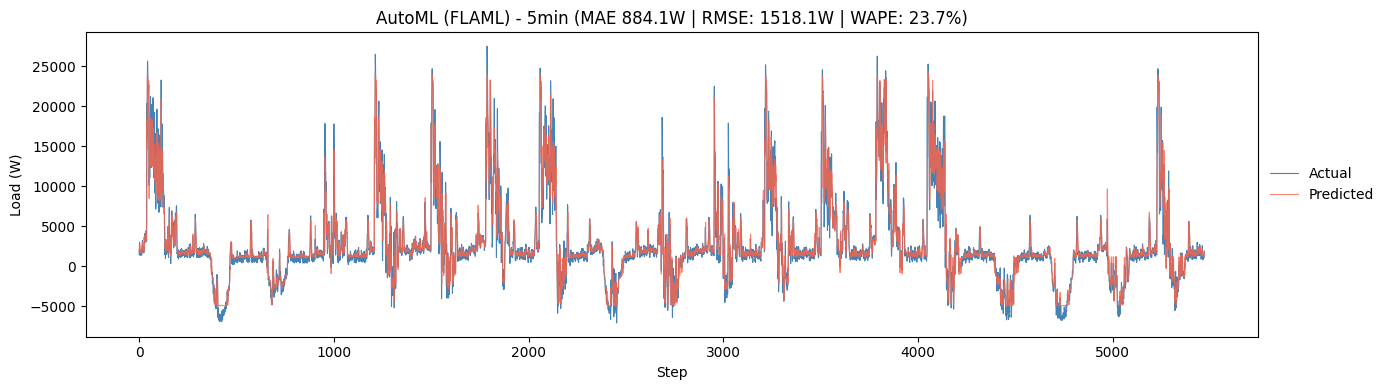

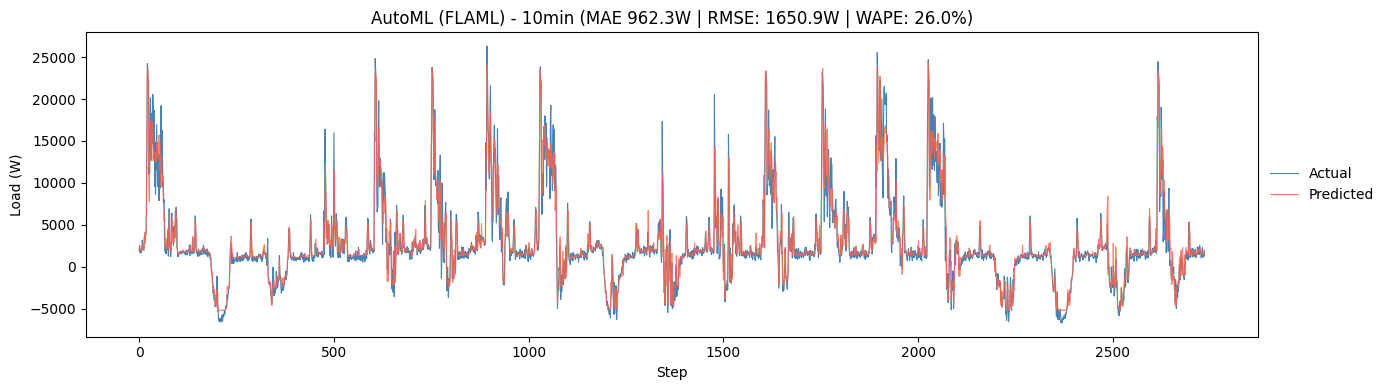

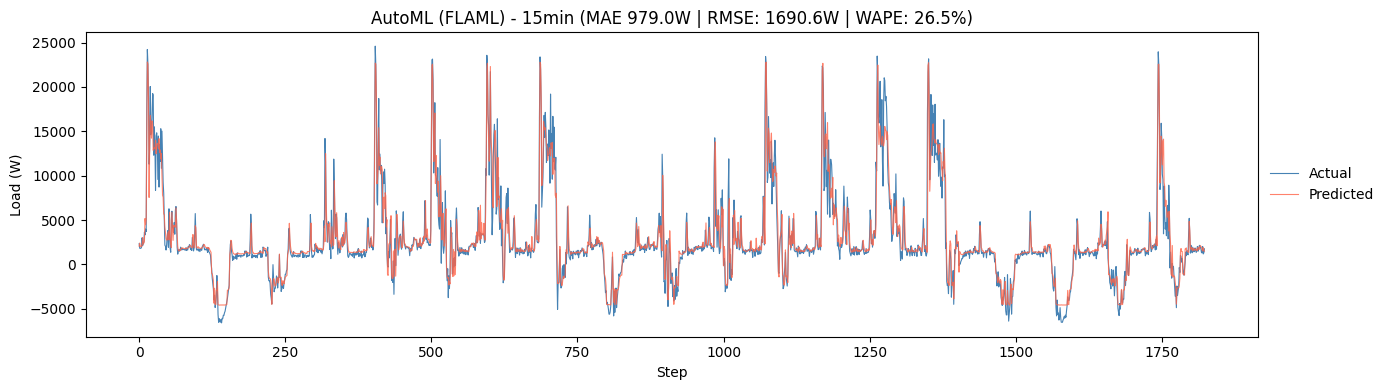

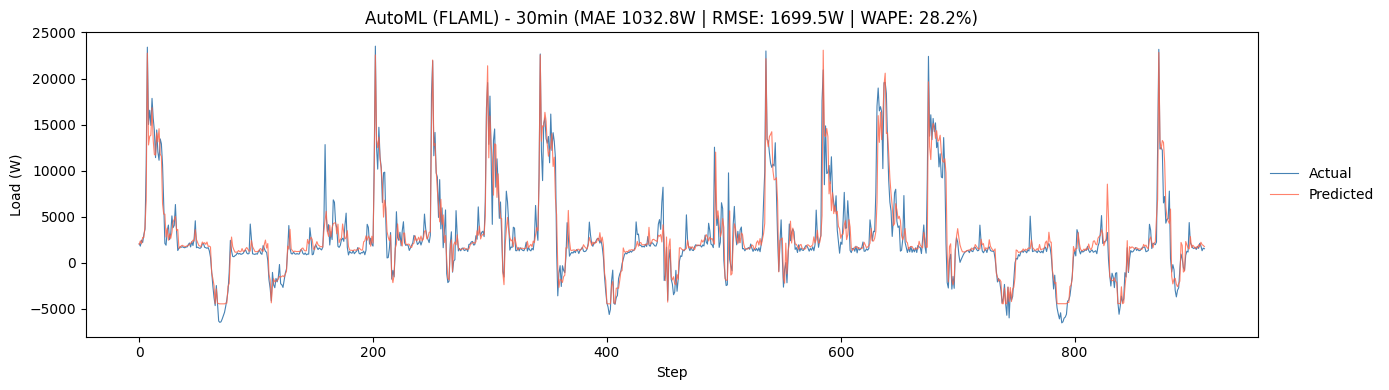

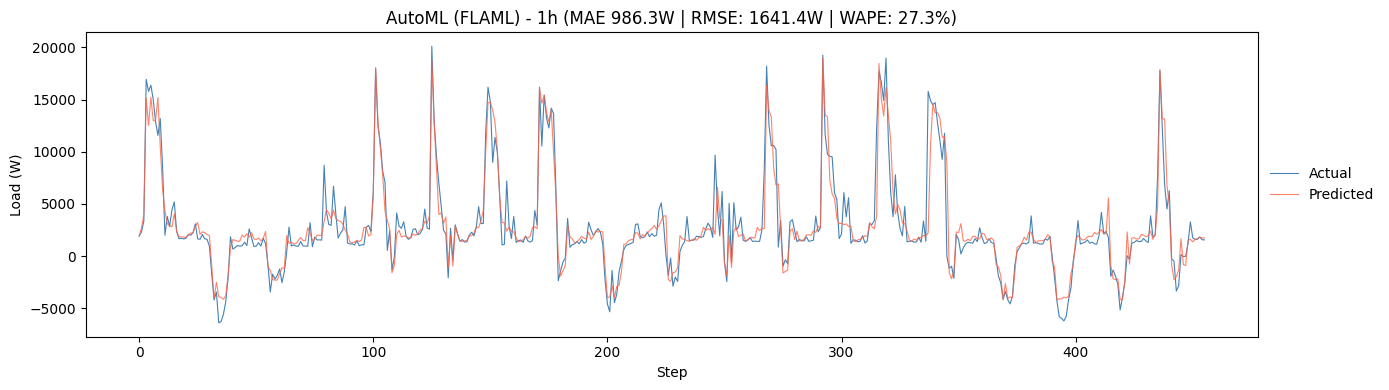

In [268]:
plot_true_vs_pred_best_model_per_resolution(models, metric="wape")

## Phase 3: Multi-Step Forecastin

A multi-step forecast (profile-based) predicts a sequence of future values, not just one point.

| Profile | Horizon (Window) | Resolution | Predicted Steps | Example |
|---------|---------|------------|-----------------|---------|
| Short-term | 1 hour | `1min` | 60 steps | Predict every minute for the next hour |
| Short-term | 1 hour | `5min` | 12 steps | Predict every 5 minutes for the next hour |
| Short-term | 1 hour | `10min` | 6 steps | Predict every 10 minutes for the next hour |
| Medium-term | 6 hours | `5min` | 72 steps | Predict every 5 minutes for the next 6 hours |
| Medium-term | 6 hours | `15min` | 24 steps | Predict every 15 minutes for the next 6 hours |
| Medium-term | 6 hours | `30min` | 12 steps | Predict every 30 minutes for the next 6 hours |
| Long-term | 24 hours | `15min` | 96 steps | Predict every 15 minutes for the next 24 hours |
| Long-term | 24 hours | `30min` | 48 steps | Predict every 30 minutes for the next 24 hours |
| Long-term | 24 hours | `1hr` | 24 steps | Predict every hour for the next 24 hours |


**Notes**:

* Each profile outputs **multiple future values** (a time series), not a single prediction
* The number of predicted steps depends on the data horizon window and resolution



When predicting a full forecast profile (sequence of future values), there are two fundamental strategies:

**Strategy 1: Direct Multi-Step**

Train a separate model for each step ahead. Each model is independently optimized to predict exactly N steps into the future using only known past data.

```
Model_1  → predicts load at t+1
Model_2  → predicts load at t+2
...
Model_N  → predicts load at t+N
```

| | |
|--|--|
| ✅ | No error accumulation — each model sees real data |
| ✅ | Each model optimized for its specific horizon |
| ✅ | Most accurate in practice |
| ❌ | More models to train |

**Strategy 2: Recursive Multi-Step**

Train a single model that predicts one step ahead, then feed that prediction back as a lag feature to predict the next step, and so on.

```
Model → t+1 (predicted) → feed back as lag → t+2 (predicted) → ...
```

| | |
|--|--|
| ✅ | Only one model to train |
| ❌ | Errors compound — small mistakes amplify over each step |
| ❌ | Later predictions are based on predicted values, not real ones |
| ❌ | Accuracy degrades significantly at longer horizons |


**Our Approach**

This project forecasts electric load across three forecast profiles:

| Profile | Horizon (Window) | Resolutions | Strategies |
|---------|---------|-------------|------------|
| Short-term | 1 hour | `1min`, `5min`, `10min` | Direct, Recursive |
| Medium-term | 6 hours | `5min`, `15min`, `30min` | Direct, Recursive |
| Long-term | 24 hours | `15min`, `30min`, `1hr` | Direct, Recursive |


### 3.1 Baseline Model

The baseline model predicts load using the **mean of the last 6 occurrences** of the same time and day class in the training data.

For each timestamp to predict, the baseline:
1. Looks back in the training data for the same **time of day** and **day class**
2. Takes the **last 6 occurrences** of that time + day class
3. Computes the **mean** of those 6 values as the prediction

If fewer than 6 occurrences exist, the mean of however many are available is used.

**Example**:

Predicting `2026-04-08 08:30:00` on a `full` day at `1min` resolution:

Look back in training data at all `full` day `08:30:00` values, take the last 6:

| Date | Day Class | Load at 08:30 |
|------|-----------|---------------|
| 2026-04-07 | full | 1,820W |
| 2026-04-06 | full | 1,950W |
| 2026-04-03 | full | 2,100W |
| 2026-04-02 | full | 1,780W |
| 2026-04-01 | full | 2,050W |
| 2026-03-31 | full | 1,900W |

```
Baseline prediction = (1820 + 1950 + 2100 + 1780 + 2050 + 1900) / 6 = 1,933W
```

The same logic is applied independently for every timestamp and day class combination in the forecast profile.

**Why This Baseline?**

- Simple and interpretable — no model training required
- Captures daily and weekly load patterns naturally
- Robust to individual anomalous days since it averages across 6 occurrences
- Sets a meaningful benchmark — any model that cannot beat this is not useful